# 강원도 산불 심화 EDA: 1차 날씨 심화와 2차 제한적 날씨-공간 융합

이 노트북은 `README.md`에 정리된 기존 EDA 결과와 후속 분석 과제를 이어받아 작성했다.

- 1차 분석은 산불 발생 전 `24/48/72시간`, 전일·이틀 전·사흘 전 날씨, 풍향계열, 상대 건조도, 강풍·건조 지속성을 검정한다.
- 2차 분석은 전력설비 데이터를 제외하고, 산불 발생 위치의 지형·접근성 조건에 따라 같은 날씨 이상성이 어떻게 달라지는지 제한적으로 확인한다.
- 토지피복 GPKG는 1.2GB 수준의 대형 파일이므로 이번 핵심 실행에서는 제외하고, 번지 프록시 검증은 후속 과제로 남긴다.

해석 범위: 2차 융합 분석은 산불 발생지 내부의 공간 그룹별 비교이다. 별도 비발생 공간 대조군을 만들지 않았으므로, 특정 지형에서 산불이 더 잘 난다는 발생 확률 결론으로 확장하지 않는다.


## 고정 원칙과 색상

- 결측치는 보간하지 않는다. 변수별 분석에서 해당 변수의 결측 행만 제외하고 유효 표본 수를 함께 확인한다.
- 기후지형유형 순서는 `영동 해안형 -> 영서 내륙형 -> 고지·산간형`으로 고정한다.
- 번지 유형 순서는 `임야번지(산) -> 일반번지`로 고정한다.
- 산불 좌표가 기상 격자에 매칭되지 않는 4건은 기존 EDA와 동일하게 최근접 보정 없이 제외한다.


In [55]:
from pathlib import Path
import time
import warnings

import geopandas as gpd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from shapely import wkt
from shapely.strtree import STRtree

warnings.filterwarnings("ignore")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print
    def Markdown(text):
        return text

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

ROOT = Path("D:/farm-system-public-02")
WEATHER_DIR = ROOT / "data" / "강원도_날씨데이터"
FIRE_DIR = ROOT / "data" / "강원도_데이터"
SPATIAL_DIR = FIRE_DIR / "강원도_공간데이터"
FIRE_SPATIAL_DIR = FIRE_DIR / "산불_공간데이터"

TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
ADDR_ORDER = ["임야번지(산)", "일반번지"]
DIRECTION_ORDER = ["북", "북동", "동", "남동", "남", "남서", "서", "북서"]
RANDOM_STATE = 20260603

TYPE_PALETTE = {
    "영동 해안형": "#D55E00",
    "영서 내륙형": "#0072B2",
    "고지·산간형": "#009E73",
}
ADDR_PALETTE = {
    "임야번지(산)": "#8B5A2B",
    "일반번지": "#4C72B0",
}

def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full(len(p), np.nan)
    valid = np.isfinite(p)
    pv = p[valid]
    if len(pv) == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    adjusted = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    restored = np.empty_like(adjusted)
    restored[order] = adjusted
    out[valid] = restored
    return out

def cohen_d(a, b):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return np.nan if pooled == 0 else (a.mean() - b.mean()) / pooled

def epsilon_squared_kruskal(h_stat, n, k):
    if n <= k:
        return np.nan
    return max((h_stat - k + 1) / (n - k), 0)

def valid_summary(df, columns):
    rows = []
    for col in columns:
        rows.append({
            "변수": col,
            "전체행": len(df),
            "유효표본수": int(df[col].notna().sum()),
            "결측수": int(df[col].isna().sum()),
            "결측률_pct": round(float(df[col].isna().mean() * 100), 2),
        })
    return pd.DataFrame(rows)

def wind_dir_8(deg):
    dirs = np.array(DIRECTION_ORDER, dtype=object)
    s = pd.Series(deg)
    out = pd.Series(pd.NA, index=s.index, dtype="object")
    valid = s.notna()
    idx = np.floor(((s.loc[valid].astype(float) % 360) + 22.5) / 45).astype(int) % 8
    out.loc[valid] = dirs[idx]
    return out

def circular_abs_diff(a, b):
    return np.abs(((a - b + 180) % 360) - 180)

print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])
print("ROOT:", ROOT)


현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']
ROOT: D:\farm-system-public-02


## 1. 데이터 결합과 선행 기상 파생

기존 EDA와 같은 결합 원칙을 따른다. 단, 이번 노트북에서는 산불 전 `24/48/72시간` rolling 기상과 전일·이틀 전·사흘 전 일단위 날씨를 추가한다.


In [56]:
def add_rolling_weather(hourly):
    hourly = hourly.sort_values(["기상셀ID", "일시"]).reset_index(drop=True)
    shifted = hourly.groupby("기상셀ID", sort=False)[["풍속_m_s", "습도_pct", "강수량_mm"]].shift(1)
    grouped = shifted.groupby(hourly["기상셀ID"], sort=False)
    for window in [24, 48, 72]:
        hourly[f"직전{window}h_평균풍속"] = (
            grouped["풍속_m_s"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_최대풍속"] = (
            grouped["풍속_m_s"].rolling(window, min_periods=1).max().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_평균습도"] = (
            grouped["습도_pct"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_최소습도"] = (
            grouped["습도_pct"].rolling(window, min_periods=1).min().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_강수량합"] = (
            grouped["강수량_mm"].rolling(window, min_periods=1).sum().reset_index(level=0, drop=True)
        )
    return hourly

def merge_daily_lag(base, daily, left_date_col, suffix):
    cols = [
        "기상셀ID", "날짜", "평균기온_C", "최저기온_C", "최고기온_C",
        "강수량_mm", "최대순간풍속_m_s", "최대순간풍향_deg",
    ]
    right = daily[cols].rename(
        columns={
            "날짜": left_date_col,
            "평균기온_C": f"{suffix}_평균기온_C",
            "최저기온_C": f"{suffix}_최저기온_C",
            "최고기온_C": f"{suffix}_최고기온_C",
            "강수량_mm": f"{suffix}_강수량_mm",
            "최대순간풍속_m_s": f"{suffix}_최대순간풍속_m_s",
            "최대순간풍향_deg": f"{suffix}_최대순간풍향_deg",
        }
    )
    return base.merge(right, on=["기상셀ID", left_date_col], how="left")

def build_fire_weather(fire_cells, daily, hourly):
    fire_weather = fire_cells.copy()
    for lag in [0, 1, 2, 3]:
        date_col = "날짜" if lag == 0 else f"전{lag}일"
        suffix = "발생일" if lag == 0 else f"전{lag}일"
        fire_weather = merge_daily_lag(fire_weather, daily, date_col, suffix)

    hourly_cols = [
        "기상셀ID", "일시", "기온_C", "풍속_m_s", "풍향_deg", "강수량_mm",
        "현지기압_hPa", "해면기압_hPa", "습도_pct", "풍향_8방위", "서풍계열",
    ] + [col for col in hourly.columns if col.startswith("직전")]
    hourly_right = hourly[hourly_cols].rename(columns={"일시": "발생일시"})
    fire_weather = fire_weather.merge(hourly_right, on=["기상셀ID", "발생일시"], how="left")
    fire_weather = fire_weather.rename(
        columns={
            "기온_C": "발생시각_기온_C",
            "풍속_m_s": "발생시각_풍속_m_s",
            "풍향_deg": "발생시각_풍향_deg",
            "강수량_mm": "발생시각_강수량_mm",
            "현지기압_hPa": "발생시각_현지기압_hPa",
            "해면기압_hPa": "발생시각_해면기압_hPa",
            "습도_pct": "발생시각_습도_pct",
            "풍향_8방위": "풍향_8방위",
            "서풍계열": "서풍계열",
        }
    )
    return fire_weather

t0 = time.time()
print("1) 원자료 로드")
fire = pd.read_csv(FIRE_DIR / "강원도_산불발생.csv", encoding="utf-8-sig")
grid = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson").to_crs("EPSG:4326")
climate_type = pd.read_csv(WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv", encoding="utf-8-sig")
daily = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_일단위.csv", encoding="utf-8-sig")
hourly = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_시간단위.csv", encoding="utf-8-sig")

print("2) 산불 시간·번지 유형 파생")
fire["발생일시"] = pd.to_datetime(
    dict(year=fire["연도"], month=fire["월"], day=fire["일"]),
    errors="coerce",
) + pd.to_timedelta(fire["시간"].fillna(0).astype(int), unit="h")
fire["날짜"] = fire["발생일시"].dt.floor("D")
for lag in [1, 2, 3]:
    fire[f"전{lag}일"] = fire["날짜"] - pd.to_timedelta(lag, unit="D")
fire["월_key"] = fire["발생일시"].dt.month
fire["시간_key"] = fire["발생일시"].dt.hour
fire["addr_type"] = np.where(
    fire["발생지역번지"].fillna("").astype(str).str.strip().str.startswith("산"),
    "임야번지(산)",
    "일반번지",
)

print("3) 기상 격자 공간 조인")
fire_gdf = gpd.GeoDataFrame(
    fire,
    geometry=gpd.points_from_xy(fire["경도"], fire["위도"]),
    crs="EPSG:4326",
)
fire_cells = gpd.sjoin(
    fire_gdf,
    grid[["기상셀ID", "기후권역", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right", "geometry"])
unmatched_ids = fire_cells.loc[fire_cells["기상셀ID"].isna(), "fire_id"].tolist()
fire_cells = fire_cells[fire_cells["기상셀ID"].notna()].copy()
fire_cells = fire_cells.merge(climate_type[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")

print("4) 일단위·시간단위 날씨 파생")
daily["날짜"] = pd.to_datetime(daily["날짜"])
hourly["일시"] = pd.to_datetime(hourly["일시"])
hourly["날짜"] = hourly["일시"].dt.floor("D")
hourly["월_key"] = hourly["일시"].dt.month
hourly["시간_key"] = hourly["일시"].dt.hour
hourly["풍향_8방위"] = wind_dir_8(hourly["풍향_deg"])
hourly["서풍계열"] = np.where(hourly["풍향_deg"].notna(), hourly["풍향_deg"].between(225, 315), np.nan)
hourly = hourly.merge(climate_type[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")
hourly = add_rolling_weather(hourly)

first_rows = hourly.groupby("기상셀ID").head(1)
rolling_check = bool(first_rows["직전24h_평균풍속"].isna().all())
fire_weather = build_fire_weather(fire_cells, daily, hourly)

t1 = time.time()
print(f"완료: {t1 - t0:.1f}초")
print(f"- 산불 원자료: {len(fire):,}건")
print(f"- 기상 격자 매칭 후 분석 산불: {len(fire_cells):,}건")
print(f"- 미매칭 제외 fire_id: {unmatched_ids}")
print(f"- 시간단위 날씨: {len(hourly):,}행")
print(f"- rolling 발생시각 제외 확인: {rolling_check}")

display(Markdown("### 변수별 결측 확인"))
display(valid_summary(
    fire_weather,
    [
        "발생시각_습도_pct", "발생시각_풍속_m_s", "발생시각_풍향_deg",
        "직전24h_최소습도", "직전48h_최소습도", "직전72h_최소습도",
        "발생일_강수량_mm", "전1일_강수량_mm", "전2일_강수량_mm", "전3일_강수량_mm",
    ],
))
display(pd.crosstab(fire_weather["기후지형유형"], fire_weather["addr_type"]).reindex(index=TYPE_ORDER, columns=ADDR_ORDER))


1) 원자료 로드
2) 산불 시간·번지 유형 파생
3) 기상 격자 공간 조인
4) 일단위·시간단위 날씨 파생
완료: 4.1초
- 산불 원자료: 3,405건
- 기상 격자 매칭 후 분석 산불: 3,401건
- 미매칭 제외 fire_id: ['F_006690', 'F_009678', 'F_010665', 'F_010893']
- 시간단위 날씨: 1,614,048행
- rolling 발생시각 제외 확인: True


### 변수별 결측 확인

,변수,전체행,유효표본수,결측수,결측률_pct
0,발생시각_습도_pct,3401,3401,0,0.00
1,발생시각_풍속_m_s,3401,3401,0,0.00
2,발생시각_풍향_deg,3401,3401,0,0.00
3,직전24h_최소습도,3401,3401,0,0.00
4,직전48h_최소습도,3401,3401,0,0.00
5,직전72h_최소습도,3401,3401,0,0.00
6,발생일_강수량_mm,3401,3401,0,0.00
7,전1일_강수량_mm,3401,3399,2,0.06
8,전2일_강수량_mm,3401,3399,2,0.06
9,전3일_강수량_mm,3401,3395,6,0.18


addr_type,임야번지(산),일반번지
기후지형유형,,
영동 해안형,246,975
영서 내륙형,330,1228
고지·산간형,209,413


## 2. 매칭 비발생 대조군과 상대 분위수

산불 1건마다 같은 기상셀, 같은 월, 같은 시간대의 비발생 시점을 최대 5개 추출한다. 이 대조군은 계절·지역·시간대 배경을 통제한 평상시 조건으로 사용한다.


In [57]:
def make_matched_controls(fire_weather, hourly, daily):
    fire_keys = pd.MultiIndex.from_frame(
        fire_weather[["기상셀ID", "발생일시"]].rename(columns={"발생일시": "일시"})
    )
    hourly_keys = pd.MultiIndex.from_frame(hourly[["기상셀ID", "일시"]])
    candidates = hourly.loc[~hourly_keys.isin(fire_keys)].copy()
    group_indices = candidates.groupby(["기상셀ID", "월_key", "시간_key"], sort=False).indices

    rng = np.random.default_rng(RANDOM_STATE)
    matched_parts = []
    for _, row in fire_weather.iterrows():
        key = (row["기상셀ID"], row["월_key"], row["시간_key"])
        idx = group_indices.get(key)
        if idx is None or len(idx) == 0:
            continue
        choose_n = min(5, len(idx))
        chosen = rng.choice(np.asarray(idx), size=choose_n, replace=False)
        block = candidates.iloc[chosen].copy()
        block["fire_id"] = row["fire_id"]
        block["대조번호"] = np.arange(1, choose_n + 1)
        matched_parts.append(block)

    matched = pd.concat(matched_parts, ignore_index=True)
    matched = matched.rename(columns={"일시": "대조일시", "날짜": "대조날짜"})
    for lag in [0, 1, 2, 3]:
        if lag == 0:
            matched["날짜"] = matched["대조날짜"]
            suffix = "대조일"
            date_col = "날짜"
        else:
            date_col = f"전{lag}일"
            matched[date_col] = matched["대조날짜"] - pd.to_timedelta(lag, unit="D")
            suffix = f"대조전{lag}일"
        matched = merge_daily_lag(matched, daily, date_col, suffix)
        if date_col in matched.columns:
            matched = matched.drop(columns=[date_col])
    return matched

def matched_percentile(fire_weather, matched, fire_col, matched_col, higher_is_risk):
    fire_lookup = fire_weather.set_index("fire_id")[fire_col]
    values = []
    for fire_id, group in matched.groupby("fire_id", sort=False):
        fire_val = fire_lookup.get(fire_id, np.nan)
        m = group[matched_col].dropna()
        if pd.isna(fire_val) or m.empty:
            values.append((fire_id, np.nan))
        elif higher_is_risk:
            values.append((fire_id, float((m <= fire_val).mean())))
        else:
            values.append((fire_id, float((m >= fire_val).mean())))
    return pd.Series(dict(values))

def paired_effect_summary(fire_weather, matched, specs):
    rows = []
    delta_cols = {}
    for spec in specs:
        ctrl_mean = matched.groupby("fire_id")[spec["control_col"]].mean()
        joined = fire_weather.set_index("fire_id")[[spec["fire_col"]]].join(ctrl_mean.rename("control_mean"), how="left")
        valid = joined.dropna()
        if valid.empty:
            continue
        delta = valid[spec["fire_col"]] - valid["control_mean"]
        risk_delta = -delta if spec["lower_is_risk"] else delta
        dz = risk_delta.mean() / risk_delta.std(ddof=1) if risk_delta.std(ddof=1) > 0 else np.nan
        try:
            t_p = stats.ttest_rel(valid[spec["fire_col"]], valid["control_mean"]).pvalue
        except Exception:
            t_p = np.nan
        try:
            w_p = stats.wilcoxon(delta).pvalue if not np.allclose(delta, 0) else np.nan
        except Exception:
            w_p = np.nan
        rows.append({
            "변수": spec["label"],
            "분류": spec["category"],
            "유효표본수": len(valid),
            "산불평균": valid[spec["fire_col"]].mean(),
            "대조평균": valid["control_mean"].mean(),
            "원차이_산불-대조": delta.mean(),
            "위험방향_평균차": risk_delta.mean(),
            "위험방향_dz": dz,
            "paired_t_p": t_p,
            "wilcoxon_p": w_p,
        })
        delta_cols[f"{spec['label']}_위험방향차"] = risk_delta
    out = pd.DataFrame(rows)
    out["FDR"] = bh_fdr(out["wilcoxon_p"])
    return out.sort_values("위험방향_dz", ascending=False).reset_index(drop=True), delta_cols

t0 = time.time()
matched = make_matched_controls(fire_weather, hourly, daily)
match_counts = matched.groupby("fire_id").size()

PAIR_SPECS = [
    {"label": "직전24h 최소습도", "category": "습도", "fire_col": "직전24h_최소습도", "control_col": "직전24h_최소습도", "lower_is_risk": True},
    {"label": "직전48h 최소습도", "category": "습도", "fire_col": "직전48h_최소습도", "control_col": "직전48h_최소습도", "lower_is_risk": True},
    {"label": "직전72h 최소습도", "category": "습도", "fire_col": "직전72h_최소습도", "control_col": "직전72h_최소습도", "lower_is_risk": True},
    {"label": "발생시각 습도", "category": "습도", "fire_col": "발생시각_습도_pct", "control_col": "습도_pct", "lower_is_risk": True},
    {"label": "직전24h 강수량합", "category": "강수", "fire_col": "직전24h_강수량합", "control_col": "직전24h_강수량합", "lower_is_risk": True},
    {"label": "직전48h 강수량합", "category": "강수", "fire_col": "직전48h_강수량합", "control_col": "직전48h_강수량합", "lower_is_risk": True},
    {"label": "직전72h 강수량합", "category": "강수", "fire_col": "직전72h_강수량합", "control_col": "직전72h_강수량합", "lower_is_risk": True},
    {"label": "발생일 강수량", "category": "강수", "fire_col": "발생일_강수량_mm", "control_col": "대조일_강수량_mm", "lower_is_risk": True},
    {"label": "전1일 강수량", "category": "강수", "fire_col": "전1일_강수량_mm", "control_col": "대조전1일_강수량_mm", "lower_is_risk": True},
    {"label": "전2일 강수량", "category": "강수", "fire_col": "전2일_강수량_mm", "control_col": "대조전2일_강수량_mm", "lower_is_risk": True},
    {"label": "전3일 강수량", "category": "강수", "fire_col": "전3일_강수량_mm", "control_col": "대조전3일_강수량_mm", "lower_is_risk": True},
    {"label": "발생시각 풍속", "category": "풍속", "fire_col": "발생시각_풍속_m_s", "control_col": "풍속_m_s", "lower_is_risk": False},
    {"label": "직전24h 평균풍속", "category": "풍속", "fire_col": "직전24h_평균풍속", "control_col": "직전24h_평균풍속", "lower_is_risk": False},
    {"label": "직전48h 평균풍속", "category": "풍속", "fire_col": "직전48h_평균풍속", "control_col": "직전48h_평균풍속", "lower_is_risk": False},
    {"label": "직전72h 평균풍속", "category": "풍속", "fire_col": "직전72h_평균풍속", "control_col": "직전72h_평균풍속", "lower_is_risk": False},
    {"label": "발생일 최대순간풍속", "category": "풍속", "fire_col": "발생일_최대순간풍속_m_s", "control_col": "대조일_최대순간풍속_m_s", "lower_is_risk": False},
]

paired_summary, delta_cols = paired_effect_summary(fire_weather, matched, PAIR_SPECS)

percentile_specs = [
    ("상대건조_분위수", "발생시각_습도_pct", "습도_pct", False),
    ("직전24h_건조_분위수", "직전24h_최소습도", "직전24h_최소습도", False),
    ("풍속상대_분위수", "발생시각_풍속_m_s", "풍속_m_s", True),
    ("직전24h_풍속_분위수", "직전24h_평균풍속", "직전24h_평균풍속", True),
]
for out_col, fire_col, matched_col, higher_is_risk in percentile_specs:
    fire_weather[out_col] = fire_weather["fire_id"].map(
        matched_percentile(fire_weather, matched, fire_col, matched_col, higher_is_risk)
    )

dry_now = fire_weather["상대건조_분위수"] >= 0.8
dry_24h = fire_weather["직전24h_건조_분위수"] >= 0.8
wind_now = fire_weather["풍속상대_분위수"] >= 0.8
wind_24h = fire_weather["직전24h_풍속_분위수"] >= 0.8
fire_weather["건조유형"] = np.select(
    [dry_now & dry_24h, dry_24h, dry_now],
    ["지속+순간 저습", "지속 건조형", "순간 저습형"],
    default="매칭대조군과 유사",
)
fire_weather["강풍유형"] = np.select(
    [wind_now & wind_24h, wind_24h, wind_now],
    ["지속+순간 강풍", "지속 강풍형", "순간 강풍형"],
    default="매칭대조군과 유사",
)
fire_weather["저습강풍_복합형"] = np.where((dry_now | dry_24h) & (wind_now | wind_24h), "저습+강풍", "단일/약한 이상성")

fire_time_keys = pd.MultiIndex.from_frame(fire_weather[["기상셀ID", "발생일시"]].rename(columns={"발생일시": "대조일시"}))
matched_time_keys = pd.MultiIndex.from_frame(matched[["기상셀ID", "대조일시"]])
duplicate_fire_time = bool(matched_time_keys.isin(fire_time_keys).any())
t1 = time.time()

print(f"매칭 대조군 생성 완료: {t1 - t0:.1f}초")
print(f"- 매칭 행 수: {len(matched):,}")
print(f"- 산불 1건당 평균 매칭 수: {match_counts.mean():.2f}")
print(f"- 산불 발생시점과 대조군 중복 여부: {duplicate_fire_time}")
display(paired_summary)
display(Markdown("### 상대 분위수 및 유형별 건수"))
display(valid_summary(fire_weather, ["상대건조_분위수", "직전24h_건조_분위수", "풍속상대_분위수", "직전24h_풍속_분위수"]))
display(pd.crosstab(fire_weather["건조유형"], fire_weather["강풍유형"]))


매칭 대조군 생성 완료: 9.3초
- 매칭 행 수: 17,005
- 산불 1건당 평균 매칭 수: 5.00
- 산불 발생시점과 대조군 중복 여부: False


,변수,분류,유효표본수,산불평균,대조평균,원차이_산불-대조,위험방향_평균차,위험방향_dz,paired_t_p,wilcoxon_p,FDR
0,직전24h 최소습도,습도,3401,32.919356,41.558833,-8.639477,8.639477,0.677011,5.712409e-281,1.132831e-269,4.531325e-269
1,직전48h 최소습도,습도,3401,30.067954,36.608573,-6.540619,6.540619,0.593343,4.791244e-225,1.406206e-235,3.214186e-235
2,직전72h 최소습도,습도,3401,28.011726,33.847047,-5.835321,5.835321,0.566388,9.332916e-208,2.243096e-228,4.486193e-228
3,발생시각 습도,습도,3401,49.693264,56.694004,-7.000740,7.000740,0.358280,2.621119e-91,1.930515e-96,2.808021e-96
4,직전72h 강수량합,강수,3401,1.475516,4.845664,-3.370148,3.370148,0.349940,2.009708e-87,7.358411e-304,5.886728e-303
5,직전48h 강수량합,강수,3401,0.766307,3.282488,-2.516181,2.516181,0.322214,5.005007e-75,0.000000e+00,0.000000e+00
6,전2일 강수량,강수,3399,0.462768,1.608240,-1.145472,1.145472,0.314254,1.405089e-71,1.397316e-212,2.235705e-212
7,전1일 강수량,강수,3399,0.399891,1.629658,-1.229767,1.229767,0.264774,5.204164e-52,2.699393e-252,8.638058e-252
8,발생일 강수량,강수,3401,0.485410,1.611595,-1.126185,1.126185,0.252650,1.116529e-47,3.952576e-227,7.026801e-227
9,전3일 강수량,강수,3395,0.541302,1.547472,-1.006170,1.006170,0.229903,6.503236e-40,8.327622e-252,2.220699e-251


### 상대 분위수 및 유형별 건수

,변수,전체행,유효표본수,결측수,결측률_pct
0,상대건조_분위수,3401,3401,0,0.0
1,직전24h_건조_분위수,3401,3401,0,0.0
2,풍속상대_분위수,3401,3401,0,0.0
3,직전24h_풍속_분위수,3401,3401,0,0.0


강풍유형,매칭대조군과 유사,순간 강풍형,지속 강풍형,지속+순간 강풍
건조유형,,,,
매칭대조군과 유사,649,219,126,113
순간 저습형,122,52,74,176
지속 건조형,409,113,84,80
지속+순간 저습,423,114,258,389


## 3. 1차 날씨 심화: 선행 기상 이상성과 지속성

이 단계는 산불 당시 조건이 같은 셀·월·시간대의 평상시보다 얼마나 위험 방향으로 이동했는지 본다. 습도와 강수량은 낮을수록, 풍속은 높을수록 위험 방향으로 표준화한다.


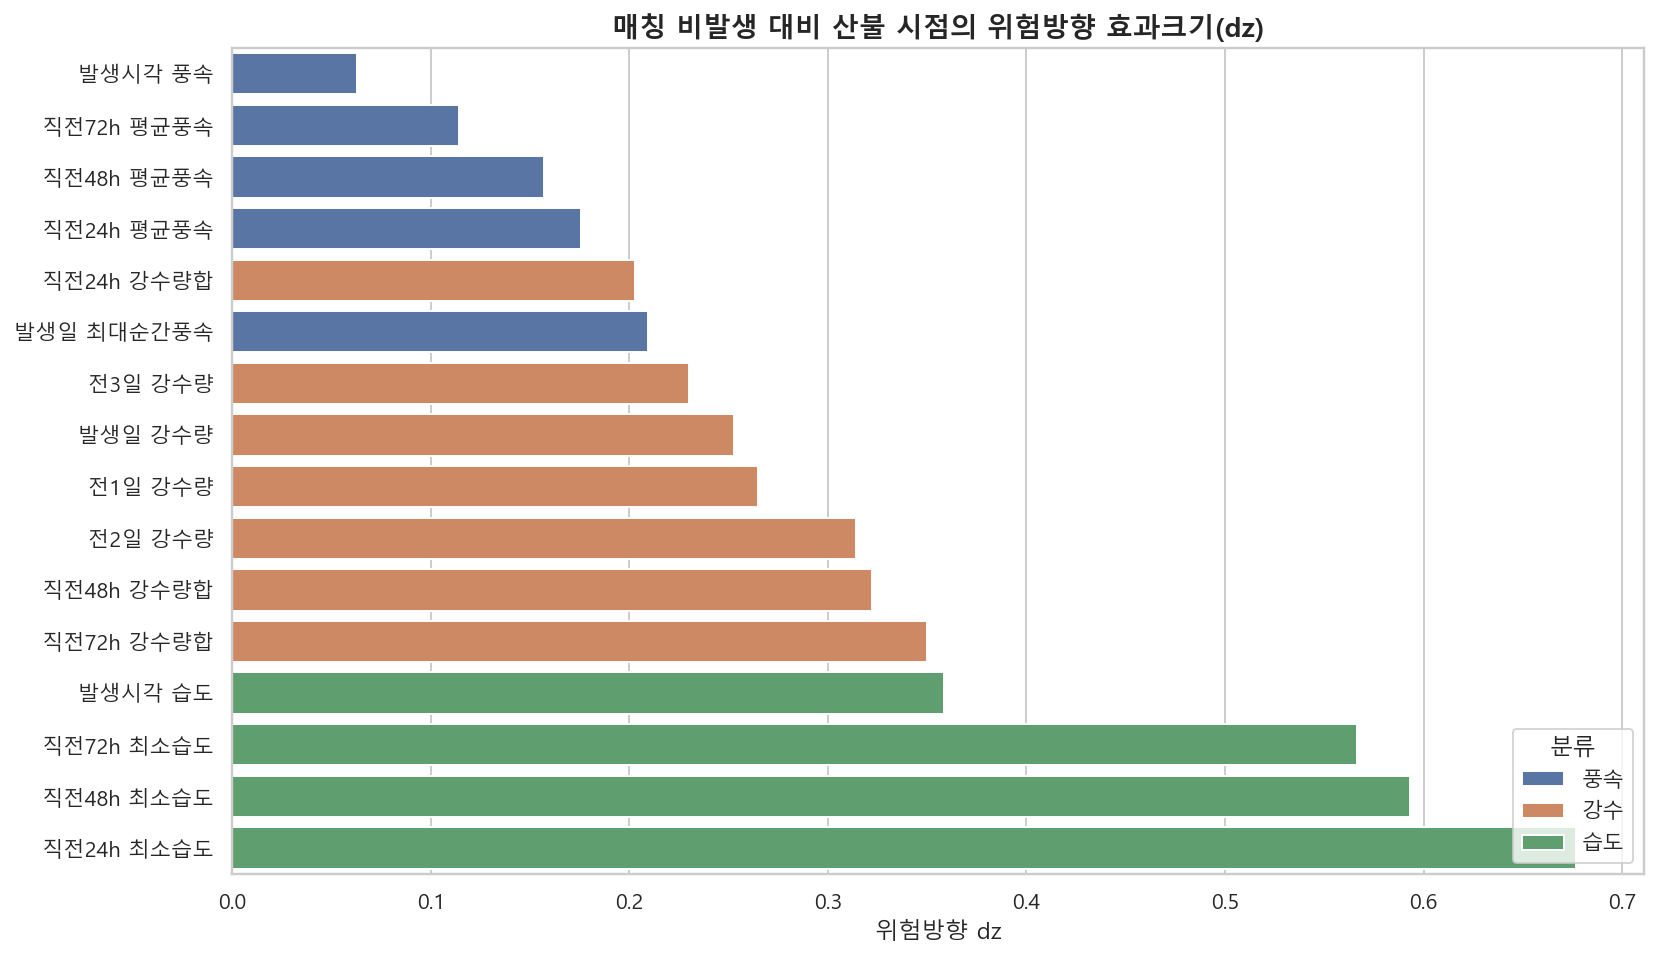

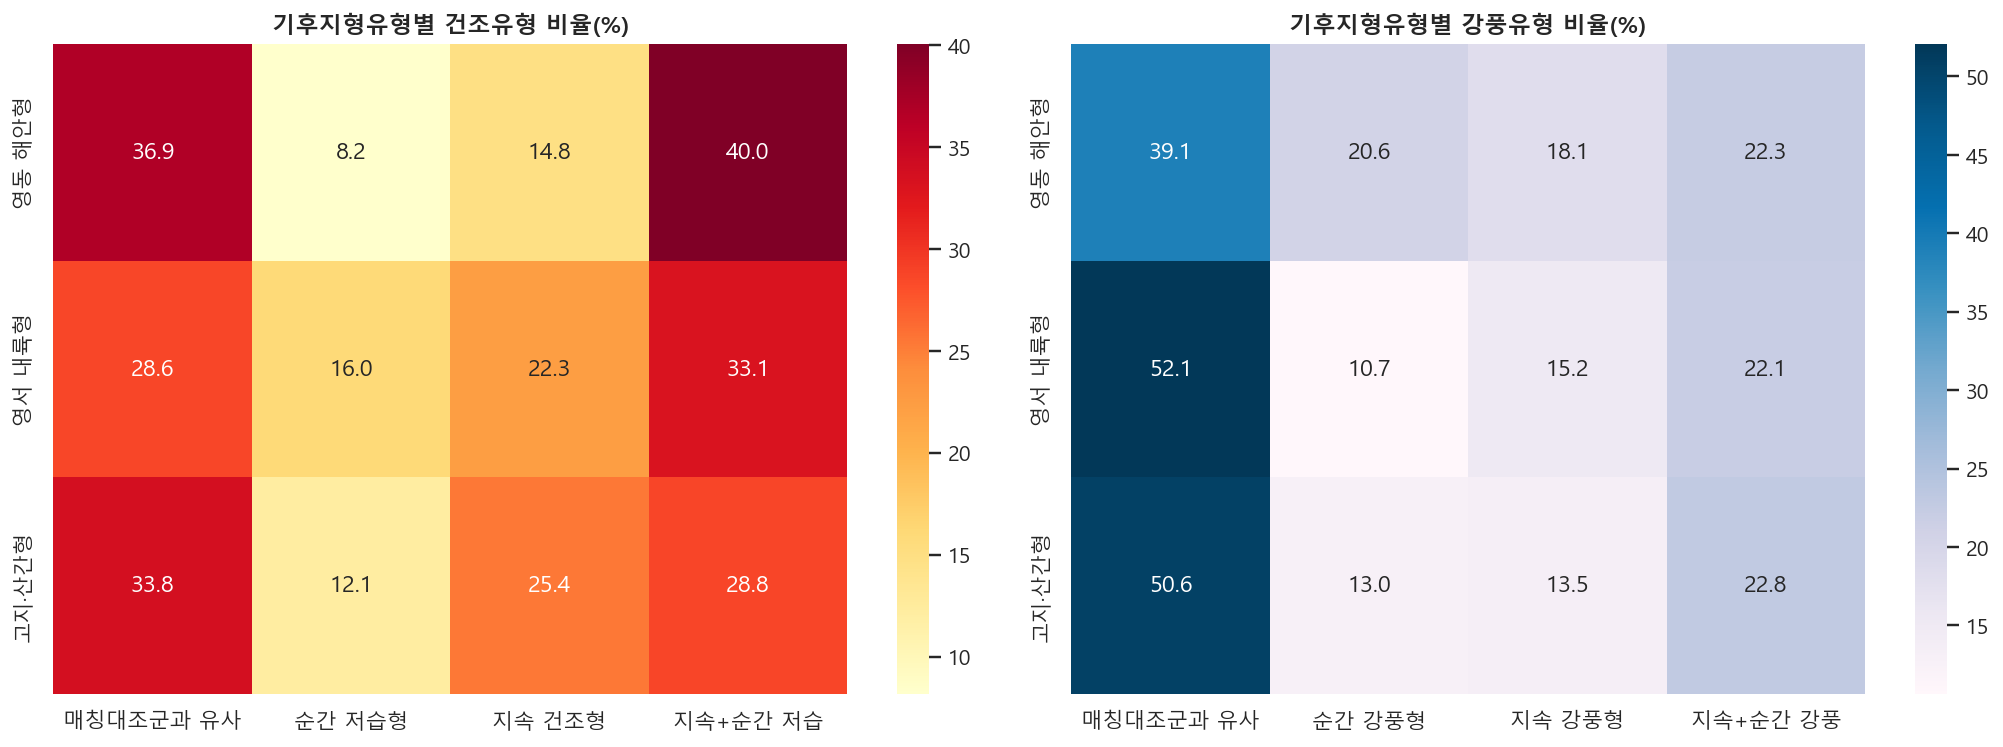

### 기후지형유형별 선행 무강수·누적 건조 요약

,발생건수,전1일_무강수비율,전2일_무강수비율,전3일_무강수비율,직전24h_강수량중앙값,직전48h_강수량중앙값,직전72h_강수량중앙값,직전24h_최소습도중앙값,직전72h_최소습도중앙값
기후지형유형,,,,,,,,,
영동 해안형,1221,92.30,53.07,87.63,0.0,0.0,0.04,33.15,21.96
영서 내륙형,1558,78.05,69.70,79.72,0.0,0.0,0.00,29.91,25.64
고지·산간형,622,83.44,78.62,80.55,0.0,0.0,0.00,34.01,27.59


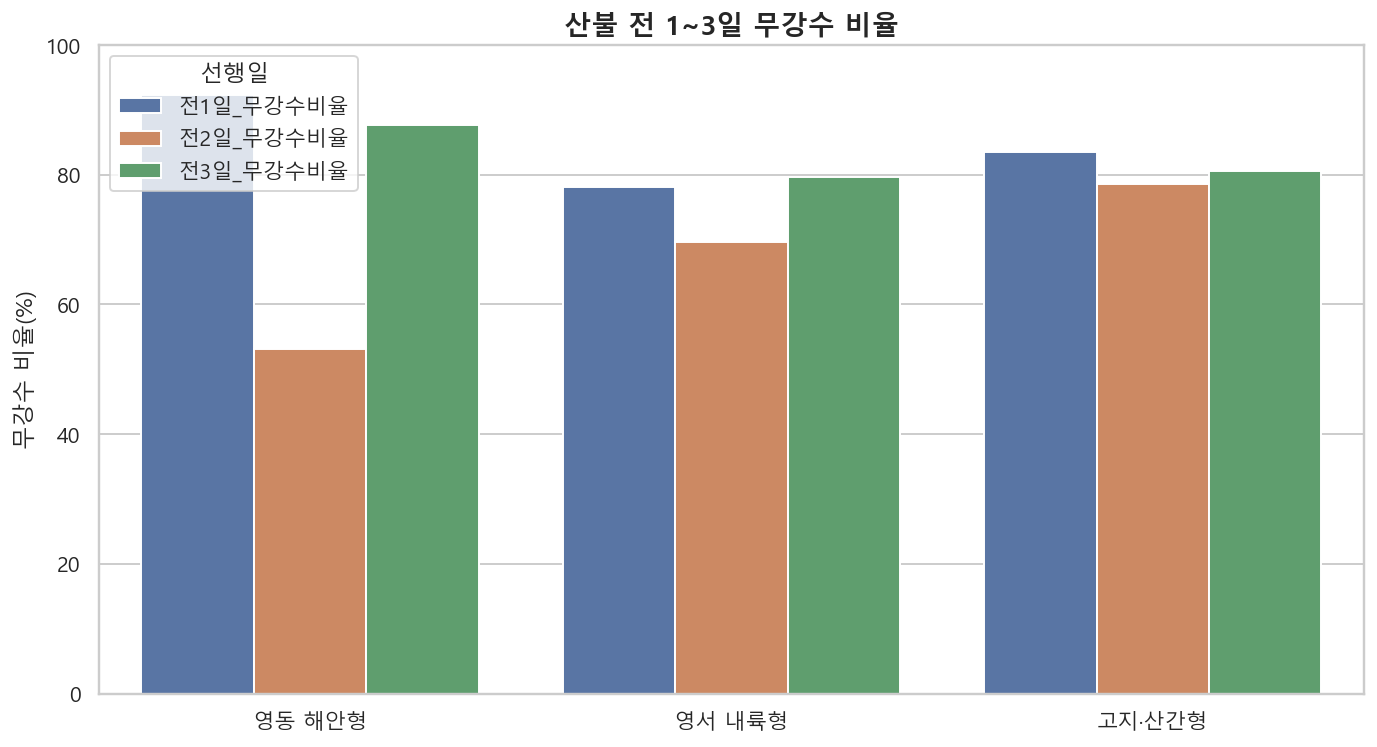

In [58]:
plot_df = paired_summary.sort_values("위험방향_dz", ascending=True).copy()
fig, ax = plt.subplots(figsize=(12, 7), dpi=140)
sns.barplot(data=plot_df, x="위험방향_dz", y="변수", hue="분류", dodge=False, ax=ax)
ax.axvline(0, color="#444444", lw=1)
ax.set_title("매칭 비발생 대비 산불 시점의 위험방향 효과크기(dz)", fontsize=14, fontweight="bold")
ax.set_xlabel("위험방향 dz")
ax.set_ylabel("")
ax.legend(title="분류", loc="lower right")
plt.tight_layout()
plt.show()

duration_cols = [
    "상대건조_분위수", "직전24h_건조_분위수", "풍속상대_분위수", "직전24h_풍속_분위수",
]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), dpi=140)
sns.heatmap(
    pd.crosstab(fire_weather["기후지형유형"], fire_weather["건조유형"], normalize="index")
    .reindex(index=TYPE_ORDER)
    .fillna(0) * 100,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=axes[0],
)
axes[0].set_title("기후지형유형별 건조유형 비율(%)", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
sns.heatmap(
    pd.crosstab(fire_weather["기후지형유형"], fire_weather["강풍유형"], normalize="index")
    .reindex(index=TYPE_ORDER)
    .fillna(0) * 100,
    annot=True,
    fmt=".1f",
    cmap="PuBu",
    ax=axes[1],
)
axes[1].set_title("기후지형유형별 강풍유형 비율(%)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

lead_rain = fire_weather.groupby("기후지형유형").agg(
    발생건수=("fire_id", "count"),
    전1일_무강수비율=("전1일_강수량_mm", lambda s: (s.fillna(np.nan) == 0).mean() * 100),
    전2일_무강수비율=("전2일_강수량_mm", lambda s: (s.fillna(np.nan) == 0).mean() * 100),
    전3일_무강수비율=("전3일_강수량_mm", lambda s: (s.fillna(np.nan) == 0).mean() * 100),
    직전24h_강수량중앙값=("직전24h_강수량합", "median"),
    직전48h_강수량중앙값=("직전48h_강수량합", "median"),
    직전72h_강수량중앙값=("직전72h_강수량합", "median"),
    직전24h_최소습도중앙값=("직전24h_최소습도", "median"),
    직전72h_최소습도중앙값=("직전72h_최소습도", "median"),
).reindex(TYPE_ORDER)
display(Markdown("### 기후지형유형별 선행 무강수·누적 건조 요약"))
display(lead_rain.round(2))

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=140)
rain_long = lead_rain.reset_index().melt(
    id_vars="기후지형유형",
    value_vars=["전1일_무강수비율", "전2일_무강수비율", "전3일_무강수비율"],
    var_name="선행일",
    value_name="무강수비율_pct",
)
sns.barplot(data=rain_long, x="기후지형유형", y="무강수비율_pct", hue="선행일", order=TYPE_ORDER, ax=ax)
ax.set_title("산불 전 1~3일 무강수 비율", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("무강수 비율(%)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


- 산불 발생 시 매칭 비발생 대비 산불 발생을 유발하는 쪽으로 이동했는지 살펴본다
  - 습도와 강수량은 낮을수록, 풍속은 높을수록 산불 유발함을 가정
  - 습도
    - 제일 위험 방향으로 향했다
    - 산불 발생 24시간 전, 48시간 전, 72시간 전 최소습도 순으로 효과 크기가 컸다
    - 발생 시각 습도는 강수량과 비슷했다
  - 강수량
    - 산불 발생 72시간 전 강수량합, 48시간전 강수량합, 2일전 강수량, 1일전 강수량, 발생일 강수량, 3일전 강수량, 산불 발생 24시간전 강수량합 순서대로 효과가 컸다
  - 풍속
    - 습도와 강수량 대비 효과크기가 작다
    - 발생시각 풍속에 제일 효과가 작다
  - 즉 습도와 강수량이 매칭 비발생과 산불 발생을 구분짓는 핵심 키워드이다
    - 발생일 당시의 날씨보단 발생일 이전부터의 날씨의 변화가 중요하다
    - 계속해서 건조한지가 중요

- 기후지형유형별 건조유형 비율(%)

| 기후지형유형 | 매칭대조군과 유사 | 순간 저습형 | 지속 건조형 | 지속+순간 저습 |
| ------ | --------: | -----: | -----: | -------: |
| 영동 해안형 |      36.9 |    8.2 |   14.8 |     40.0 |
| 영서 내륙형 |      28.6 |   16.0 |   22.3 |     33.1 |
| 고지·산간형 |      33.8 |   12.1 |   25.4 |     28.8 |

  - 세 지역 모두 순간 저습형보단 지속적으로 건조한것의 비율이 높다
  - 그러나 매칭 대조군과 유사할때에도 산불이 발생한 비율이 상당 부분 차지하니 
  - 이것이 산불에 절대적인 요인은 아니다, 그러나 매우 큰 요인이다


- 기후지형유형별 강풍유형 비율(%)

| 기후지형유형 | 매칭대조군과 유사 | 순간 강풍형 | 지속 강풍형 | 지속+순간 강풍 |
| ------ | --------: | -----: | -----: | -------: |
| 영동 해안형 |      39.1 |   20.6 |   18.1 |     22.3 |
| 영서 내륙형 |      52.1 |   10.7 |   15.2 |     22.1 |
| 고지·산간형 |      50.6 |   13.0 |   13.5 |     22.8 |

  - 강풍의 영향은 생각보다 크지 않다
  - 영동의 경우 강풍이 좀 더 영향을 주는 것 같아보이긴 하지만
  - 이 지역 자체의 변화무쌍한 바람의 영향을 받고 있다고도 볼 수 있다
  - 따라서 산불이 발생하지 않았을때의 바람의 분포랑 수치를 비교해봐야 한다

- 산불 1~3일 전 무강수 비율

| 기후지형유형 |  발생건수 | 전1일 무강수비율(%) | 전2일 무강수비율(%) | 전3일 무강수비율(%) |
| ------ | ----: | -----------: | -----------: | -----------: |
| 영동 해안형 | 1,221 |        92.30 |        53.07 |        87.63 |
| 영서 내륙형 | 1,558 |        78.05 |        69.70 |        79.72 |
| 고지·산간형 |   622 |        83.44 |        78.62 |        80.55 |

  - 영동이 산불 1일 전 무강수 비율이 제일 높고 2일전 비율이 제일 낮다
  - 바람이 강해 순간 건조의 영향이 좀 있는 것으로 보인다
  - 또는 바람이 강해 습도를 이기고 불이 더 잘 붙는건가
  - 산불 발생 전 무강수 비율이 70%의 일정 비율을 보여준다
  - 즉 무강수가 산불의 필수 조건은 아니지만 큰 영향을 준다고도 볼 수 있다

## 4. 풍향계열과 기후지형유형

전체 기간 평균 풍향에서는 권역 차이가 약했지만, 산불 발생 시점으로 제한하면 다를 수 있다. 여기서는 산불군과 매칭 비발생군의 8방위 분포와 서풍계열 비율을 기후지형유형별로 다시 비교한다.


,기후지형유형,산불_서풍계열_pct,매칭_서풍계열_pct,차이_pctp,8방위_chi2_p,FDR
0,영동 해안형,45.455,39.607,5.848,0.0,0.0
1,영서 내륙형,28.626,30.308,-1.682,0.0,0.0
2,고지·산간형,25.402,26.334,-0.932,0.0,0.0


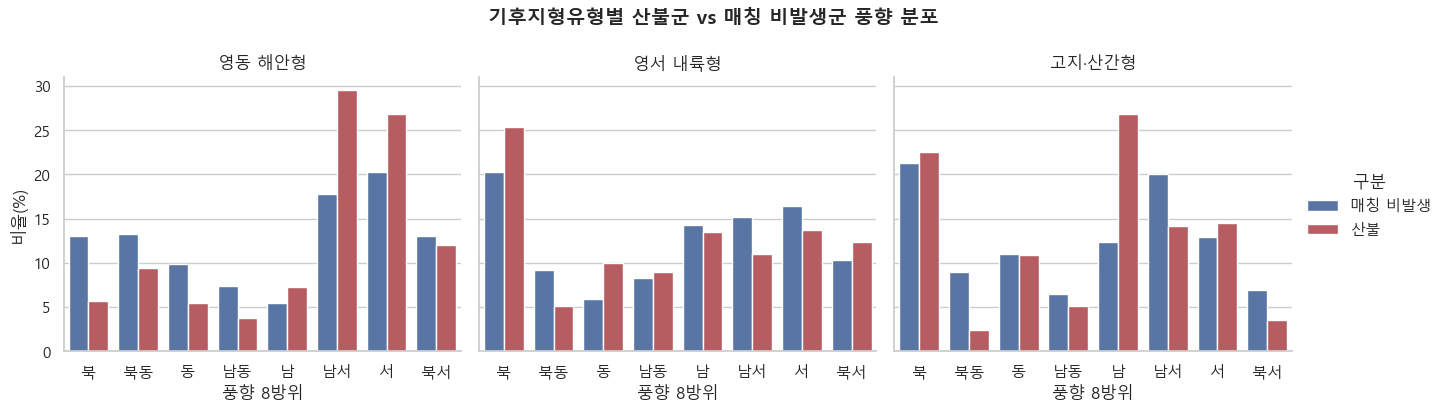

In [59]:
wind_fire = fire_weather[["fire_id", "기후지형유형", "풍향_8방위", "서풍계열"]].assign(구분="산불")
wind_ctrl = matched[["fire_id", "기후지형유형", "풍향_8방위", "서풍계열"]].assign(구분="매칭 비발생")
wind_both = pd.concat([wind_fire, wind_ctrl], ignore_index=True)
wind_both = wind_both[wind_both["풍향_8방위"].notna()].copy()

wind_prop = (
    wind_both.groupby(["기후지형유형", "구분", "풍향_8방위"]).size()
    .rename("건수")
    .reset_index()
)
totals = wind_prop.groupby(["기후지형유형", "구분"])["건수"].transform("sum")
wind_prop["비율_pct"] = wind_prop["건수"] / totals * 100

wind_stats = []
for ctype in TYPE_ORDER:
    sub = wind_both[wind_both["기후지형유형"] == ctype]
    ct = pd.crosstab(sub["구분"], sub["풍향_8방위"]).reindex(index=["산불", "매칭 비발생"], columns=DIRECTION_ORDER, fill_value=0)
    chi_p = np.nan
    if ct.shape == (2, 8) and (ct.sum(axis=0) > 0).sum() > 1:
        chi_p = stats.chi2_contingency(ct)[1]
    west = sub.dropna(subset=["서풍계열"]).groupby("구분")["서풍계열"].mean() * 100
    wind_stats.append({
        "기후지형유형": ctype,
        "산불_서풍계열_pct": west.get("산불", np.nan),
        "매칭_서풍계열_pct": west.get("매칭 비발생", np.nan),
        "차이_pctp": west.get("산불", np.nan) - west.get("매칭 비발생", np.nan),
        "8방위_chi2_p": chi_p,
    })
wind_stats = pd.DataFrame(wind_stats)
wind_stats["FDR"] = bh_fdr(wind_stats["8방위_chi2_p"])
display(wind_stats.round(3))

g = sns.catplot(
    data=wind_prop,
    x="풍향_8방위",
    y="비율_pct",
    hue="구분",
    col="기후지형유형",
    order=DIRECTION_ORDER,
    col_order=TYPE_ORDER,
    kind="bar",
    height=4.2,
    aspect=1.05,
    palette={"산불": "#C44E52", "매칭 비발생": "#4C72B0"},
    sharey=True,
)
g.set_axis_labels("풍향 8방위", "비율(%)")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("기후지형유형별 산불군 vs 매칭 비발생군 풍향 분포", fontsize=14, fontweight="bold")
plt.show()


| 기후지형유형 | 산불 서풍계열 비율(%) | 매칭 서풍계열 비율(%) | 차이(%p) | 8방위 χ² 검정 p-value |
| ------ | ------------: | ------------: | -----: | ----------------: |
| 영동 해안형 |        45.455 |        39.607 |  5.848 |               0.0 |
| 영서 내륙형 |        28.626 |        30.308 | -1.682 |               0.0 |
| 고지·산간형 |        25.402 |        26.334 | -0.932 |               0.0 |

- 영동만 산불이 발생하였을 때 서풍계열 바람이 많이 불었다
  - 양간지풍의 효과가 확실한 듯 하다
- 풍향 8방위 그래프를 살펴보면 영동은 원래 서풍계열 바람이 많이 불었는데 산불 시 매칭 비발생보다 더 많이 바람이 불었다
  - 영서는 북, 서, 남서, 남 순서대로 바람이 많이 불었고, 산불 발생시 북풍이 증가, 서~남 계열 바람은 감소하였다
  - 고지 산간형은 북, 남서 바람이 많이 불었지만 산불 발생시 북풍 소폭 증가, 남서 감소, 그리고 4위였던 남풍이 1위로 올라섰다

## 5. 영동 해안형 강수 후 급건조 탐색

영동 해안형은 일부 산불이 강수 이후에도 발생했다. 여기서는 산불 발생 전 같은 셀에서 마지막으로 비가 온 시점부터 산불 발생까지의 경과 시간, 습도 변화, 풍속 변화를 계산한다.


### 산불군: 마지막 강수 이후 상태 요약

,산불건수,최근24h_강수후발생비율,최근72h_강수후발생비율,강수후_경과시간_중앙값_h,강수이후_습도변화_중앙값_pctp,강수이후_풍속변화_중앙값_m_s,발생시각_습도_중앙값,발생시각_풍속_중앙값
기후지형유형,,,,,,,,
영동 해안형,1221,31.94,65.60,52.0,-35.30,0.93,44.63,3.09
영서 내륙형,1558,10.98,48.46,76.0,-36.61,0.21,51.82,1.43
고지·산간형,622,21.38,32.32,190.0,-26.47,0.76,56.72,1.82


### 산불군 vs 매칭 비발생군: 마지막 강수 이후 상태

사례행수  최근24h_강수후비율  최근72h_강수후비율  큰습도하락20p비율  풍속상승비율  강수후72h_급건조복합비율  강수후경과시간중앙값_h  습도변화중앙값_pctp  풍속변화중앙값_m_s
기후지형유형 구분                                                                                                                 
영동 해안형 산불      1221        31.94        65.60       81.74   76.00           43.82          52.0        -35.30         0.93
       매칭 비발생  6105        28.34        54.87       61.59   65.72           21.97          59.0        -29.24         0.44
영서 내륙형 산불      1558        10.98        48.46       68.55   55.78           29.20          76.0        -36.61         0.21
       매칭 비발생  7790        27.47        53.94       52.89   49.23           16.15          62.0        -22.79         0.00
고지·산간형 산불       622        21.38        32.32       72.03   72.35           18.33         190.0        -26.47         0.76
       매칭 비발생  3110        27.81        53.18       56.69   60.80           18.65          61.0        -25.03         0.30

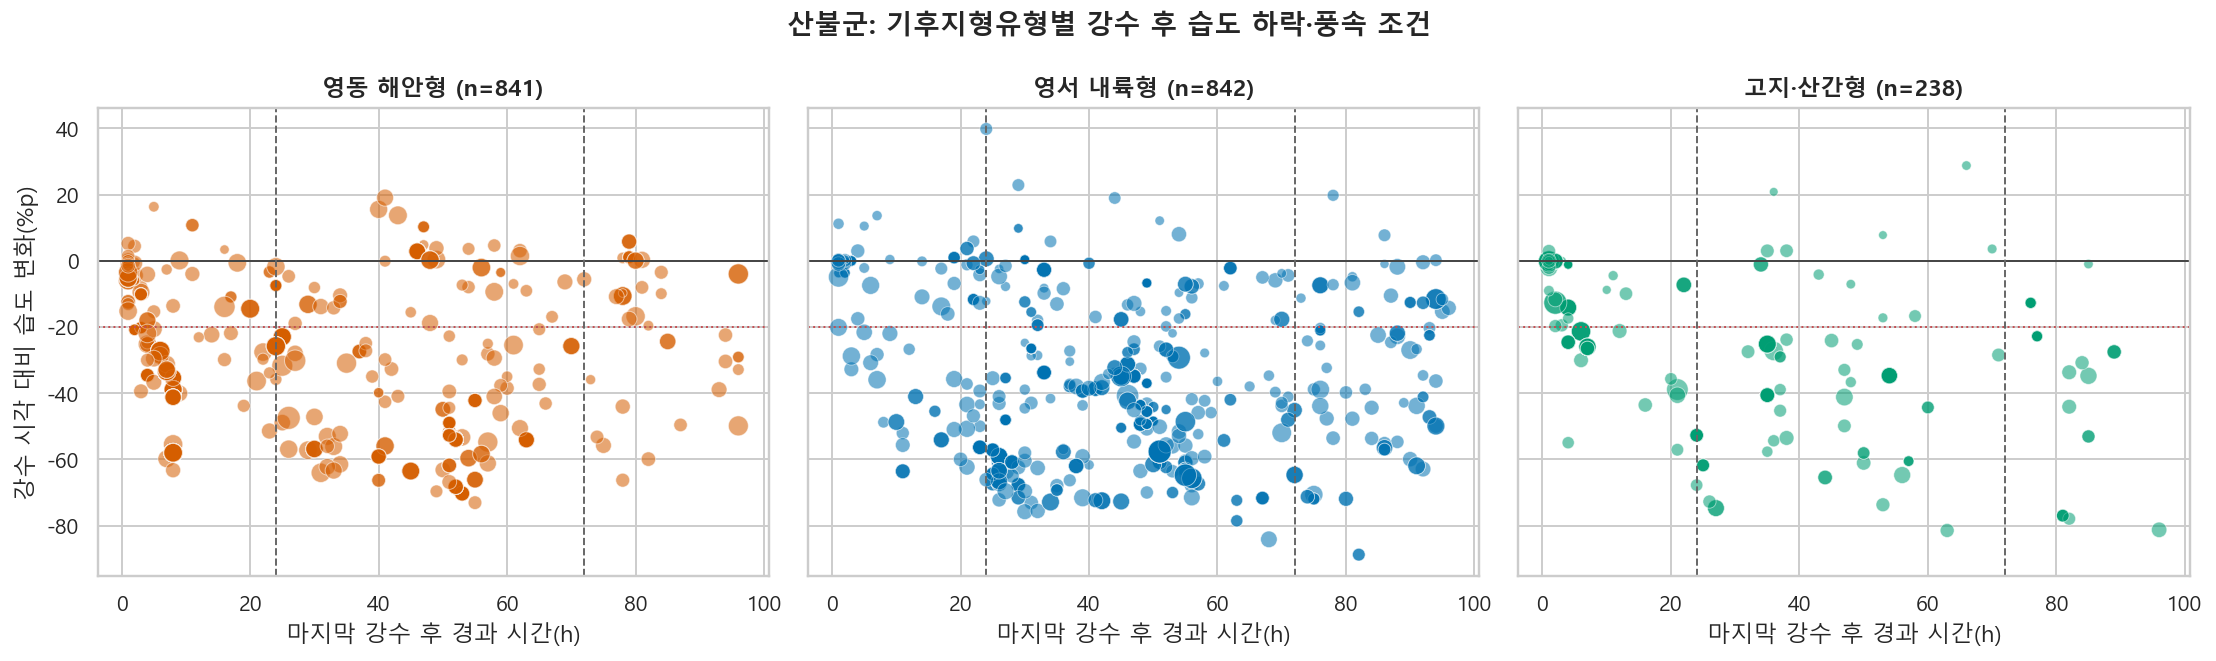

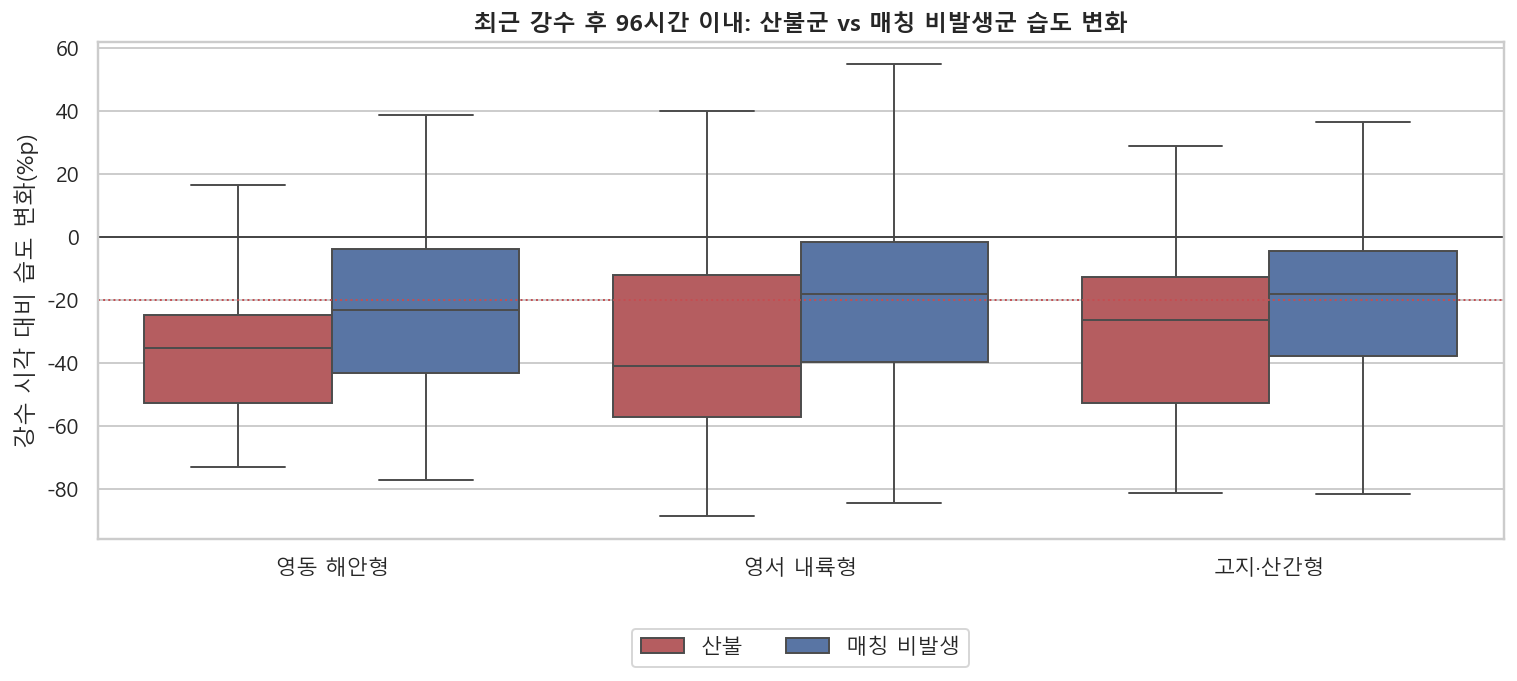

### 영동 해안형: 강수 후 급건조 조건 비율 비교

,사례행수,최근24h_강수후비율,최근72h_강수후비율,큰습도하락20p비율,풍속상승비율,강수후72h_급건조복합비율
구분,,,,,,
산불,1221,31.94,65.60,81.74,76.00,43.82
매칭 비발생,6105,28.34,54.87,61.59,65.72,21.97


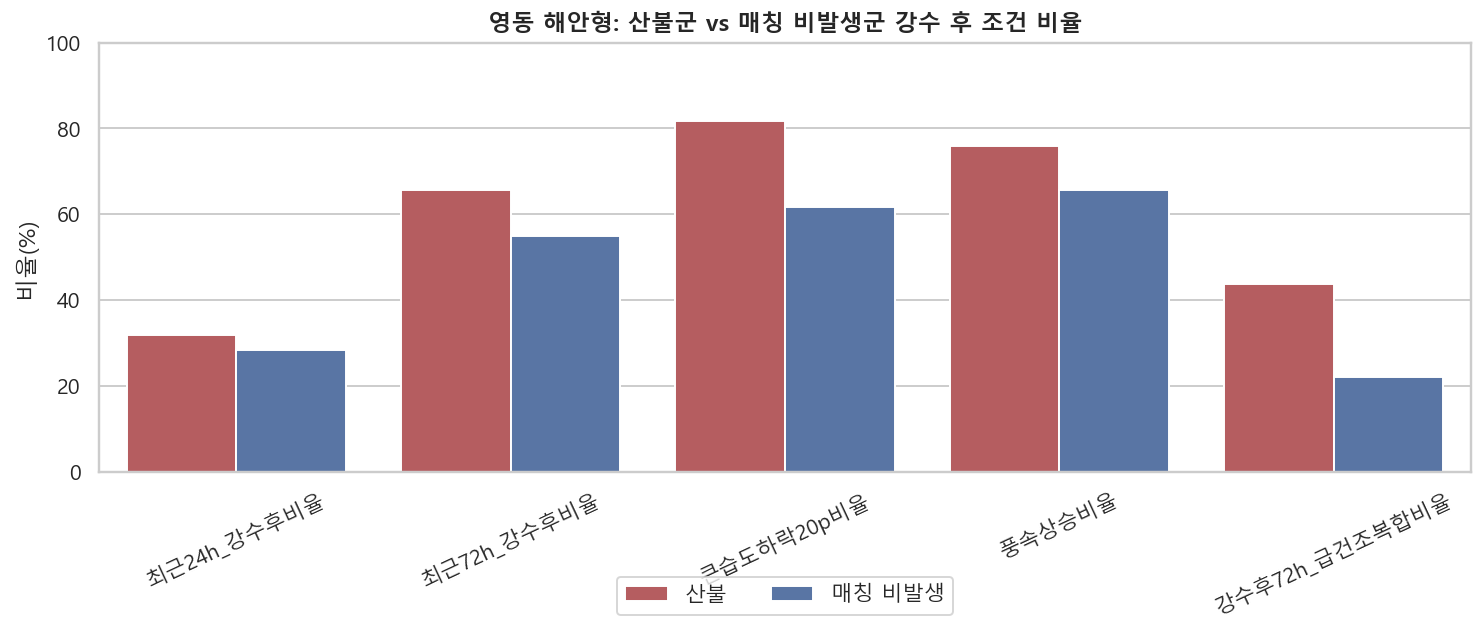

In [60]:
rain_metric_cols = [
    "최근강수시각", "강수후_경과시간_h", "강수시각_습도_pct", "강수시각_풍속_m_s",
    "강수시각_강수량_mm", "강수이후_습도변화_pctp", "강수이후_풍속변화_m_s",
    "최근24h_강수후발생", "최근72h_강수후발생", "강수후_큰습도하락20p",
    "강수후_풍속상승", "강수후72h_급건조복합",
]

rain_rows = hourly.loc[
    hourly["강수량_mm"].fillna(0) > 0,
    ["기상셀ID", "일시", "습도_pct", "풍속_m_s", "강수량_mm"],
].sort_values(["기상셀ID", "일시"])

rain_by_cell = {
    cell: (group.reset_index(drop=True), group["일시"].to_numpy())
    for cell, group in rain_rows.groupby("기상셀ID", sort=False)
}

def add_last_rain_metrics(df, time_col, humidity_col, wind_col):
    required = ["기상셀ID", time_col, humidity_col, wind_col]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"필수 컬럼이 없습니다: {missing}")

    base = df.reset_index(drop=True)
    out = base.drop(columns=rain_metric_cols, errors="ignore").copy()
    records = []

    for i, row in base[["기상셀ID", time_col]].iterrows():
        record = {
            "__row_pos": i,
            "최근강수시각": pd.NaT,
            "강수후_경과시간_h": np.nan,
            "강수시각_습도_pct": np.nan,
            "강수시각_풍속_m_s": np.nan,
            "강수시각_강수량_mm": np.nan,
        }
        group_info = rain_by_cell.get(row["기상셀ID"])
        if group_info is not None and pd.notna(row[time_col]):
            group, time_values = group_info
            pos = np.searchsorted(time_values, np.datetime64(row[time_col]), side="left") - 1
            if pos >= 0:
                rain = group.iloc[pos]
                record["최근강수시각"] = rain["일시"]
                record["강수후_경과시간_h"] = (row[time_col] - rain["일시"]) / np.timedelta64(1, "h")
                record["강수시각_습도_pct"] = rain["습도_pct"]
                record["강수시각_풍속_m_s"] = rain["풍속_m_s"]
                record["강수시각_강수량_mm"] = rain["강수량_mm"]
        records.append(record)

    metrics = pd.DataFrame.from_records(records).set_index("__row_pos")
    out = out.join(metrics, how="left")
    out["강수이후_습도변화_pctp"] = out[humidity_col] - out["강수시각_습도_pct"]
    out["강수이후_풍속변화_m_s"] = out[wind_col] - out["강수시각_풍속_m_s"]
    out["최근24h_강수후발생"] = out["강수후_경과시간_h"].between(0, 24)
    out["최근72h_강수후발생"] = out["강수후_경과시간_h"].between(0, 72)
    out["강수후_큰습도하락20p"] = out["강수이후_습도변화_pctp"] <= -20
    out["강수후_풍속상승"] = out["강수이후_풍속변화_m_s"] > 0
    out["강수후72h_급건조복합"] = (
        out["최근72h_강수후발생"]
        & out["강수후_큰습도하락20p"]
        & out["강수후_풍속상승"]
    )
    out.index = df.index
    return out

fire_weather = add_last_rain_metrics(
    fire_weather,
    time_col="발생일시",
    humidity_col="발생시각_습도_pct",
    wind_col="발생시각_풍속_m_s",
)
matched = add_last_rain_metrics(
    matched,
    time_col="대조일시",
    humidity_col="습도_pct",
    wind_col="풍속_m_s",
)

rain_summary = fire_weather.groupby("기후지형유형").agg(
    산불건수=("fire_id", "count"),
    최근24h_강수후발생비율=("최근24h_강수후발생", lambda s: s.mean() * 100),
    최근72h_강수후발생비율=("최근72h_강수후발생", lambda s: s.mean() * 100),
    강수후_경과시간_중앙값_h=("강수후_경과시간_h", "median"),
    강수이후_습도변화_중앙값_pctp=("강수이후_습도변화_pctp", "median"),
    강수이후_풍속변화_중앙값_m_s=("강수이후_풍속변화_m_s", "median"),
    발생시각_습도_중앙값=("발생시각_습도_pct", "median"),
    발생시각_풍속_중앙값=("발생시각_풍속_m_s", "median"),
).reindex(TYPE_ORDER)

display(Markdown("### 산불군: 마지막 강수 이후 상태 요약"))
display(rain_summary.round(2))

fire_rain = fire_weather[
    [
        "fire_id", "기후지형유형", "강수후_경과시간_h", "강수이후_습도변화_pctp",
        "강수이후_풍속변화_m_s", "최근24h_강수후발생", "최근72h_강수후발생",
        "강수후_큰습도하락20p", "강수후_풍속상승", "강수후72h_급건조복합",
    ]
].copy()
fire_rain["구분"] = "산불"
fire_rain["현재습도_pct"] = fire_weather["발생시각_습도_pct"]
fire_rain["현재풍속_m_s"] = fire_weather["발생시각_풍속_m_s"]

ctrl_rain = matched[
    [
        "fire_id", "기후지형유형", "강수후_경과시간_h", "강수이후_습도변화_pctp",
        "강수이후_풍속변화_m_s", "최근24h_강수후발생", "최근72h_강수후발생",
        "강수후_큰습도하락20p", "강수후_풍속상승", "강수후72h_급건조복합",
    ]
].copy()
ctrl_rain["구분"] = "매칭 비발생"
ctrl_rain["현재습도_pct"] = matched["습도_pct"]
ctrl_rain["현재풍속_m_s"] = matched["풍속_m_s"]

rain_compare = pd.concat([fire_rain, ctrl_rain], ignore_index=True)
rain_compare["구분"] = pd.Categorical(rain_compare["구분"], ["산불", "매칭 비발생"], ordered=True)

rain_compare_summary = rain_compare.groupby(["기후지형유형", "구분"], observed=False).agg(
    사례행수=("fire_id", "count"),
    최근24h_강수후비율=("최근24h_강수후발생", lambda s: s.mean() * 100),
    최근72h_강수후비율=("최근72h_강수후발생", lambda s: s.mean() * 100),
    큰습도하락20p비율=("강수후_큰습도하락20p", lambda s: s.mean() * 100),
    풍속상승비율=("강수후_풍속상승", lambda s: s.mean() * 100),
    강수후72h_급건조복합비율=("강수후72h_급건조복합", lambda s: s.mean() * 100),
    강수후경과시간중앙값_h=("강수후_경과시간_h", "median"),
    습도변화중앙값_pctp=("강수이후_습도변화_pctp", "median"),
    풍속변화중앙값_m_s=("강수이후_풍속변화_m_s", "median"),
).reindex(pd.MultiIndex.from_product([TYPE_ORDER, ["산불", "매칭 비발생"]], names=["기후지형유형", "구분"]))

display(Markdown("### 산불군 vs 매칭 비발생군: 마지막 강수 이후 상태"))
display(rain_compare_summary.round(2))

plot_fire = fire_weather[
    fire_weather["강수후_경과시간_h"].between(0, 96)
    & fire_weather["강수이후_습도변화_pctp"].notna()
].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), dpi=140, sharex=True, sharey=True)
for ax, ctype in zip(axes, TYPE_ORDER):
    sub = plot_fire[plot_fire["기후지형유형"] == ctype]
    sns.scatterplot(
        data=sub,
        x="강수후_경과시간_h",
        y="강수이후_습도변화_pctp",
        size="발생시각_풍속_m_s",
        sizes=(20, 140),
        alpha=0.55,
        color=TYPE_PALETTE[ctype],
        legend=False,
        ax=ax,
    )
    ax.axhline(0, color="#444444", lw=1)
    ax.axhline(-20, color="#C44E52", lw=1, ls=":")
    ax.axvline(24, color="#666666", lw=1, ls="--")
    ax.axvline(72, color="#666666", lw=1, ls="--")
    ax.set_title(f"{ctype} (n={len(sub):,})", fontweight="bold")
    ax.set_xlabel("마지막 강수 후 경과 시간(h)")
axes[0].set_ylabel("강수 시각 대비 습도 변화(%p)")
fig.suptitle("산불군: 기후지형유형별 강수 후 습도 하락·풍속 조건", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

plot_compare = rain_compare[
    rain_compare["강수후_경과시간_h"].between(0, 96)
    & rain_compare["강수이후_습도변화_pctp"].notna()
].copy()

fig, ax = plt.subplots(figsize=(11, 5.6), dpi=140)
sns.boxplot(
    data=plot_compare,
    x="기후지형유형",
    y="강수이후_습도변화_pctp",
    hue="구분",
    order=TYPE_ORDER,
    hue_order=["산불", "매칭 비발생"],
    palette={"산불": "#C44E52", "매칭 비발생": "#4C72B0"},
    showfliers=False,
    ax=ax,
)
ax.axhline(0, color="#444444", lw=1)
ax.axhline(-20, color="#C44E52", lw=1, ls=":")
ax.set_title("최근 강수 후 96시간 이내: 산불군 vs 매칭 비발생군 습도 변화", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("강수 시각 대비 습도 변화(%p)")
sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, title=None, frameon=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

yd_rate = rain_compare[rain_compare["기후지형유형"] == "영동 해안형"].groupby("구분", observed=False).agg(
    사례행수=("fire_id", "count"),
    최근24h_강수후비율=("최근24h_강수후발생", lambda s: s.mean() * 100),
    최근72h_강수후비율=("최근72h_강수후발생", lambda s: s.mean() * 100),
    큰습도하락20p비율=("강수후_큰습도하락20p", lambda s: s.mean() * 100),
    풍속상승비율=("강수후_풍속상승", lambda s: s.mean() * 100),
    강수후72h_급건조복합비율=("강수후72h_급건조복합", lambda s: s.mean() * 100),
).reindex(["산불", "매칭 비발생"])

display(Markdown("### 영동 해안형: 강수 후 급건조 조건 비율 비교"))
display(yd_rate.round(2))

yd_rate_plot = yd_rate.reset_index().melt(
    id_vars="구분",
    value_vars=[
        "최근24h_강수후비율", "최근72h_강수후비율", "큰습도하락20p비율",
        "풍속상승비율", "강수후72h_급건조복합비율",
    ],
    var_name="조건",
    value_name="비율_pct",
)

fig, ax = plt.subplots(figsize=(10.8, 5.6), dpi=140)
sns.barplot(
    data=yd_rate_plot,
    x="조건",
    y="비율_pct",
    hue="구분",
    hue_order=["산불", "매칭 비발생"],
    palette={"산불": "#C44E52", "매칭 비발생": "#4C72B0"},
    ax=ax,
)
ax.set_title("영동 해안형: 산불군 vs 매칭 비발생군 강수 후 조건 비율", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("비율(%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=25)
sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, title=None, frameon=True)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

- 최근24h(72h)_강수후비율 (%): 마지막으로 비가 온 시점(강수량 > 0)으로부터 각각 24시간 또는 72시간 이내에 산불(또는 대조 시점)이 발생한 비율입니다.
- 강수후_경과시간_중앙값 (h): 마지막 강수가 끝난 후 산불 발생(또는 대조 시점)까지 흘러간 시간의 중앙값입니다.
- 강수이후_습도변화 (%p): 산불 발생시점 습도 (%) - 강수 당시 습도 (%)로, 비가 올 때에 비해 습도가 얼마나 급격하게 떨어졌는지를 나타냅니다. (음수 값이 크고 깊을수록 급격한 건조화 진행을 의미).
- 강수이후_풍속변화 (m/s): 산불 발생시점 풍속 (m/s) - 강수 당시 풍속 (m/s)로, 비가 그친 후 바람이 얼마나 강해졌는지를 나타냅니다.
- 큰습도하락20p비율 (%): 강수 시점 대비 습도가 20%p 이상 급격하게 하락한 사건의 비율입니다.
- 풍속상승비율 (%): 강수 시점 대비 풍속이 상승한 사건의 비율입니다.
- 강수후72h_급건조복합비율 (%): 비가 그친 지 72시간 이내에, 습도가 20%p 이상 급락하고, 동시에 풍속까지 상승한 세 가지 조건이 모두 겹친 ‘복합 이상 기상’ 사건의 비율입니다.

1. 산불군: 마지막 강수 이후 상태 요약
- 영동 
  - 산불의 무려 65.60%가 비가 그친 지 사흘(72시간) 이내에 집중되어 발생했습니다. (24시간 이내 비율도 31.94%로 매우 높음).
  - 강수 후 산불이 날 때까지 걸린 시간이 52시간(약 2.2일)으로 3가지 유형 중 가장 짧습니다. 즉, 비가 내려도 산불 방지 효과가 이틀을 가기 어렵습니다.
  - 습도 변화는 -35.30%p로 대기가 급격히 건조해졌고, 풍속은 +0.93m/s로 비가 올 때보다 바람이 더 강해졌습니다. 산불 발생 시각의 풍속(3.09m/s) 또한 다른 지역의 2배 수준으로 강풍을 동반합니다.
- 영서
  - 비가 그친 지 24시간 이내에 산불이 날 확률은 10.98%로 낮고, 발생 경과시간 중앙값은 **76시간(약 3.2일)**으로 영동보다 약 하루 정도 더 시간이 지난 뒤에 발생합니다.
  - 습도 하락 폭은 -36.61%p로 매우 크지만, 풍속 변화(+0.21m/s)와 발생 시점 풍속(1.43m/s)은 매우 잔잔합니다. 즉, 강풍보다는 비가 그친 후 대기가 바짝 마르는 건조 현상 자체가 산불을 유발하는 지배적 요인입니다.
- 고지 산간형
  - 강수 후 72시간 이내 산불 발생 비율은 32.32%에 불과하며, 대다수인 67.68%가 그 이후에 발생했습니다.
  - 경과시간 중앙값은 **190시간(약 8일)**에 달합니다. 빽빽한 산림의 수분 보존력 덕분에 비가 그친 후에도 쉽게 건조해지지 않으며, 비가 온 지 일주일 이상 지나 숲 전체가 서서히 건조해진 뒤에야 비로소 산불이 발생합니다.

2. 산불군 vs 매칭 비발생군: 마지막 강수 이후 상태
> 실제 산불이 발생한 시점(산불)과 동일 기상격자의 같은 월, 같은 시간대의 평상시 날씨(매칭 비발생 대조군)를 비교한 것입니다.  
> 실제 산불이 난 날이 평소 날씨보다 얼마나 더 특이하고 위험했는지를 보여줍니다.
- 영동
  - 최근 72시간 이내 강수 후 발생 비율이 산불일(65.60%)에 평상시(54.87%)보다 약 10.7%p 높습니다.
  - 습도 급락(-20%p 이상 하락) 비율은 산불일이 **81.74%**로 평상시(61.59%)보다 20%p 이상 높고, 풍속 상승 비율도 10%p 이상 높습니다.
  - 결과적으로, 강수 후 72시간 내 급건조+풍속상승의 복합 위험 비율은 산불일(43.82%)이 평상시(21.97%)보다 2배 수준으로 폭발적으로 증가했습니다.
  - 경과시간 중앙값 또한 산불일(52.0h)이 평상시(59.0h)보다 짧아, 비가 그친 직후 급격히 건조해지고 강풍이 부는 이상 현상이 강하게 작동했음을 증명합니다.
- 영서
  - 최근 72시간 이내 비율은 산불일(48.46%)이 대조군(53.94%)보다 오히려 낮습니다. 이는 비가 그친 직후보다는 비가 온 지 한참 지났을 때 산불이 나기 쉬움을 말해줍니다.
  - 하지만 산불일의 습도 변화는 -36.61%p로 대조군(-22.79%p)보다 훨씬 크게 떨어졌습니다. 비가 온 지 오래되어 대기가 평소보다 극도로 메말랐을 때 불이 났음을 보여줍니다.
- 고지 산간형
  - 최근 72시간 내 비율이 산불일(32.32%)에 대조군(53.18%)보다 눈에 띄게 낮으며, 경과시간 중앙값은 산불일이 **190시간(약 8일)**으로 대조군(61시간)의 3배가 넘습니다.
  - 즉, 비가 그친 지 얼마 되지 않아 대기가 아무리 건조해지고 바람이 불어도 산림 자체에 수분이 충분해 산불이 나지 않으며, 비가 온 지 일주일 이상 지나 수분이 극단적으로 결핍된 날에만 산불이 발생했습니다.

3. 산불군: 기후지형유형별 강수 후 습도 하락·풍속 조건 (산점도)
> 이 그래프는 마지막 비가 내린 후 시간 경과(X축)에 따른 발생시점의 습도 하락폭(Y축)과 발생시점의 풍속(원 크기)을 산불 발생 건에 대해서만 지형유형별로 시각화한 것입니다.
- 영동
  - 산점도의 밀도가 x축의 좌측 (0~10, 20~25, 50~60)에 고도로 집중
  - 비가 그친 지 얼마 되지 않은 시점임에도 Y축 기준 -20%p에서 -60%p 영역에 수많은 점들이 조밀하게 분포
  - 원의 크기(풍속)가 영서 내륙형이나 고지·산간형에 비해 전반적으로 뚜렷하게 큽니다.
  - 해석: 비가 그친 직후(24~48시간 이내)에 이미 강한 바람을 동반한 급격한 대기 건조화가 진행되어 산불이 조기에 다수 유발됨을 시각적으로 보여줍니다.
- 영서
  - 산불 발생 시점이 0~96시간 전체에 걸쳐 고르게 분산되어 있습니다.
  - Y축 상으로 습도 하락폭은 영동 못지않게 크고 y축 -80까지 분포하며, 원의 크기(풍속)가 육안으로 봐도 매우 작습니다.
  - 해석: 바람이 약한 상태에서 비가 그친 후 대기가 점진적으로 메말라 가며 산불이 서서히 발생하는 내륙성 기상 특성을 나타냅니다.
- 고지 산간형
  - 0~24시간 구간에는 Y축 -20%p선 위에만 점들이 꽤 존재합니다. 즉, 비가 그친 직후에는 습도가 많이 떨어지지 않아 산불이 잘 나지 않습니다.
  - 20시간이 넘어가는 시점부터 습도 하락폭이 커지며 산불이 발생하기 시작합니다. 그러나 그 밀도는 높지 않습니다
  - 전반적으로 전체 밀도가 영동 영서와 달리 조밀하지 않는다. 산불 건수가 236개로 영동 영서가 840여개인것과 비교하더라도 밀도가 낮다 -> 분산이 매우 크다
  - 해석: 고지대 침엽수림의 높은 습기 보유 능력으로 인해, 강수 직후의 일시적 건조보다는 장기간에 걸친 수분 증발이 일어나야만 산불 조건이 갖춰짐을 보여줍니다.

4. 영동 해안형: 강수 후 급건조 조건 비율 비교
- 영동 해안형의 경우, 산불일과 평상시의 단순 강수 후 시간 경과 비율(24시간, 72시간)의 차이는 3.6%p ~ 10.7%p 수준으로 크지 않습니다.
- 그러나 **습도 급락(큰습도하락20p비율: 81.74% vs 61.59%)**과 **급건조 복합비율(43.82% vs 21.97%)**의 차이는 무려 20%p 이상 벌어집니다.
- 이것이 의미하는 바는 매우 명확합니다. 영동 해안지대는 단순히 "비가 그치고 오랜 시간이 흘렀는가"보다, **"비가 그친 직후(72시간 이내), 습도가 비 올 때 대비 20%p 이상 급격히 하락하면서 동시에 바람이 거세지는 특이 기상 상태(양간지풍/푄 현상 프록시)"**가 발생했을 때 산불 발생 위험도가 평소보다 2배(21.97% ➡️ 43.82%) 급증한다는 것입니다.
- 영서 지방에서 대관령(백두대간)을 넘어 영동 해안으로 불어 내려오는 서풍 계열의 고온 건조한 바람(푄 현상)이 작동하면, 비가 내린 지 불과 1~2일밖에 지나지 않았더라도 대기를 극단적으로 급건조시켜 산불이 나기 쉬운 최악의 환경을 급격히 조성한다는 과학적 사실을 데이터가 실증하고 있습니다.

5. 최근 강수 후 96시간 이내: 산불군 vs 매칭 비발생군 습도 변화 (상자 그림)
> 이 그래프는 비가 내린 지 96시간 이내인 데이터만 추출하여, 실제 산불이 발생한 날(적색 상자)과 대조군인 평상시(청색 상자)의 강수 대비 습도 변화를 비교한 것입니다.
- 세 지역 모두 산불이 발생하였을때가 매칭 비발생복다 습도 변화가 더 크다
- 또한 산불일 박스의 상위 25% 선(IQR의 아랫부분)이 세 지역 모두 비슷하다 (약 -50%p대)
- 세 지역 매칭 비발생의 중앙값은 약 20%p로 서로 비슷하다
- 영동
  - 산불일(적색)의 습도 하락폭 중앙값(박스 중앙선)은 약 -35%p로, 대조군(청색, 약 -23%p)에 비해 확연히 낮습니다.
  - 특히 산불일 박스의 상위 75% 선(IQR의 윗부분)마저도 가이드라인인 -20%p선보다 아래에 위치합니다.
  - 해석: 영동 지역에서 비가 온 뒤 산불이 나는 날은 평상시에 비가 온 뒤 날씨와 비교했을 때 물리적으로 완전히 다른 수준의 극단적인 건조화 상태에 처해 있었음을 뜻합니다.
- 영서
  - 산불일(적색)의 중앙값은 약 -41%p로 매우 깊게 내려간 반면, 대조군(청색)은 약 -18%p 부근에 머물러 두 집단 간의 격차가 3가지 유형 중 가장 크게 벌어집니다.
  - 해석: 영서 지방은 평소 비가 온 후 습도가 완만하게 회복되거나 유지되지만, 산불이 발생한 날은 대조군 대비 기형적으로 높은 대기 건조(습도 급락)가 발생했음을 시사합니다.
- 고지 산간형
  - 산불일의 중앙값은 약 27%p
  - 산불일과 대조군 간의 박스 높이 차이가 영동이나 영서에 비해 작습니다.
  - 해석: 고지대 산간 지역은 지형 특성상 화재 발생일이라 할지라도 대기 습도 급락 폭 자체는 타 지역보다 다소 완만하게 나타납니다.

6. 영동 해안형: 산불군 vs 매칭 비발생군 강수 후 조건 비율 (막대 그래프)
- 모든 변수에서 산불이 매칭 비발생보다 비율 값이 더 크다 (그 정도가 어떠하든 더 크다)
- 단일 강수 시간 인자 (최근24h, 최근72h 강수후비율):
  - 산불군과 대조군 간의 높이 차이가 크지 않습니다. 단순히 "최근에 비가 왔는가" 자체는 산불을 예측하거나 구별하는 결정적인 기준이 되지 못합니다.
  - 최근 24h : 산불 31.94% 매칭 비발생 28.34%
  - 최근 72h : 산불 65.6% 매칭 비발생 54.87%
- 단일 상태 변화 인자 (큰습도하락20p비율, 풍속상승비율):
  - 습도 급락률(적색 82% vs 청색 62%)과 풍속 상승률(적색 76% vs 청색 66%) 모두 산불군이 대조군보다 10%p~20%p 높게 관측되어 기상 변화의 강도가 산불 발생과 밀접함을 보여줍니다.
- 복합 인자 (강수후72h_급건조복합비율):
  - 가장 결정적인 지표입니다. 비가 그친 지 72시간 이내이면서 동시에 습도가 20%p 이상 급락하고 풍속이 강해진 복합 상태는 대조군(평상시)에서는 21.97%에 불과했으나, 산불 발생 시점에는 43.82%로 정확히 2배 급증했습니다.
  - 해석: 강원 영동 지역에서 비가 온 직후 발생하는 백두대간의 푄 현상(건조하고 강한 서풍)이 결합된 기상 패턴이 단순 강수 이력보다 산불 발생 여부를 결정짓는 핵심 물리적 요인임을 한눈에 입증하고 있습니다.

## 6. 2차 제한적 날씨-공간 융합

이 단계는 산불 발생지 내부에서 고도, 경사도, TWI, 사면방향, 접근성에 따라 날씨 이상성이 달라지는지 확인한다. 전력설비 데이터와 대형 토지피복 GPKG는 사용하지 않는다.


In [ ]:
def calculate_nearest_distance(points_gdf, target_gdf, label):
    target_geoms = np.asarray(target_gdf["geometry"].dropna().values, dtype=object)
    tree = STRtree(target_geoms)
    distances = []
    point_values = np.asarray(points_gdf["geometry"].values, dtype=object)
    for pt in point_values:
        nearest = tree.nearest(pt)
        if isinstance(nearest, (int, np.integer)):
            nearest_geom = target_geoms[int(nearest)]
        else:
            nearest_geom = nearest
        distances.append(pt.distance(nearest_geom))
    print(f"- {label} 최단거리 계산 완료")
    return distances

t0 = time.time()
topo = pd.read_csv(FIRE_SPATIAL_DIR / "강원도_산불_지형특성계산.csv", encoding="utf-8-sig")
fusion = fire_weather.merge(topo.drop(columns=["위도", "경도"]), on="fire_id", how="left")
fusion.loc[fusion["TWI(지형다습지수)"] > 1e8, "TWI(지형다습지수)"] = np.nan
fusion["고도구간"] = pd.cut(
    fusion["고도(m)"],
    bins=[-np.inf, 300, 400, 600, np.inf],
    labels=["0~300m", "300~400m", "400~600m", "600m+"],
)
fusion["임야_고도민감도구간"] = pd.cut(
    fusion["고도(m)"],
    bins=[-np.inf, 250, 500, np.inf],
    labels=["0~250m", "250~500m", "500m+"],
)
fusion["사면방향_deg"] = (np.degrees(np.arctan2(fusion["사면방향_sin"], fusion["사면방향_cos"])) + 360) % 360
fusion["풍향_사면_각도차"] = circular_abs_diff(fusion["발생시각_풍향_deg"], fusion["사면방향_deg"])
fusion["풍향_사면_관계"] = pd.cut(
    fusion["풍향_사면_각도차"],
    bins=[-0.1, 45, 135, 180],
    labels=["사면방향 유사", "측면풍", "사면 반대방향"],
)

fire_points = gpd.GeoDataFrame(
    fusion,
    geometry=gpd.points_from_xy(fusion["경도"], fusion["위도"]),
    crs="EPSG:4326",
).to_crs("EPSG:5186")

print("접근성 데이터 로드")
trail_df = pd.read_csv(SPATIAL_DIR / "강원도_등산로.csv", encoding="utf-8-sig")
trail_gdf = gpd.GeoDataFrame(
    trail_df,
    geometry=trail_df["공간좌표"].apply(wkt.loads),
    crs="EPSG:4326",
).to_crs("EPSG:5186")

imdo_df = pd.read_csv(SPATIAL_DIR / "강원도_임도망도.csv", encoding="utf-8-sig")
imdo_gdf = gpd.GeoDataFrame(
    imdo_df,
    geometry=imdo_df["공간좌표"].apply(wkt.loads),
    crs="EPSG:4326",
).to_crs("EPSG:5186")

fs_df = pd.read_csv(FIRE_SPATIAL_DIR / "강원도_근방_소방서_위치.csv", encoding="utf-8-sig")
fs_gdf = gpd.GeoDataFrame(
    fs_df,
    geometry=gpd.points_from_xy(fs_df["경도"], fs_df["위도"]),
    crs="EPSG:4326",
).to_crs("EPSG:5186")

fw_df = pd.read_csv(FIRE_SPATIAL_DIR / "강원도_근방_소방용수시설_위치.csv", encoding="utf-8-sig")
fw_gdf = gpd.GeoDataFrame(
    fw_df,
    geometry=gpd.points_from_xy(fw_df["경도"], fw_df["위도"]),
    crs="EPSG:4326",
).to_crs("EPSG:5186")

road_gdf = gpd.read_file(SPATIAL_DIR / "강원도_병합_도로.gpkg", engine="pyogrio", columns=[]).to_crs("EPSG:5186")

fusion["등산로_최단거리_m"] = calculate_nearest_distance(fire_points, trail_gdf, "등산로")
fusion["임도_최단거리_m"] = calculate_nearest_distance(fire_points, imdo_gdf, "임도")
fusion["도로_최단거리_m"] = calculate_nearest_distance(fire_points, road_gdf, "도로")
fusion["소방서_최단거리_m"] = calculate_nearest_distance(fire_points, fs_gdf, "소방서")
fusion["소방용수_최단거리_m"] = calculate_nearest_distance(fire_points, fw_gdf, "소방용수")

for col in ["등산로_최단거리_m", "임도_최단거리_m", "도로_최단거리_m", "소방서_최단거리_m", "소방용수_최단거리_m"]:
    fusion[f"log1p_{col}"] = np.log1p(fusion[col])

t1 = time.time()
print(f"공간 융합 변수 생성 완료: {t1 - t0:.1f}초")
display(Markdown("### 공간 융합 변수 결측 확인"))
display(valid_summary(
    fusion,
    [
        "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)",
        "사면방향_deg", "풍향_사면_각도차", "등산로_최단거리_m",
        "임도_최단거리_m", "도로_최단거리_m",
    ],
))
display(fusion[[
    "고도(m)", "경사도(도)", "TWI(지형다습지수)", "등산로_최단거리_m",
    "임도_최단거리_m", "도로_최단거리_m", "소방서_최단거리_m", "소방용수_최단거리_m",
]].describe().T.round(2))


접근성 데이터 로드
- 등산로 최단거리 계산 완료
- 임도 최단거리 계산 완료
- 도로 최단거리 계산 완료
- 소방서 최단거리 계산 완료
- 소방용수 최단거리 계산 완료
공간 융합 변수 생성 완료: 10.5초


### 공간 융합 변수 결측 확인

,변수,전체행,유효표본수,결측수,결측률_pct
0,고도(m),3401,3401,0,0.00
1,경사도(도),3401,3401,0,0.00
2,TPI(지형위치지수),3401,3401,0,0.00
3,TWI(지형다습지수),3401,2676,725,21.32
4,사면방향_deg,3401,3401,0,0.00
5,풍향_사면_각도차,3401,3401,0,0.00
6,등산로_최단거리_m,3401,3401,0,0.00
7,임도_최단거리_m,3401,3401,0,0.00
8,도로_최단거리_m,3401,3401,0,0.00


,count,mean,std,min,25%,50%,75%,max
고도(m),3401.0,232.09,197.78,1.31,60.98,186.99,340.92,1163.78
경사도(도),3401.0,6.10,5.05,0.05,2.35,4.79,8.88,32.37
TWI(지형다습지수),2676.0,4.92,2.21,0.72,3.34,4.58,6.22,17.67
등산로_최단거리_m,3401.0,1863.54,2069.86,0.07,446.12,1110.45,2559.11,16883.67
임도_최단거리_m,3401.0,4650.65,3278.44,0.42,2427.92,3708.53,6256.15,27048.66
도로_최단거리_m,3401.0,31.76,176.38,0.00,0.00,3.20,15.66,4774.74
소방서_최단거리_m,3401.0,5278.57,4624.57,37.24,1606.84,3979.11,8111.92,24175.27
소방용수_최단거리_m,3401.0,931.44,1484.48,4.30,124.71,293.90,1057.20,11070.78


- 산불이 발생한 지점들의 지형적 특성 파악
- 고도
  - 산불의 50%가 고도 187m 이하에서 발생하였고, 75%가 341m 이하에서 발생
  - 강원도가 산악지대임에도 불구하고 상대적으로 저지대에서 산불 발생
  - 고지대보다 인적 활동이나 발화원 노출이 많음
- 경사도
  - 평균 6.10도, 중앙값 4.79도
  - 경사가 비교적 완만한 곳에서 발생
  - 거주구역과 인접한 곳으로 추정
- TWI
  - 중앙값이 4.58, 75%가 8.88로 낮게 분포
  - 산불이 지형적으로 건조하고 배수가 잘되는 능선이나 사면 부근에서 발생하기 쉬움
- 도로 최단거리
  - 산불 발생지의 50%가 일반 도로에서 단 3.2m 이내, 75%가 15.6m 이내에 위치
  - 심지어 하위 25% 지점은 도로와의 거리가 0m(즉, 도로변 바로 옆)
  - 강원도 산불의 절대다수는 도로 주변에서의 실화, 인적 활동과 직접적으로 연계
- 등산로 최단거리 
  - 발화점의 50%가 등산로 기준 1.1km 내에 분포, 하위 25%는 446m
  - 등산객에 의한 실화 가능성이 유의미하게 작용한다고 볼 수 있을까?
- 임도 최단거리
  - 하위 25% 2427m, 중앙값 3708m
  - 일반 도로에 비해 평균 거리가 멀다
  - 등산로처럼 산불 발생의 직접적인 원인보다는
  - 발생 후 진화 인력 접근의 노선으로서의 관점에 더 초점을 맞춰야 한다
- 소방용수 최단거리
  - 중앙값이 약 294m로, 발화점 주변 300m 이내에 소방용수 시설이 존재하는 경우가 많아 초기 소화 용수 공급 조건은 비교적 양호
  - 하지만 최대 거리가 11km에 달하므로 용수 공급이 극도로 제한되는 산림 깊은 곳의 화재에 대한 대비책도 요구됨
- 소방서 최단거리
  - 하위 25% 1606m, 중앙값 약 4km
  - 이정도면 꽤 가까운 곳에 소방서가 위치하여 신속한 진화가 가능
  - 그러나 일부 고지대 및 원거리 산림은 초기 진화 실패 시 대형 산불 가능성 (최대 24km떨어짐)

도로 최단거리 변수가 보여주듯, 산불은 깊은 산속 자연 발화보다 도로변 및 도로와 인접한 저지대(고도 187m 이하) 완사면(경사 4.8° 이하)에서 대부분 시작됨

## 7. 공간 그룹별 기상 이상성 검정

공간 변수는 산불 발생지 내부의 이질성을 설명하는 보조 축이다. 여기서는 고도 구간, 사면-풍향 관계, 접근성, 지형 변수와 상대 건조·풍속 분위수의 관계를 확인한다.


### 기후지형유형 x 번지유형 x 고도구간 요약

,기후지형유형,addr_type,고도구간,산불건수,발생시각_습도중앙값,직전24h_최소습도중앙값,상대건조_분위수중앙값,풍속상대_분위수중앙값,발생시각_풍속중앙값,직전24h_평균풍속중앙값,경사도중앙값,TWI중앙값,도로거리중앙값,임도거리중앙값
0,고지·산간형,일반번지,0~300m,34,55.89,26.79,0.2,0.8,4.10,3.00,6.06,4.16,1.71,2036.33
1,고지·산간형,일반번지,300~400m,90,69.98,34.01,0.2,0.2,1.69,1.39,3.71,3.83,5.30,3065.27
2,고지·산간형,일반번지,400~600m,167,40.00,32.50,0.8,0.8,2.93,1.72,5.20,5.92,3.93,2357.24
3,고지·산간형,일반번지,600m+,122,58.37,33.50,0.6,0.6,1.85,1.56,10.36,3.70,3.61,1772.82
4,고지·산간형,임야번지(산),0~300m,13,48.95,26.74,0.8,0.8,4.02,3.16,12.56,3.78,36.76,2105.49
5,고지·산간형,임야번지(산),300~400m,6,75.34,21.02,0.3,0.0,0.47,1.64,16.97,3.70,12.25,872.76
6,고지·산간형,임야번지(산),400~600m,147,57.52,39.37,0.6,0.2,1.37,1.15,10.86,3.59,25.95,2538.49
7,고지·산간형,임야번지(산),600m+,43,56.84,39.04,0.6,0.6,3.35,2.39,13.16,3.99,11.13,436.04
8,영동 해안형,일반번지,0~300m,973,46.90,33.22,0.6,0.6,3.08,2.66,4.15,5.46,0.26,5919.24
9,영동 해안형,일반번지,300~400m,1,37.97,28.78,0.4,1.0,6.16,3.77,5.74,2.56,39.65,1131.01


### 임야번지 고도 민감도: 250~500m 구간 확인

,산불건수,비율_pct,발생시각_습도중앙값,직전24h_최소습도중앙값,발생시각_풍속중앙값,경사도중앙값,임도거리중앙값,등산로거리중앙값
임야_고도민감도구간,,,,,,,,
0~250m,331,42.17,38.98,25.87,2.65,6.40,4432.65,1162.09
250~500m,293,37.32,45.50,31.16,2.33,10.86,2538.49,878.53
500m+,161,20.51,44.56,36.07,1.82,9.56,1900.85,2043.66


### 공간 그룹별 Kruskal-Wallis 검정 요약

,그룹변수,변수,그룹수,유효표본수,Kruskal_H,epsilon²,p_value,FDR
0,저습강풍_복합형,직전24h_풍속_분위수,2,3401,1329.2970,0.3908,0.0,0.0
1,기후지형유형,직전24h_평균풍속,3,3401,1101.0663,0.3234,0.0,0.0
2,저습강풍_복합형,풍속상대_분위수,2,3401,995.1502,0.2925,0.0,0.0
3,저습강풍_복합형,상대건조_분위수,2,3401,890.4359,0.2617,0.0,0.0
4,고도구간,임도_최단거리_m,4,3401,764.1447,0.2241,0.0,0.0
5,addr_type,TWI(지형다습지수),2,2676,584.4732,0.2182,0.0,0.0
6,기후지형유형,발생시각_풍속_m_s,3,3401,643.8568,0.1889,0.0,0.0
7,기후지형유형,임도_최단거리_m,3,3401,611.6990,0.1794,0.0,0.0
8,addr_type,경사도(도),2,3401,577.2581,0.1695,0.0,0.0
9,기후지형유형,등산로_최단거리_m,3,3401,569.8545,0.1671,0.0,0.0


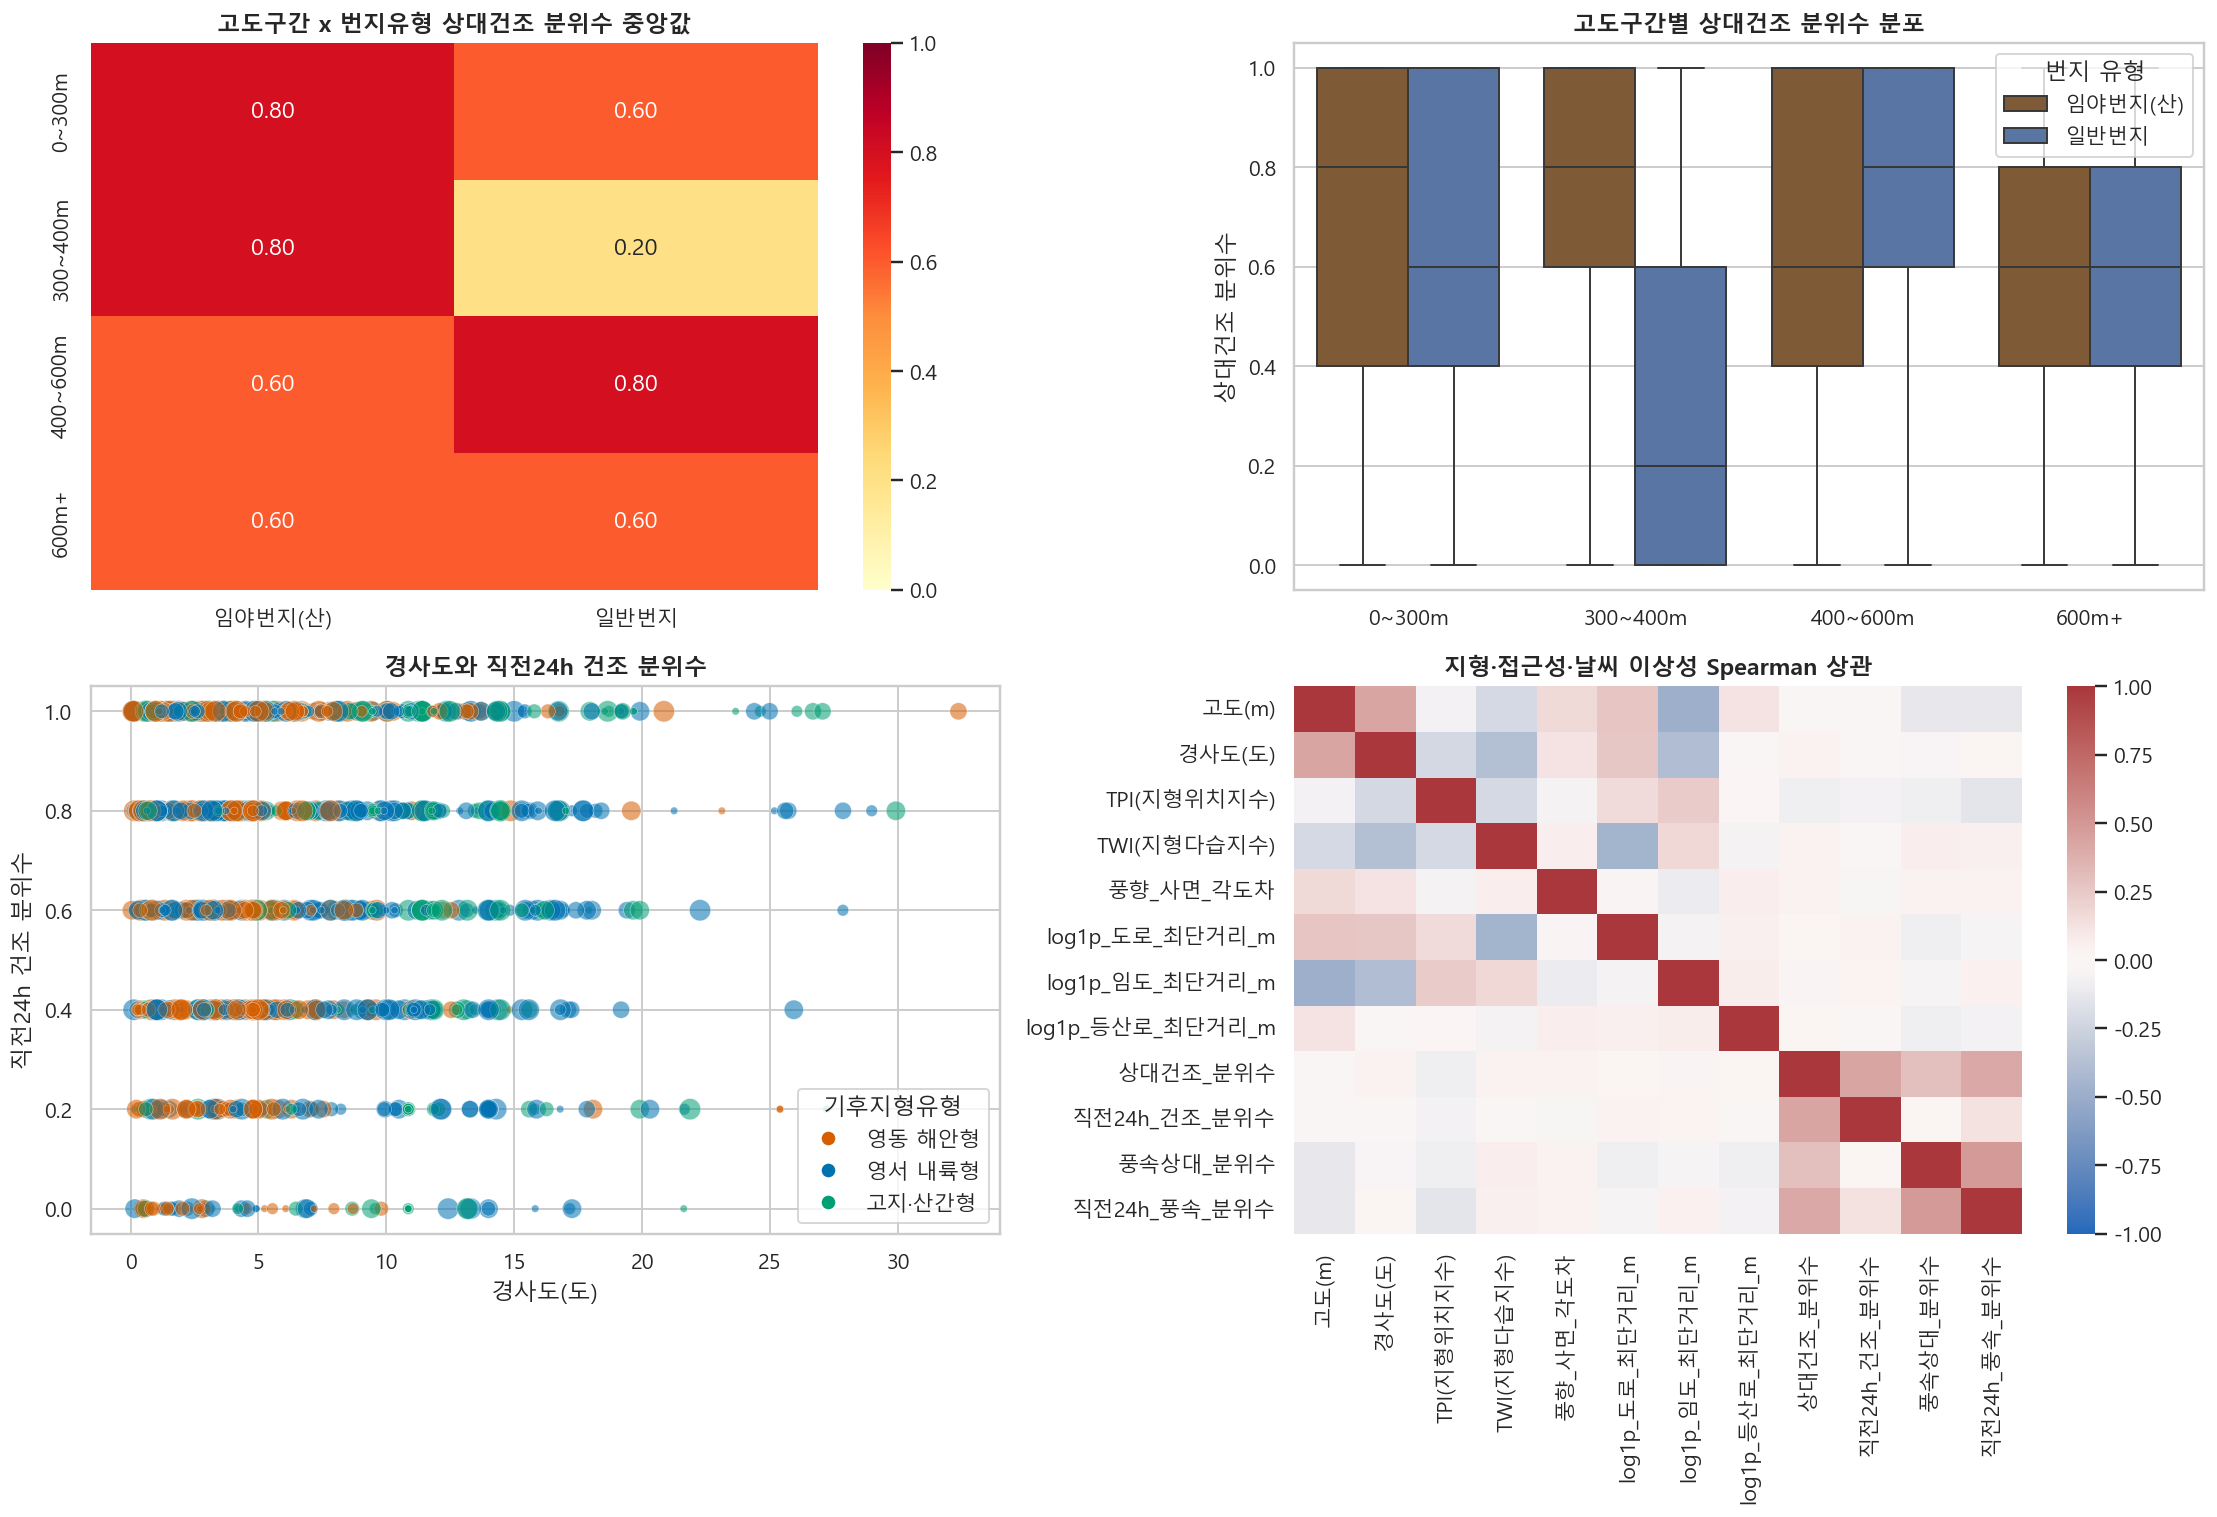

In [62]:
def kruskal_by_group(df, group_col, variables):
    rows = []
    for var in variables:
        groups = []
        labels = []
        for label, sub in df.groupby(group_col, observed=False):
            vals = sub[var].dropna()
            if len(vals) >= 5:
                groups.append(vals)
                labels.append(label)
        if len(groups) < 2:
            continue
        h, p = stats.kruskal(*groups)
        n = sum(len(g) for g in groups)
        rows.append({
            "그룹변수": group_col,
            "변수": var,
            "그룹수": len(groups),
            "유효표본수": n,
            "Kruskal_H": h,
            "epsilon²": epsilon_squared_kruskal(h, n, len(groups)),
            "p_value": p,
        })
    return rows

spatial_summary = fusion.groupby(["기후지형유형", "addr_type", "고도구간"], observed=False).agg(
    산불건수=("fire_id", "count"),
    발생시각_습도중앙값=("발생시각_습도_pct", "median"),
    직전24h_최소습도중앙값=("직전24h_최소습도", "median"),
    상대건조_분위수중앙값=("상대건조_분위수", "median"),
    풍속상대_분위수중앙값=("풍속상대_분위수", "median"),
    발생시각_풍속중앙값=("발생시각_풍속_m_s", "median"),
    직전24h_평균풍속중앙값=("직전24h_평균풍속", "median"),
    경사도중앙값=("경사도(도)", "median"),
    TWI중앙값=("TWI(지형다습지수)", "median"),
    도로거리중앙값=("도로_최단거리_m", "median"),
    임도거리중앙값=("임도_최단거리_m", "median"),
).reset_index()
display(Markdown("### 기후지형유형 x 번지유형 x 고도구간 요약"))
display(spatial_summary[spatial_summary["산불건수"] > 0].round(2))

mountain_alt = fusion[fusion["addr_type"] == "임야번지(산)"].groupby("임야_고도민감도구간", observed=False).agg(
    산불건수=("fire_id", "count"),
    비율_pct=("fire_id", lambda s: len(s) / max((fusion["addr_type"] == "임야번지(산)").sum(), 1) * 100),
    발생시각_습도중앙값=("발생시각_습도_pct", "median"),
    직전24h_최소습도중앙값=("직전24h_최소습도", "median"),
    발생시각_풍속중앙값=("발생시각_풍속_m_s", "median"),
    경사도중앙값=("경사도(도)", "median"),
    임도거리중앙값=("임도_최단거리_m", "median"),
    등산로거리중앙값=("등산로_최단거리_m", "median"),
)
display(Markdown("### 임야번지 고도 민감도: 250~500m 구간 확인"))
display(mountain_alt.round(2))

test_vars = [
    "상대건조_분위수", "직전24h_건조_분위수", "풍속상대_분위수", "직전24h_풍속_분위수",
    "발생시각_습도_pct", "직전24h_최소습도", "발생시각_풍속_m_s", "직전24h_평균풍속",
    "경사도(도)", "TWI(지형다습지수)", "도로_최단거리_m", "임도_최단거리_m", "등산로_최단거리_m",
]
test_rows = []
for group_col in ["기후지형유형", "addr_type", "고도구간", "풍향_사면_관계", "저습강풍_복합형"]:
    test_rows.extend(kruskal_by_group(fusion, group_col, test_vars))
space_tests = pd.DataFrame(test_rows)
space_tests["FDR"] = bh_fdr(space_tests["p_value"])
space_tests = space_tests.sort_values(["epsilon²", "Kruskal_H"], ascending=False).reset_index(drop=True)
display(Markdown("### 공간 그룹별 Kruskal-Wallis 검정 요약"))
display(space_tests.head(25).round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=140)
heat = fusion.pivot_table(
    index="고도구간",
    columns="addr_type",
    values="상대건조_분위수",
    aggfunc="median",
    observed=False,
).reindex(columns=ADDR_ORDER)
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[0, 0])
axes[0, 0].set_title("고도구간 x 번지유형 상대건조 분위수 중앙값", fontweight="bold")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

sns.boxplot(
    data=fusion,
    x="고도구간",
    y="상대건조_분위수",
    hue="addr_type",
    hue_order=ADDR_ORDER,
    palette=ADDR_PALETTE,
    ax=axes[0, 1],
)
axes[0, 1].set_title("고도구간별 상대건조 분위수 분포", fontweight="bold")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("상대건조 분위수")
axes[0, 1].legend(title="번지 유형")

sns.scatterplot(
    data=fusion.sample(min(len(fusion), 1800), random_state=RANDOM_STATE),
    x="경사도(도)",
    y="직전24h_건조_분위수",
    hue="기후지형유형",
    hue_order=TYPE_ORDER,
    palette=TYPE_PALETTE,
    size="풍속상대_분위수",
    sizes=(15, 120),
    alpha=0.55,
    legend=False,
    ax=axes[1, 0],
)
from matplotlib.lines import Line2D
type_handles = [
    Line2D([0], [0], marker="o", color="w", label=label, markerfacecolor=TYPE_PALETTE[label], markersize=8)
    for label in TYPE_ORDER
]
axes[1, 0].legend(handles=type_handles, title="기후지형유형", loc="lower right", frameon=True)
axes[1, 0].set_title("경사도와 직전24h 건조 분위수", fontweight="bold")
axes[1, 0].set_xlabel("경사도(도)")
axes[1, 0].set_ylabel("직전24h 건조 분위수")

corr_cols = [
    "고도(m)", "경사도(도)", "TPI(지형위치지수)", "TWI(지형다습지수)",
    "풍향_사면_각도차", "log1p_도로_최단거리_m", "log1p_임도_최단거리_m",
    "log1p_등산로_최단거리_m", "상대건조_분위수", "직전24h_건조_분위수",
    "풍속상대_분위수", "직전24h_풍속_분위수",
]
corr = fusion[corr_cols].corr(method="spearman")
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title("지형·접근성·날씨 이상성 Spearman 상관", fontweight="bold")
plt.tight_layout()
plt.show()


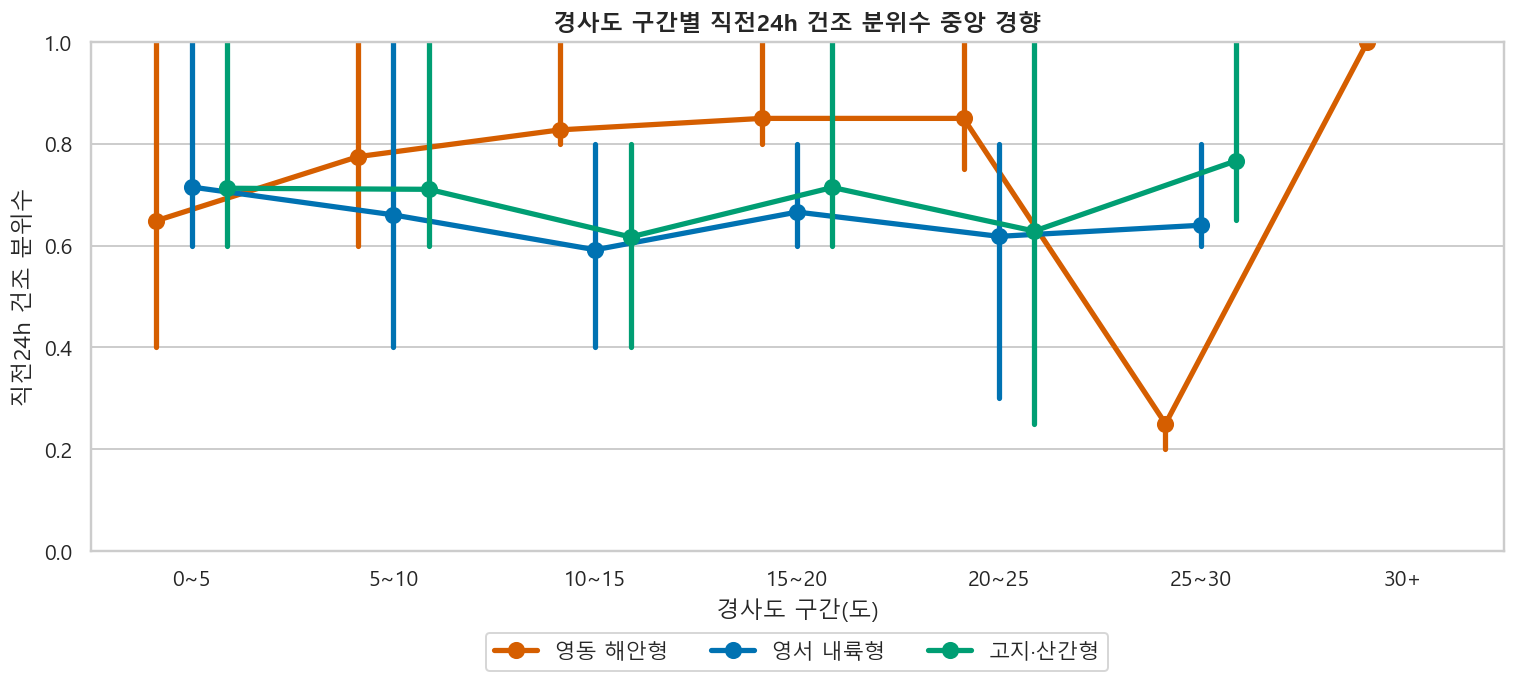

In [71]:
slope_bin_plot = fusion[
    ["기후지형유형", "경사도(도)", "직전24h_건조_분위수"]
].dropna().copy()

slope_bin_plot["경사도구간"] = pd.cut(
    slope_bin_plot["경사도(도)"],
    bins=[0, 5, 10, 15, 20, 25, 30, np.inf],
    labels=["0~5", "5~10", "10~15", "15~20", "20~25", "25~30", "30+"],
    include_lowest=True,
)

fig, ax = plt.subplots(figsize=(11, 5.6), dpi=140)

sns.pointplot(
    data=slope_bin_plot,
    x="경사도구간",
    y="직전24h_건조_분위수",
    hue="기후지형유형",
    hue_order=TYPE_ORDER,
    palette=TYPE_PALETTE,
    errorbar=("pi", 50),
    dodge=0.35,
    markers="o",
    linestyles="-",
    ax=ax,
)

ax.set_title("경사도 구간별 직전24h 건조 분위수 중앙 경향", fontweight="bold")
ax.set_xlabel("경사도 구간(도)")
ax.set_ylabel("직전24h 건조 분위수")
ax.set_ylim(0, 1)
sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, title=None, frameon=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

1. 기후지형유형 x 번지유형 x 고도구간 요약
> 기후지형유형(3종) x 번지유형(2종) 결합 요약 해석
- 고지·산간형 x 일반번지
  -  고도 및 건수: 400~600m 준고지대에서 167건으로 피크를 이루며, 600m 이상 고지대에서도 122건이 발생해 고지대 일반번지(생활권) 화재 비중이 매우 높습니다.
  -  습도 및 건조: 400m 미만 저지대에서는 습도가 56~70% 수준으로 높고 상대건조 분위수도 0.2로 습한 환경에서 불이 났지만, 400m 이상 고지대에서는 상대건조 분위수가 0.6 ~ 0.8로 급상승하며 매우 메마른 기상 조건에서만 산불이 발생했습니다.
  - 풍속: 저지대(0~300m)의 풍속 중앙값은 4.10m/s로 강한 반면, 고지대(600m+)는 1.85m/s로 오히려 잔잔한 바람에서 발생했습니다.
  - TWI 및 도로거리: TWI는 3.70 ~ 5.92 분포를 보이며, 도로거리 중앙값은 1.71m ~ 5.30m로 고지대 생활권임에도 도로 바로 옆에 발화점이 집중되어 있습니다.
-  고지·산간형 x 임야번지(산)
   -  고도 및 건수: 산림 내부(임야번지) 화재는 주로 400~600m(147건) 및 600m 이상(43건) 고지대에 집중 분포합니다.
   -  습도 및 건조: 상대건조 분위수가 0.6 ~ 0.8로 일정하게 높게 유지되어, 고지대 산림 화재는 대기가 평년 대비 확실히 건조한 상태여야 발생함을 의미합니다. (단, 300~400m 구간은 6건으로 표본 수가 너무 적어 통계적 해석에서 배제합니다).
   -  풍속: 저지대(4.02m/s)와 극고지대(600m+ 대역에서 3.35m/s)에서 높은 풍속을 보입니다.
   -  TWI 및 도로거리: TWI 중앙값이 3.59 ~ 3.99로 매우 낮아 수분이 부족한 사면/능선 지형에 해당합니다. 도로거리 중앙값은 11.13m ~ 36.76m로 생활권 화재보다 일반 도로와의 거리가 뚜렷하게 멀어 인프라로부터 격리된 지형입니다.
-  영동 해안형 x 일반번지
   -  고도 및 건수: 전체 산불의 99.8%가 0~300m 저지대(973건)에 몰려 있는 기형적 집중을 보입니다. (300m 이상 구간은 총 2건에 불과).
   -  습도 및 건조: 300m 이하 구간에서 습도 중앙값 46.90%, 최소습도 33.22%, 상대건조 분위수 0.60으로 준건조 상태를 띱니다.
   -  풍속: 발생시각 풍속 중앙값이 3.08m/s로 바람이 내륙에 비해 매우 강하게 불 때 산불이 났습니다.
   -  TWI 및 도로거리: 평지/분지 지형이 많아 TWI가 5.46으로 높게 나타나며, 도로거리 중앙값이 단 0.26m입니다. 즉, 이 그룹은 **"평탄한 해안 저지대 도로변 바로 옆에서 강풍을 타고 발생한 실화 산불"**로 요약됩니다.
-  영동 해안형 x 임야번지(산)
   -  고도 및 건수: 300m 이하 저지대 산림이 214건으로 다수이지만, 300m 이상 대역에서도 32건이 발생해 고지대 산림으로 확산되는 경향이 있습니다.
   -  습도 및 건조: 6개 그룹 중 기상 이상성이 가장 혹독합니다. 300m 이상 고도 산림의 습도는 19.28%, 직전 최소습도는 13.30%, 상대건조 분위수는 **1.0(역대 가장 건조한 0.1% 미만의 극단적 가뭄)**이었습니다.
   -  풍속: 발생시각 풍속 3.09m/s ~ 3.18m/s, 직전 평균풍속 3.34m/s ~ 3.55m/s의 강한 서풍 계열 강풍이 동반되었습니다.
   -  TWI 및 도로거리: TWI 중앙값은 2.56 ~ 3.24로 매우 건조한 능선 지형이며, 도로거리 중앙값은 고도가 높아질수록 9m에서 43m로 멀어집니다. "능선부 지형 + 역대급 가뭄 + 푄 강풍"이 결합한 대형 산불의 전형적 조건입니다.
-  영서 내륙형 x 일반번지
   -  고도 및 건수: 0 ~ 300m 저지대 생활권이 973건으로 절대다수이며, 300 ~ 600m 준고지대에서도 239건이 꾸준히 발생합니다.
   -  습도 및 건조: 400~600m 구간의 상대건조 분위수가 0.8로 가장 건조하며, 저지대에서도 0.6의 건조 상태가 요구됩니다.
   -  풍속: 발생시각 풍속 중앙값이 1.16m/s ~ 2.31m/s로 영동 해안형의 절반 이하 수준으로 매우 약합니다. 영서 생활권 화재는 강풍보다 대기 건조(습도 하락)가 주도합니다.
   -  TWI 및 도로거리: 생활권의 특성을 반영하여 TWI 중앙값이 4.34 ~ 5.48로 높고, 도로거리 중앙값 역시 1.79m ~ 4.43m로 도로 접근성이 매우 밀접합니다.
-  영서 내륙형 x 임야번지(산)
   -  고도 및 건수: 저지대부터 고지대까지 고르게 분포하며(총 330건), 영서 지역 산림의 넓은 분포도를 대변합니다.
   -  습도 및 건조: 고도와 무관하게 상대건조 분위수 0.60 ~ 0.80 대역이 요구되며, 발생 습도는 35~50% 수준입니다.
   -  풍속: 풍속 중앙값은 1.72m/s ~ 2.69m/s로 완만한 편입니다.
   -  TWI 및 도로거리: TWI는 2.45 ~ 3.04로 매우 메마른 능선/사면 지형입니다. 일반 도로와는 15m ~ 27m로 멀리 떨어져 있습니다.
-  고도구간 x 번지유형별 건조 분위수 차이
   -  임야번지(산)의 통계적 건조성 요구:
      -  히트맵과 박스 플롯에서 갈색 박스인 **임야번지(산)**는 고도 대역과 무관하게 분위수 중앙값이 0.60~0.80으로 항상 높게 유지됩니다.
      -  이는 실제 산림 내부에서 산불이 발화하고 대형화되기 위해서는 해발고도에 상관없이 평년 대비 상위 20~40% 이내의 강한 상대적 건조 상태가 항상 전제되어야 함을 증명합니다.
   -  일반번지 300~400m 구간의 분위수 급락(0.20) 원인 규명:
      -  히트맵과 박스 플롯을 보면, 일반번지(청색)의 300~400m 대역 분위수 중앙값이 **0.20(매우 습함)**으로 극단적으로 내려가 있습니다.
      -  영동 해안형 일반번지(1건), 영서 내륙형 일반번지(102건)에 비해 고지·산간형 일반번지 300~400m 대역의 산불 건수가 90건으로 다수를 점유하고 있습니다.
      -  즉, 이 고도 대역의 일반번지(주로 고지대 농가, 펜션, 사택 등 생활권)는 기상이 매우 다습함에도 불구하고 인위적인 실화원(소각 등)에 의해 기상 조건과 무관하게 불이 시작되었음을 해석할 수 있습니다.

2. 임야번지 고도 민감도 (250~500m 구간)
> 임야번지(산림 내부) 데이터만 추출하여 250~500m 고도 대역의 민감도를 분석
- 수분 감수성 격차: 
  - 고도가 낮을수록(0~250m 대역) 직전 최소습도 중앙값은 **25.87%**로 가장 낮고, 고지대(500m+ 대역)로 갈수록 **36.07%**로 높아집니다. 이는 저지대 산림이 물리적으로 수분을 더 빠르게 상실하며, 가벼운 대기 건조(상대적으로 높은 습도) 상황에서도 화재 발생 위험이 쉽게 고조됨을 나타냅니다.
- 중간 고도 대역(250~500m)의 지형·인적 취약성 집중:
  - 이 대역은 경사도 중앙값이 10.86°로 가장 가파릅니다. 경사가 가파르면 산불 확산 속도가 비약적으로 빨라지므로 지형적 위험도가 극대화됩니다.
  - 동시에, 등산로 최단거리 중앙값이 878m로 가장 짧습니다. 등산객 접근성이 가장 높은 구역이 급경사 지형 및 건조 조건과 겹쳐 있어 강원도 산림 관리에서 가장 취약한 벨트임을 보여줍니다.
- 진화 접근성의 반전: 
  - 고도가 500m 이상으로 올라갈수록 임도거리 중앙값은 **1,900m(1.9km)**로 가장 짧아집니다. 고지대 산불 진화 시 진입로 확보 및 수송 작전에서 임도의 활용도가 절대적임을 실증합니다.
- 저지대 산림의 높은 발화 민감성: 
  - 고도가 가장 낮은 0~250m 대역에서 직전 최소습도 중앙값이 **25.87%**로 가장 낮게 관측되었습니다. 이는 저지대 산림이 기온이 더 높아 수분 증발 속도가 빨라 건조화가 더 조기에 진행됨을 뜻합니다.
  - 고도가 0~250m에서 500m+로 높아질수록 강수 직전 최소습도 중앙값이 25.87%에서 36.07%로 10%p 이상 상승합니다. 이는 절대적인 대기 온도가 낮아 수분 증발 속도가 더디기 때문이며, 고지대일수록 더 오랜 시간 건조함이 축적되어야 함을 뜻합니다.
- 250~500m 대역의 물리적 위험 집중: 
  - 이 중간 고도 대역은 경사도 중앙값이 10.86°로 가장 가파르고, 동시에 등산로 거리 중앙값은 878m로 가장 짧습니다. 가파른 경사(화재 확산 가속)와 등산객 출입 빈도(실화원 노출)가 겹치는 최대 위험 벨트임을 증명합니다.
- 고지대 산림 진화의 임도 중요성: 
  - 고도가 500m 이상으로 올라갈수록 임도 최단거리 중앙값은 **1,900m(1.9km)**로 가장 짧아집니다. 고도가 높을수록 일반 도로는 멀어지지만 관리용 임도망이 가까워지므로, 고지대 화재 진압 시 임도가 핵심 진입로 및 방화선 역할을 담당하게 됨을 뜻합니다.

3. 공간 그룹별 Kruskal-Wallis 검정 요약
> 비모수 집단 차이 검정을 통해 도출한 결과의 물리적·통계적 의미
- 풍속 이상성이 산불 위험도 구분의 핵심 ($H=1,329.3, \epsilon^2=0.3908$): 
  - 저습강풍_복합형 그룹 분할이 직전24h_풍속_분위수에 미치는 효과크기(39%)가 분석 대상 중 가장 높습니다. 이는 산불 당일의 풍속 이상성(평년 바람보다 얼마나 강하게 불었는지)이 극단적인 대형 산불 위험일을 판별하는 가장 강력한 통계적 기준임을 의미합니다.
- 기후 유형에 따른 바람의 본질적 격차 ($\epsilon^2=0.3234$):
  - 기후지형유형 그룹이 직전24h_평균풍속에 대해 32.3%의 높은 효과크기를 가집니다. 이는 영동 해안형(양간지풍 지대)과 영서/고지형 간의 바람 세기가 통계적으로 완전히 다른 분포를 가진다는 물리적 격차를 지지합니다.
- 지형 수분 환경과 번지 유형의 밀접성 ($\epsilon^2=0.2182$):
  - 번지유형(addr_type)에 따라 TWI(지형다습지수)의 분포 차이가 21.8% 수준으로 큽니다. 일반번지는 평탄하고 다습한 평지/분지에 형성되지만, 산불이 발화하는 임야번지(산)는 지형적으로 배수가 매우 빠르고 건조한 능선사면에 집중되어 있음을 뜻합니다.
- 고도 대역별 도로 및 임도 격차 ($\epsilon^2=0.2241$ 및 $0.0411$): 
  - 고도구간에 따라 임도 거리는 매우 강한 격차(22.4%)를 보이지만, 일반 도로 거리와의 격차는 매우 미미(4.1%)합니다. 일반 도로는 고도와 무관하게 고르게 소외되지만, 임도는 고지대 산악 관리를 위해 집중 개설되어 있기 때문입니다.

4. 공간·접근성 변수와 날씨 이상성의 독립성 (상관관계 히트맵)
- 상관관계 차단 (White Block):
  - 스피어먼 상관계수 히트맵의 우하단에 위치한 날씨 이상성 변수들(상대건조_분위수, 직전24h_건조_분위수 등)과 지형 및 접근성 변수들(고도, 경사도, 도로거리, 등산로거리 등) 사이의 격자들은 **완전한 백색(상관계수 0 부근)**을 이룹니다.
  - 기상 분위수는 로컬 평상시 대비 상대적인 격차를 의미하므로 지형의 물리적 변수와는 완전히 독립적입니다. 즉, 침엽수가 많은 깊은 고지대나 도로 바로 옆 저지대나 산불이 발생하기 위해 도달해야 하는 최소한의 날씨 이상성(평년 기준을 벗어나는 건조도)의 역치는 모든 공간 영역에서 공통적으로 엄격하게 작용함을 의미합니다.
- 고도와 임도 거리의 음의 상관관계 (-0.30 ~ -0.40):
  - 고도(m)와 log1p_임도_최단거리_m은 **유의미한 파란색(음의 상관관계)**을 보입니다. 즉, 고도가 높을수록 산불 발생지와 임도 간의 거리가 더 가깝다는 뜻입니다.
  - **[테이블 3]**의 Kruskal-Wallis 검정에서도 고도구간에 따른 임도_최단거리_m의 집단 간 차이 효과크기($\epsilon^2$)가 0.2241로 공간 요인 중 가장 강하게 나타납니다.
  - 고지대 산악지역일수록 조림 및 관리를 위한 임도가 촘촘하게 분포되어 있으며, 고지대 산불 진입 및 방화선 구축 시 이 임도가 핵심적인 전략 거점이 됨을 데이터로 실증합니다.

5. 경사도 구간별 상대건조 요구 민감도
> 경사각이 커질수록 산불이 나기 위해 필요한 대기 건조도를 보여줍니다.
- 영동 해안형(주황색)의 우상향 흐름
  - 경사가 완만한 0 ~ 5도 대역에서는 요구 건조 분위수가 약 0.65이지만, 경사가 급해져 20 ~ 25도 대역에 이르면 분위수가 **0.85(최상위 15% 건조)**까지 치솟습니다. 급경사 지형일수록 훨씬 더 강력하게 마른 상태가 유지되어야만 산불로 연결됨을 뜻합니다.
  - 25~30도 구간의 급락(0.25) 노이즈: 주황색 선이 급격하게 꺾여 내려가지만, 이는 영동 해안형 지형 구조상 **25도 이상 경사지의 산불 샘플 수(1 ~ 2건 미만)가 극단적으로 적어서 발생한 통계적 이상치(노이즈)**이므로 해석에서 제외해야 합니다. (테이블 1의 영동 973건이 0 ~ 300m 완사면에 집중된 사실과 부합).
- 영서 내륙형(파란색) 및 고지·산간형(초록색)의 일관성:
  - 경사도와 무관하게 건조 분위수가 0.60~0.70 대역에서 매우 평탄하게 유지됩니다. 두 지역은 경사보다는 절대적인 누적 건조도 도달 여부가 화재를 결정함을 보여줍니다.

## 8. 종합 해석

아래 셀은 앞선 표와 검정 결과에서 핵심 수치를 가져와 이번 심화 EDA의 결론과 후속 과제를 자동 요약한다.


In [63]:
top_weather = paired_summary.sort_values("위험방향_dz", ascending=False).iloc[0]
top_wind = paired_summary[paired_summary["분류"] == "풍속"].sort_values("위험방향_dz", ascending=False).iloc[0]
top_space = space_tests.sort_values("epsilon²", ascending=False).iloc[0]
yd_wind = wind_stats[wind_stats["기후지형유형"] == "영동 해안형"].iloc[0]
yd_rain = rain_summary.loc["영동 해안형"]
complex_rate = (fire_weather["저습강풍_복합형"].eq("저습+강풍").mean() * 100)

display(Markdown(f'''
### 핵심 재요약

- 산불 원자료 3,405건 중 기상 격자에 매칭된 3,401건을 분석에 사용했다. 미매칭 4건은 기존 원칙대로 최근접 보정 없이 제외했다.
- 같은 기상셀·월·시간대의 매칭 비발생 대조군은 총 {len(matched):,}행이며, 산불 1건당 평균 {matched.groupby("fire_id").size().mean():.1f}개이다.
- 매칭 대조군 대비 가장 큰 위험방향 효과크기는 `{top_weather["변수"]}`이다. 위험방향 dz는 {top_weather["위험방향_dz"]:.2f}, FDR은 {top_weather["FDR"]:.2e}이다.
- 풍속 계열 중 가장 큰 위험방향 효과크기는 `{top_wind["변수"]}`이다. 즉 풍속은 산불 발생 전체의 단일 핵심 조건이라기보다, 지역별·공간별 산불 유형을 가르는 변수로 해석하는 것이 적절하다.
- 영동 해안형의 산불 서풍계열 비율은 {yd_wind["산불_서풍계열_pct"]:.1f}%이고, 매칭 비발생은 {yd_wind["매칭_서풍계열_pct"]:.1f}%이다. 산불 시점 풍향 분포는 평상시 풍향 분포와 분리해 해석해야 한다.
- 영동 해안형 산불 중 최근 24시간 내 강수 이후 발생 비율은 {yd_rain["최근24h_강수후발생비율"]:.1f}%이다. 강수량 자체보다 강수 후 경과 시간, 이후 습도 하락, 풍속 변화가 함께 필요하다.
- 전체 산불 중 저습과 강풍 상대 분위수가 동시에 높게 나타난 복합형 비율은 {complex_rate:.1f}%이다. 복합형은 특히 기후지형유형과 고도·사면 조건을 함께 봐야 한다.
- 공간 그룹별 검정에서 가장 큰 차이를 만든 조합은 `{top_space["그룹변수"]}` 기준의 `{top_space["변수"]}`이며, epsilon²는 {top_space["epsilon²"]:.3f}이다.

### 후속 분석으로 남길 것

- 이번 2차 융합은 산불 발생지 내부 비교이므로, 실제 위험 확률을 말하려면 동일 고도대·동일 지역의 비발생 공간 대조군을 별도로 만들어야 한다.
- `발생지역번지`의 `산` 여부는 공간 프록시이므로, 토지피복·지적·임상도 기반 산림/비산림 검증이 필요하다.
- 전력설비 위치 데이터는 최종 예측 대상이므로 이 노트북에서는 사용하지 않았다. 이후 모델링 단계에서만 별도로 결합해야 한다.
'''))



### 핵심 재요약

- 산불 원자료 3,405건 중 기상 격자에 매칭된 3,401건을 분석에 사용했다. 미매칭 4건은 기존 원칙대로 최근접 보정 없이 제외했다.
- 같은 기상셀·월·시간대의 매칭 비발생 대조군은 총 17,005행이며, 산불 1건당 평균 5.0개이다.
- 매칭 대조군 대비 가장 큰 위험방향 효과크기는 `직전24h 최소습도`이다. 위험방향 dz는 0.68, FDR은 4.53e-269이다.
- 풍속 계열 중 가장 큰 위험방향 효과크기는 `발생일 최대순간풍속`이다. 즉 풍속은 산불 발생 전체의 단일 핵심 조건이라기보다, 지역별·공간별 산불 유형을 가르는 변수로 해석하는 것이 적절하다.
- 영동 해안형의 산불 서풍계열 비율은 45.5%이고, 매칭 비발생은 39.6%이다. 산불 시점 풍향 분포는 평상시 풍향 분포와 분리해 해석해야 한다.
- 영동 해안형 산불 중 최근 24시간 내 강수 이후 발생 비율은 31.9%이다. 강수량 자체보다 강수 후 경과 시간, 이후 습도 하락, 풍속 변화가 함께 필요하다.
- 전체 산불 중 저습과 강풍 상대 분위수가 동시에 높게 나타난 복합형 비율은 39.4%이다. 복합형은 특히 기후지형유형과 고도·사면 조건을 함께 봐야 한다.
- 공간 그룹별 검정에서 가장 큰 차이를 만든 조합은 `저습강풍_복합형` 기준의 `직전24h_풍속_분위수`이며, epsilon²는 0.391이다.

### 후속 분석으로 남길 것

- 이번 2차 융합은 산불 발생지 내부 비교이므로, 실제 위험 확률을 말하려면 동일 고도대·동일 지역의 비발생 공간 대조군을 별도로 만들어야 한다.
- `발생지역번지`의 `산` 여부는 공간 프록시이므로, 토지피복·지적·임상도 기반 산림/비산림 검증이 필요하다.
- 전력설비 위치 데이터는 최종 예측 대상이므로 이 노트북에서는 사용하지 않았다. 이후 모델링 단계에서만 별도로 결합해야 한다.


## 9. 미진행 날씨 분석 보강: 전일 단위 시간날씨

기존 분석은 직전 `24/48/72시간` rolling 조건을 중심으로 보았다. 여기서는 달력일 기준 `전1일`, `전2일`, `전3일`의 시간단위 평균풍속, 최대풍속, 평균습도, 최소습도, 강수량합을 다시 집계한다.


### 전1~3일 달력일 기준 시간날씨 매칭 비교

,변수,분류,유효표본수,산불평균,대조평균,원차이_산불-대조,위험방향_평균차,위험방향_dz,paired_t_p,wilcoxon_p,FDR
0,D-1 최소습도,습도,3399,34.5435,42.8926,-8.3491,8.3491,0.5822,0.0000,0.0000,0.0000
1,D-1 평균습도,습도,3399,58.6419,65.6802,-7.0383,7.0383,0.5004,0.0000,0.0000,0.0000
2,D-3 평균습도,습도,3395,59.8570,65.3831,-5.5261,5.5261,0.3601,0.0000,0.0000,0.0000
3,D-2 강수량합,강수,3399,0.4767,1.6134,-1.1366,1.1366,0.3060,0.0000,0.0000,0.0000
4,D-3 최소습도,습도,3395,37.9626,42.9030,-4.9404,4.9404,0.3000,0.0000,0.0000,0.0000
5,D-1 강수량합,강수,3399,0.4044,1.6375,-1.2331,1.2331,0.2884,0.0000,0.0000,0.0000
6,D-2 최소습도,습도,3399,38.8045,42.7642,-3.9596,3.9596,0.2609,0.0000,0.0000,0.0000
7,D-3 강수량합,강수,3395,0.5390,1.5636,-1.0246,1.0246,0.2394,0.0000,0.0000,0.0000
8,D-3 최대풍속,풍속,3395,4.0583,3.8326,0.2258,0.2258,0.1534,0.0000,0.0000,0.0000
9,D-2 평균습도,습도,3399,63.6626,65.4095,-1.7469,1.7469,0.1384,0.0000,0.0000,0.0000


,변수,전체행,유효표본수,결측수,결측률_pct
0,D-1_평균풍속_m_s,3401,3399,2,0.06
1,D-1_최대풍속_m_s,3401,3399,2,0.06
2,D-1_평균습도_pct,3401,3399,2,0.06
3,D-1_최소습도_pct,3401,3399,2,0.06
4,D-1_강수량합_mm,3401,3399,2,0.06
5,D-2_평균풍속_m_s,3401,3399,2,0.06
6,D-2_최대풍속_m_s,3401,3399,2,0.06
7,D-2_평균습도_pct,3401,3399,2,0.06
8,D-2_최소습도_pct,3401,3399,2,0.06
9,D-2_강수량합_mm,3401,3399,2,0.06


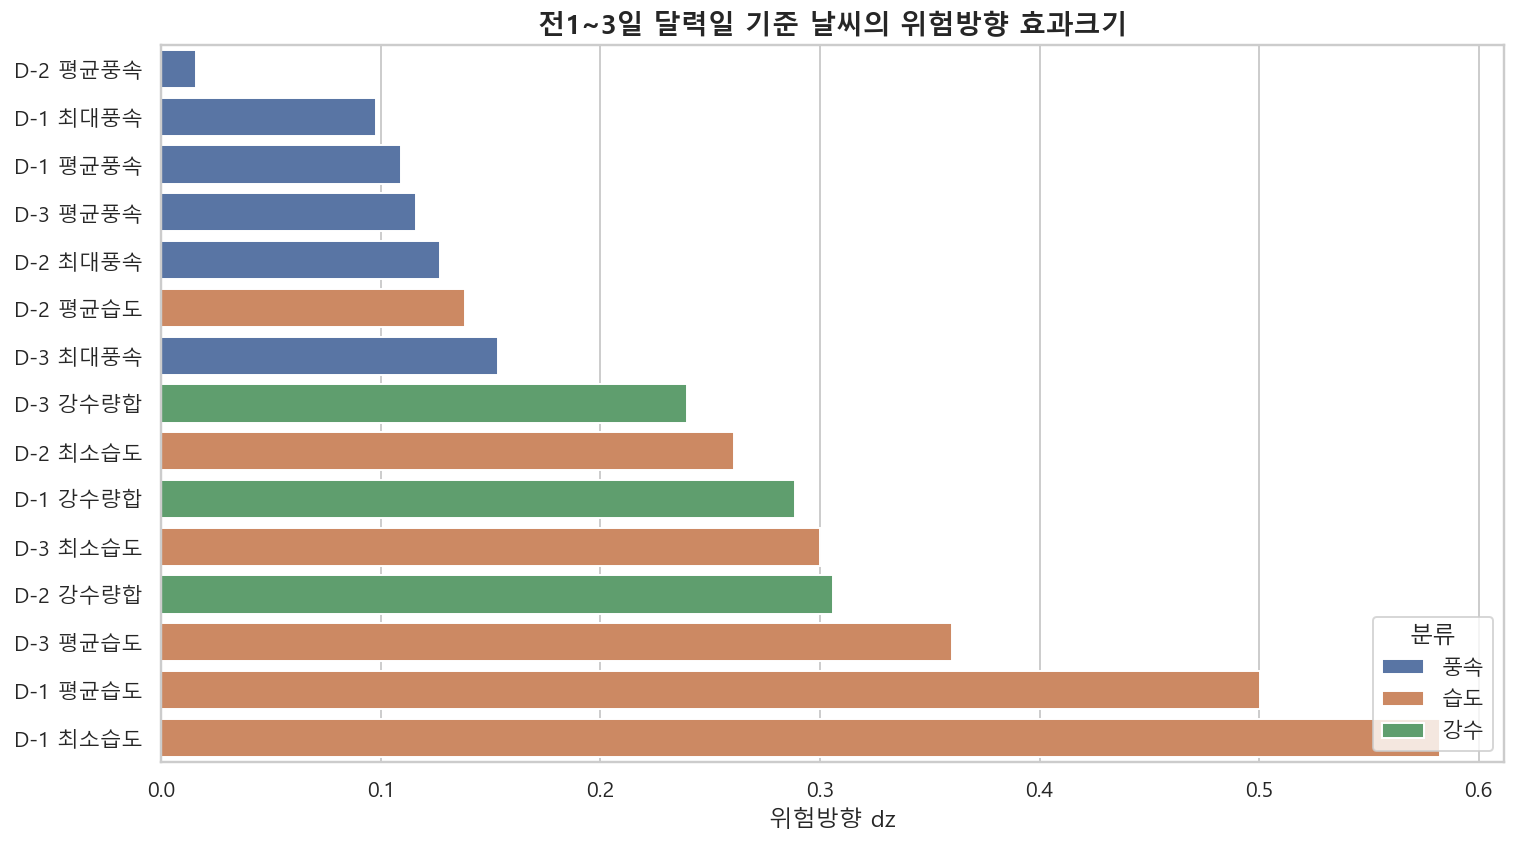

In [64]:
hourly_day = (
    hourly.groupby(["기상셀ID", "날짜"], as_index=False)
    .agg(
        일평균풍속_m_s=("풍속_m_s", "mean"),
        일최대풍속_m_s=("풍속_m_s", "max"),
        일평균습도_pct=("습도_pct", "mean"),
        일최소습도_pct=("습도_pct", "min"),
        일강수량합_mm=("강수량_mm", "sum"),
    )
)

def add_calendar_lag_weather_fire(base, lag):
    out = base.copy()
    date_col = f"전{lag}일"
    rename = {
        "일평균풍속_m_s": f"D-{lag}_평균풍속_m_s",
        "일최대풍속_m_s": f"D-{lag}_최대풍속_m_s",
        "일평균습도_pct": f"D-{lag}_평균습도_pct",
        "일최소습도_pct": f"D-{lag}_최소습도_pct",
        "일강수량합_mm": f"D-{lag}_강수량합_mm",
    }
    right = hourly_day.rename(columns={"날짜": date_col, **rename})
    return out.merge(right, on=["기상셀ID", date_col], how="left")

def add_calendar_lag_weather_control(base, lag):
    out = base.copy()
    date_col = f"대조_D-{lag}_날짜"
    out[date_col] = out["대조날짜"] - pd.to_timedelta(lag, unit="D")
    rename = {
        "일평균풍속_m_s": f"대조_D-{lag}_평균풍속_m_s",
        "일최대풍속_m_s": f"대조_D-{lag}_최대풍속_m_s",
        "일평균습도_pct": f"대조_D-{lag}_평균습도_pct",
        "일최소습도_pct": f"대조_D-{lag}_최소습도_pct",
        "일강수량합_mm": f"대조_D-{lag}_강수량합_mm",
    }
    right = hourly_day.rename(columns={"날짜": date_col, **rename})
    out = out.merge(right, on=["기상셀ID", date_col], how="left")
    return out.drop(columns=[date_col])

for lag in [1, 2, 3]:
    fire_weather = add_calendar_lag_weather_fire(fire_weather, lag)
    matched = add_calendar_lag_weather_control(matched, lag)

calendar_specs = []
for lag in [1, 2, 3]:
    calendar_specs.extend([
        {"label": f"D-{lag} 평균풍속", "category": "풍속", "fire_col": f"D-{lag}_평균풍속_m_s", "control_col": f"대조_D-{lag}_평균풍속_m_s", "lower_is_risk": False},
        {"label": f"D-{lag} 최대풍속", "category": "풍속", "fire_col": f"D-{lag}_최대풍속_m_s", "control_col": f"대조_D-{lag}_최대풍속_m_s", "lower_is_risk": False},
        {"label": f"D-{lag} 평균습도", "category": "습도", "fire_col": f"D-{lag}_평균습도_pct", "control_col": f"대조_D-{lag}_평균습도_pct", "lower_is_risk": True},
        {"label": f"D-{lag} 최소습도", "category": "습도", "fire_col": f"D-{lag}_최소습도_pct", "control_col": f"대조_D-{lag}_최소습도_pct", "lower_is_risk": True},
        {"label": f"D-{lag} 강수량합", "category": "강수", "fire_col": f"D-{lag}_강수량합_mm", "control_col": f"대조_D-{lag}_강수량합_mm", "lower_is_risk": True},
    ])

calendar_summary, _calendar_delta = paired_effect_summary(fire_weather, matched, calendar_specs)
display(Markdown("### 전1~3일 달력일 기준 시간날씨 매칭 비교"))
display(calendar_summary.round(4))
display(valid_summary(
    fire_weather,
    [f"D-{lag}_{name}" for lag in [1, 2, 3] for name in ["평균풍속_m_s", "최대풍속_m_s", "평균습도_pct", "최소습도_pct", "강수량합_mm"]],
))

fig, ax = plt.subplots(figsize=(11, 6.2), dpi=140)
plot = calendar_summary.sort_values("위험방향_dz", ascending=True)
sns.barplot(data=plot, x="위험방향_dz", y="변수", hue="분류", dodge=False, ax=ax)
ax.axvline(0, color="#333333", lw=1)
ax.set_title("전1~3일 달력일 기준 날씨의 위험방향 효과크기", fontsize=14, fontweight="bold")
ax.set_xlabel("위험방향 dz")
ax.set_ylabel("")
ax.legend(title="분류", loc="lower right")
plt.tight_layout()
plt.show()


- 하루 전(D-1), 이틀 전(D-2), 사흘 전(D-3)의 일단위 기상(평균/최대/최소/강수합)이 산불 발생에 어떤 선행 영향을 미치는지
1. 건조도(습도)의 압도적 지배성
   - 산불 발생 하루 전(D-1)의 습도 조건이 평상시 대조군에 비해 비정상적으로 매우 건조했습니다.
     - D-1 최소습도의 위험방향 효과크기 $d_z$는 0.5822로 전체 변수 중 가장 큽니다. 산불이 발생한 사례들의 D-1 최소습도 평균은 **34.5%**로 대조군(42.9%)에 비해 무려 8.35%p나 낮게 형성되었습니다.
     - D-1 평균습도($d_z = 0.5004$) 역시 매우 높은 수준의 효과크기를 보입니다.
   - 흥미롭게도 사흘 전인 D-3 평균습도($d_z = 0.3601$)와 D-3 최소습도($d_z = 0.3000$)가 이틀 전(D-2) 최소습도나 강수량 변수들보다 더 높은 이상성(효과크기)을 보입니다. 이는 대기가 하루 만에 갑자기 건조해진 것이 아니라, 최소 3일 전부터 건조한 공기가 누적·지속적으로 작용하며 산불 발생 여건을 조성했음을 방증합니다.
2. 누적 강수 결핍의 영향
   - D-1, D-2, D-3일의 누적 강수량 역시 대조군 대비 유의미하게 적었습니다.
     - D-2 강수량합($d_z = 0.3060$), D-1 강수량합($d_z = 0.2884$), D-3 강수량합($d_z = 0.2394$) 순으로 효과크기가 정렬되어 있습니다.
     - 산불 발생 1~3일 전 일단위 강수량 합계 평균은 0.4 ~ 0.5mm 수준으로, 평상시 대조군 평균(1.5 ~ 1.6mm)에 비해 매우 가물었습니다. 즉, 최소 3일 전부터 유의미한 강수가 차단되어 지면과 연료(낙엽 등)가 건조해진 상태였습니다.
3. 풍속(바람)의 매우 미미한 선행 이상성
   - 반면, D-1~D-3일의 평균풍속 및 최대풍속 변수들은 효과크기가 0.016 ~ 0.153 수준으로 극히 낮게 나타납니다.
     - 선행 풍속 변수 중 가장 큰 값을 갖는 D-3 최대풍속조차 $d_z = 0.1534$에 불과하며, 그래프 최상단에 있는 D-2 평균풍속($d_z = 0.0159$)은 거의 효과가 없는 수준(대조군과 차이가 없음)입니다.
     - 통계적 검정(FDR)상으로는 표본수가 많아 유의하다고 나오지만(p < 0.05), 효과크기가 미미하다는 것은 산불 발생 1~3일 전의 강풍 여부가 산불 발생을 예고하는 선행 조건으로 기능하지 못함을 뜻합니다.
     - 즉, 바람은 며칠 전부터 불어오는 징후라기보다는 산불 발생 당일의 발화 순간 및 확산 속도를 결정하는 단기 트리거에 가깝습니다.

산불 발생 1~3일 전의 예보 단위를 기준으로 위험을 예측할 때는 바람(풍속)보다는 습도의 이상 하락(D-1 최소습도 35% 미만 돌파 여부)과 강수량 부재를 주요 선행 모니터링 지표로 삼는 것이 통계적으로 훨씬 신뢰도가 높음을 이 분석이 명확하게 보여주고 있습니다.



## 10. 저온 경향과 2월·10월 계절성

README의 미진행 항목 중 하나는 산불 발생 시점의 저온 경향을 2월·10월 집중 현상과 연결하는 것이다. 여기서는 매칭 비발생군 대비 기온 차이를 월별·기후지형유형별로 확인한다. 종관 기압 배치 자료는 없으므로 현지기압·해면기압은 로컬 프록시로만 사용한다.


### 월별·기후지형유형별 기온/기압 프록시 비교

,월_key,기후지형유형,산불건수,산불_기온중앙값,대조_기온중앙값,기온차중앙값,기온차_P25,기온차_P75,현지기압차중앙값,해면기압차중앙값
0,1,고지·산간형,36,0.40,-1.55,3.21,0.55,4.69,4.18,3.51
1,1,영동 해안형,104,0.76,2.46,-2.45,-6.62,0.07,-0.06,0.10
2,1,영서 내륙형,66,3.16,0.21,2.12,-2.85,6.17,0.00,0.03
3,2,고지·산간형,203,2.29,0.70,0.43,-4.53,4.77,-2.16,-0.39
4,2,영동 해안형,682,6.82,6.68,1.08,-7.84,4.82,-0.70,-0.72
5,2,영서 내륙형,604,-4.61,0.86,-4.39,-7.33,-0.12,0.02,0.08
6,3,고지·산간형,30,13.90,8.80,5.60,1.33,7.95,0.02,-0.02
7,3,영동 해안형,60,11.68,10.54,1.48,-1.69,5.22,-0.19,-0.18
8,3,영서 내륙형,148,11.55,9.60,1.94,-1.03,5.99,0.03,0.02
9,4,고지·산간형,50,13.13,11.59,1.41,-0.47,5.24,-0.23,0.01


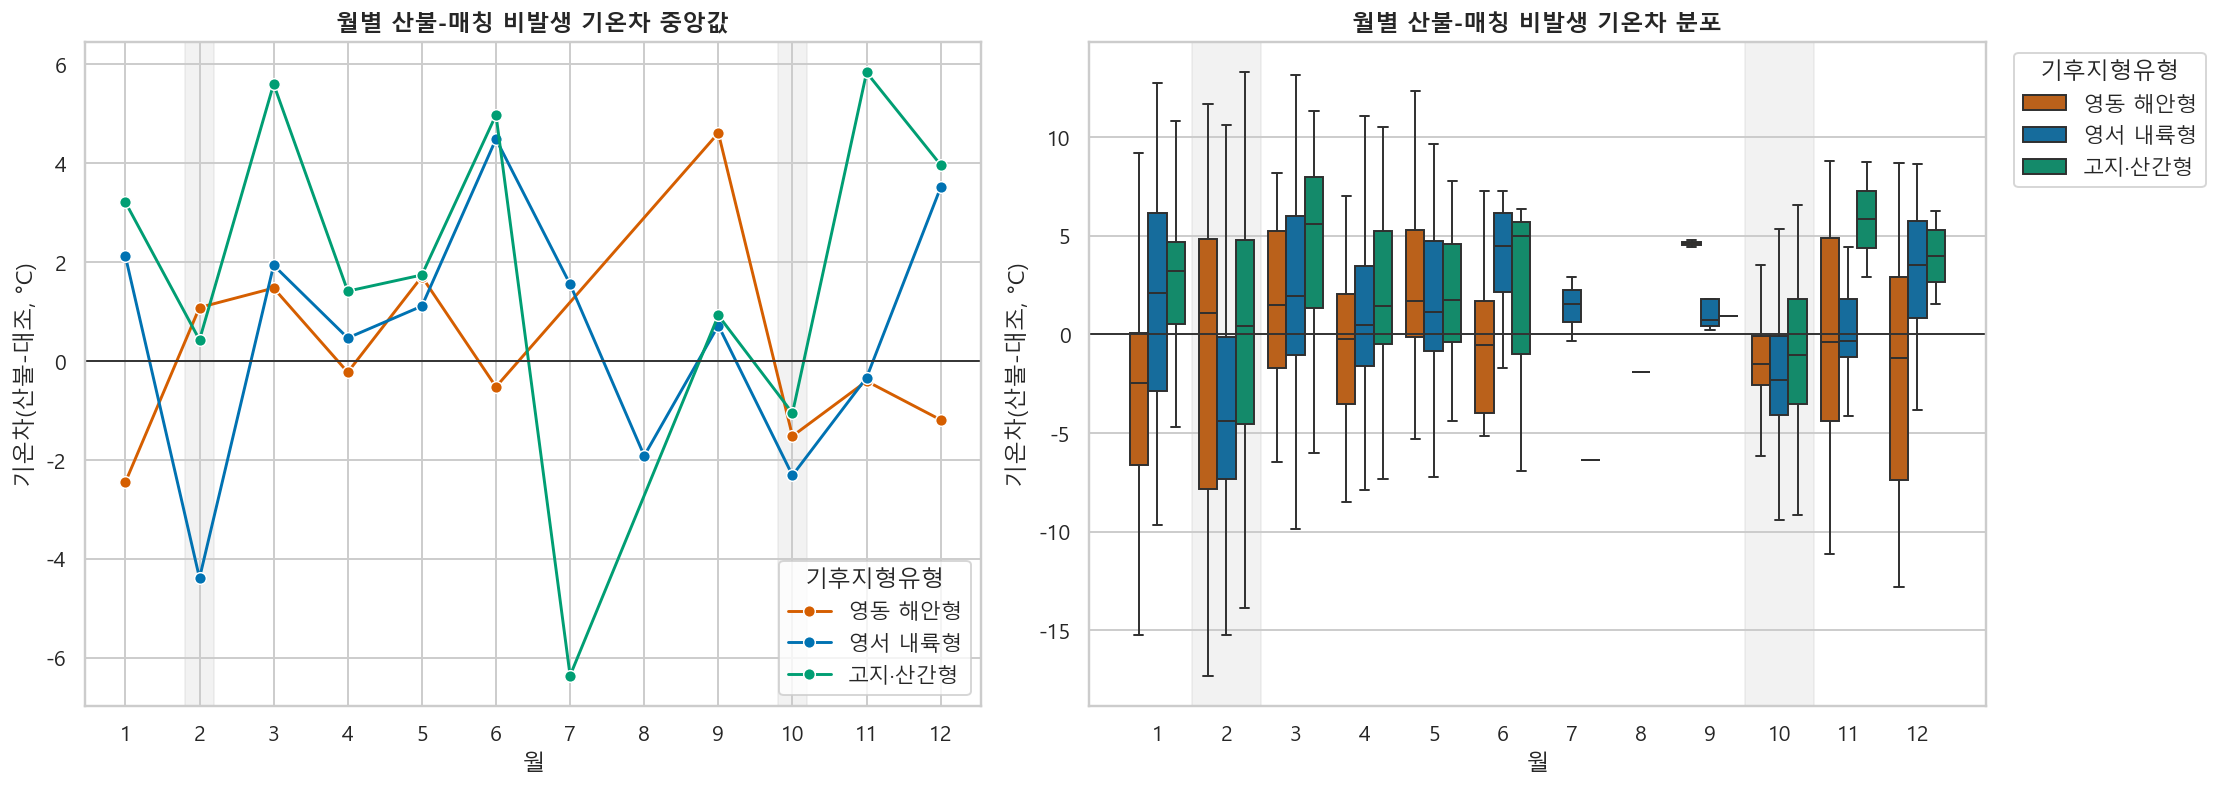

In [73]:
ctrl_temp = matched.groupby("fire_id").agg(
    대조_발생시각_기온_C=("기온_C", "mean"),
    대조_현지기압_hPa=("현지기압_hPa", "mean"),
    대조_해면기압_hPa=("해면기압_hPa", "mean"),
)

temp_compare = fire_weather.set_index("fire_id").join(ctrl_temp, how="left").reset_index()
temp_compare["발생시각_기온차_산불-대조"] = (
    temp_compare["발생시각_기온_C"] - temp_compare["대조_발생시각_기온_C"]
)
temp_compare["현지기압차_산불-대조"] = (
    temp_compare["발생시각_현지기압_hPa"] - temp_compare["대조_현지기압_hPa"]
)
temp_compare["해면기압차_산불-대조"] = (
    temp_compare["발생시각_해면기압_hPa"] - temp_compare["대조_해면기압_hPa"]
)
temp_compare["핵심월구분"] = np.select(
    [temp_compare["월_key"].eq(2), temp_compare["월_key"].eq(10)],
    ["2월", "10월"],
    default="그 외",
)

month_temp = temp_compare.groupby(["월_key", "기후지형유형"]).agg(
    산불건수=("fire_id", "count"),
    산불_기온중앙값=("발생시각_기온_C", "median"),
    대조_기온중앙값=("대조_발생시각_기온_C", "median"),
    기온차중앙값=("발생시각_기온차_산불-대조", "median"),
    기온차_P25=("발생시각_기온차_산불-대조", lambda s: s.quantile(0.25)),
    기온차_P75=("발생시각_기온차_산불-대조", lambda s: s.quantile(0.75)),
    현지기압차중앙값=("현지기압차_산불-대조", "median"),
    해면기압차중앙값=("해면기압차_산불-대조", "median"),
).reset_index()

display(Markdown("### 월별·기후지형유형별 기온/기압 프록시 비교"))
display(month_temp.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), dpi=140)

sns.lineplot(
    data=month_temp,
    x="월_key",
    y="기온차중앙값",
    hue="기후지형유형",
    hue_order=TYPE_ORDER,
    palette=TYPE_PALETTE,
    marker="o",
    ax=axes[0],
)
axes[0].axhline(0, color="#333333", lw=1)
axes[0].axvspan(1.8, 2.2, color="#cccccc", alpha=0.25)
axes[0].axvspan(9.8, 10.2, color="#cccccc", alpha=0.25)
axes[0].set_xticks(range(1, 13))
axes[0].set_title("월별 산불-매칭 비발생 기온차 중앙값", fontweight="bold")
axes[0].set_xlabel("월")
axes[0].set_ylabel("기온차(산불-대조, °C)")

plot_temp = temp_compare[
    temp_compare["발생시각_기온차_산불-대조"].notna()
].copy()

sns.boxplot(
    data=plot_temp,
    x="월_key",
    y="발생시각_기온차_산불-대조",
    hue="기후지형유형",
    hue_order=TYPE_ORDER,
    palette=TYPE_PALETTE,
    showfliers=False,
    ax=axes[1],
)
axes[1].axhline(0, color="#333333", lw=1)
axes[1].axvspan(0.5, 1.5, color="#cccccc", alpha=0.25)
axes[1].axvspan(8.5, 9.5, color="#cccccc", alpha=0.25)
axes[1].set_title("월별 산불-매칭 비발생 기온차 분포", fontweight="bold")
axes[1].set_xlabel("월")
axes[1].set_ylabel("기온차(산불-대조, °C)")
axes[1].legend(title="기후지형유형", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

-  저온 경향과 2월·10월 계절성
> 강원도 산불 발생 시기에서 종종 나타나는 **"평상시보다 추운 날씨에 산불이 더 빈발하는 저온 이상성(Cold Anomaly)"**을, 산불이 가장 집중되는 두 시기인 **2월(늦겨울/초봄)**과 **10월(가을 전환기)**의 종관 기상 패턴(대륙고기압 확장 및 산악 효과)과 연결하여 원인을 해석  
> 대조군 대비 기온차(산불 시점 기온 - 대조군 평균 기온)와 기압차(산불 시점 기압 - 대조군 평균 기압)를 계산하여, 특정 시점의 저온과 기압 변화가 어떤 기상 현상(예: 찬 고기압 북서풍 유입, 산맥을 넘어가는 푄 현상 등)을 프록시(대리 변수)로 나타내는지

1. 2월 (늦겨울·초봄 전환기): 영서 내륙의 한파 vs 영동 해안의 단열승온 (양 극단의 거동)
   - 2월의 선그래프와 박스플롯을 보면, 태백산맥을 경계로 영서와 영동이 완전히 다른 기온차 방향성을 보입니다.
   - 영서 내륙형 (파란색 선/박스) - 극심한 저온 이상성 (-4.39 °C)
     - 해석: 영서 내륙은 대조군 대비 기온 중앙값이 무려 4.4°C 가까이 낮게 나타납니다. 박스플롯을 보면 영서 내륙의 75% 분위수(Q3)마저도 0°C 이하에 머물러 있어, 산불이 나는 거의 대부분의 날이 평소보다 추웠음을 보여줍니다. 
     - 원인: 이는 겨울철 시베리아 대륙고기압이 강력하게 한반도로 확장하여 차고 건조한 북서풍 한파가 직접 밀려올 때, 영서 내륙이 이 찬 공기의 직접적인 영향을 받으며 공기가 매우 건조해지고 화재가 다발했음을 뜻합니다.
   - 영동 해안형 (황토색 선/박스) - 국지적 온난화 (+1.08 °C) 및 기압 하락 (-0.72 hPa)
     - 해석: 반면, 같은 2월인데도 영동 해안은 오히려 평소보다 기온이 약 1.1°C 높고, 기압은 대조군 대비 낮은 상태에서 산불이 났습니다
     - 원인: 이는 전형적인 **푄 현상(양간지풍/강풍)**의 결과입니다. 북서풍의 찬 공기가 태백산맥을 넘으면서 영동 해안 쪽으로 하강할 때, 공기가 압축되며 온도가 올라가고(단열승온) 습도가 극도로 낮아집니다. 산맥 동쪽 사면에서는 강풍과 함께 국지적인 고온 건조 환경이 형성되므로 기온차는 플러스가 되고, 강한 하강 기류와 역학적 영향으로 기압은 평소보다 다소 낮게 관측되는 것입니다.
   - 고지·산간형 (초록색 선/박스) - 중립적 상태 (+0.43 °C)
     - 산맥 정상 부근인 고지대는 찬 공기 유입과 풍하측 하강 기류가 교차하는 경계 지역이므로 기온차가 0에 가깝게 상쇄되는 중립적 특성을 보입니다.
2. 10월 (가을 전환기): 찬 대륙고기압 확장으로 인한 전역적 저온·고기압 이상성
   - 10월의 선그래프와 박스플롯을 보면 2월과 달리, 모든 기후지형 유형이 0선 아래로 꺾이며 저온 이상성을 공유합니다.
   - 전 기후유형의 저온 이상성 동조화 (-1.05°C ~ -2.31°C)  
     - 해석: 10월에는 영서 내륙(-2.31°C)뿐만 아니라 영동 해안(-1.52°C), 고지·산간(-1.05°C) 모두 기온 중앙값 차이가 마이너스를 기록하고 있으며, 박스플롯상 분포의 중심이 아래로 이동해 있습니다.
   - 영동 해안형의 뚜렷한 양(+)의 기압차 (+2.48 hPa)
     - 해석: 기온은 평소보다 낮은 반면, 영동 해안의 기압차 중앙값은 대조군보다 2.48 hPa이나 매우 높게 나타납니다.
     - 원인: 가을철 첫 산불 시즌이 시작되는 10월은 첫 대륙고기압이 한반도로 확장해 들어오는 시기입니다. 맑고 건조한 고기압의 중심 또는 영향권에 놓이게 되면 강한 복사냉각으로 인해 기온이 떨어지면서(저온 이상성), 기압은 상승하고(고기압 이상성), 대기는 극도로 건조해집니다. 이 시기에 강원도 전역에 가을철 산불 위험이 급증하게 됨을 프록시를 통해 확인할 수 있습니다.

- 즉, 강원도 산불의 계절적 저온 경향은 **"대륙고기압의 확장(10월 강원 전역 및 2월 영서)과 이에 수반된 산악 지형 효과(2월 영동의 푄 현상)"**이 결합하여 극단적인 건조를 만들어내는 기상학적 메커니즘이 수치와 그래프로 완벽히 투영된 결과로 해석할 수 있습니다.

## 11. 절대 습도 기준과 상대 건조도 기준 후보

같은 절대 습도라도 기후지형유형·번지유형·고도구간에 따라 의미가 달라진다. 여기서는 산불 사례의 절대 습도 분위수와 매칭 비발생 대비 상대 건조 분위수를 함께 제시해 임계치 후보를 만든다.


### 기후지형유형별 임계치 후보

,기후지형유형,산불건수,발생시각_습도_pct_P25,발생시각_습도_pct_P50,발생시각_습도_pct_P75,직전24h_최소습도_P25,직전24h_최소습도_P50,직전24h_최소습도_P75,상대건조_분위수_P25,상대건조_분위수_P50,상대건조_분위수_P75,직전24h_건조_분위수_P25,직전24h_건조_분위수_P50,직전24h_건조_분위수_P75,발생시각_풍속_m_s_P25,발생시각_풍속_m_s_P50,발생시각_풍속_m_s_P75,발생일_최대순간풍속_m_s_P25,발생일_최대순간풍속_m_s_P50,발생일_최대순간풍속_m_s_P75
0,고지·산간형,622,39.37,56.72,72.29,26.56,34.01,42.40,0.2,0.6,0.8,0.4,0.8,1.0,1.11,1.82,3.38,5.67,8.01,11.19
1,영동 해안형,1221,22.92,44.63,58.03,17.78,33.15,41.33,0.4,0.6,1.0,0.4,0.8,1.0,2.17,3.09,4.20,7.98,10.50,13.59
2,영서 내륙형,1558,34.17,51.82,64.81,25.28,29.91,36.07,0.4,0.6,1.0,0.4,0.8,1.0,0.73,1.43,2.69,5.60,6.98,9.58


### 기후지형유형 x 번지유형 임계치 후보

,기후지형유형,addr_type,산불건수,발생시각_습도_pct_P25,발생시각_습도_pct_P50,발생시각_습도_pct_P75,직전24h_최소습도_P25,직전24h_최소습도_P50,직전24h_최소습도_P75,상대건조_분위수_P25,상대건조_분위수_P50,상대건조_분위수_P75,직전24h_건조_분위수_P25,직전24h_건조_분위수_P50,직전24h_건조_분위수_P75,발생시각_풍속_m_s_P25,발생시각_풍속_m_s_P50,발생시각_풍속_m_s_P75,발생일_최대순간풍속_m_s_P25,발생일_최대순간풍속_m_s_P50,발생일_최대순간풍속_m_s_P75
0,고지·산간형,일반번지,413,38.91,55.89,70.24,25.50,33.48,39.37,0.2,0.6,0.8,0.6,0.8,1.0,1.36,2.46,3.47,4.81,7.30,12.37
1,고지·산간형,임야번지(산),209,39.37,57.52,79.12,32.50,39.37,63.54,0.2,0.6,0.8,0.2,0.6,0.8,0.56,1.63,2.93,5.83,8.01,9.82
2,영동 해안형,일반번지,975,28.62,46.90,59.70,21.15,33.22,43.05,0.4,0.6,1.0,0.4,0.8,1.0,2.08,3.08,4.14,7.19,10.46,13.34
3,영동 해안형,임야번지(산),246,18.23,28.72,46.90,13.30,17.34,33.15,0.6,0.8,1.0,0.6,1.0,1.0,2.28,3.09,4.37,10.42,10.50,13.71
4,영서 내륙형,일반번지,1228,34.17,52.57,68.67,25.56,30.04,35.99,0.4,0.6,1.0,0.6,0.8,1.0,0.69,1.31,2.47,5.60,6.92,9.58
5,영서 내륙형,임야번지(산),330,30.02,41.99,56.53,22.79,28.14,37.75,0.4,0.8,1.0,0.4,0.8,0.8,1.22,2.18,3.19,5.70,7.61,9.65


### 기후지형유형 x 번지유형 x 고도구간 임계치 후보

,기후지형유형,addr_type,고도구간,산불건수,발생시각_습도_pct_P25,발생시각_습도_pct_P50,발생시각_습도_pct_P75,직전24h_최소습도_P25,직전24h_최소습도_P50,직전24h_최소습도_P75,상대건조_분위수_P25,상대건조_분위수_P50,상대건조_분위수_P75,직전24h_건조_분위수_P25,직전24h_건조_분위수_P50,직전24h_건조_분위수_P75,발생시각_풍속_m_s_P25,발생시각_풍속_m_s_P50,발생시각_풍속_m_s_P75,발생일_최대순간풍속_m_s_P25,발생일_최대순간풍속_m_s_P50,발생일_최대순간풍속_m_s_P75
0,고지·산간형,일반번지,0~300m,34,47.44,55.89,69.29,25.58,26.79,34.01,0.2,0.2,0.6,0.60,0.8,1.0,1.82,4.10,5.72,6.85,11.42,17.29
1,고지·산간형,일반번지,300~400m,90,69.98,69.98,84.31,26.70,34.01,52.04,0.0,0.2,0.4,0.45,0.8,1.0,1.42,1.69,1.69,3.93,4.08,9.10
2,고지·산간형,일반번지,400~600m,167,38.91,40.00,64.90,26.60,32.50,36.51,0.4,0.8,1.0,0.60,0.8,1.0,2.22,2.93,3.38,5.73,9.10,12.58
3,고지·산간형,일반번지,600m+,122,41.40,58.37,72.29,23.27,33.50,42.40,0.4,0.6,0.8,0.45,0.8,1.0,1.07,1.85,3.49,4.81,7.68,10.58
6,고지·산간형,임야번지(산),400~600m,147,39.58,57.52,79.12,36.51,39.37,63.54,0.2,0.6,1.0,0.20,0.6,1.0,0.56,1.37,1.79,5.76,8.01,8.01
7,고지·산간형,임야번지(산),600m+,43,36.32,56.84,64.78,23.98,39.04,55.18,0.4,0.6,0.8,0.40,0.6,0.8,2.13,3.35,4.35,7.63,10.61,11.14
8,영동 해안형,일반번지,0~300m,973,28.63,46.90,59.93,21.15,33.22,43.05,0.4,0.6,1.0,0.40,0.8,1.0,2.08,3.08,4.14,7.19,10.46,13.34
12,영동 해안형,임야번지(산),0~300m,214,18.23,32.46,46.90,13.06,19.76,33.15,0.6,0.8,1.0,0.60,1.0,1.0,2.28,3.09,4.38,10.42,10.50,13.80
16,영서 내륙형,일반번지,0~300m,973,34.17,51.75,69.55,25.30,28.36,31.63,0.4,0.6,1.0,0.60,0.8,1.0,0.69,1.16,2.44,5.60,6.25,9.32
17,영서 내륙형,일반번지,300~400m,102,39.62,58.41,76.93,26.14,32.00,36.04,0.0,0.4,1.0,0.40,0.6,0.8,0.40,1.68,2.80,5.04,9.65,12.14


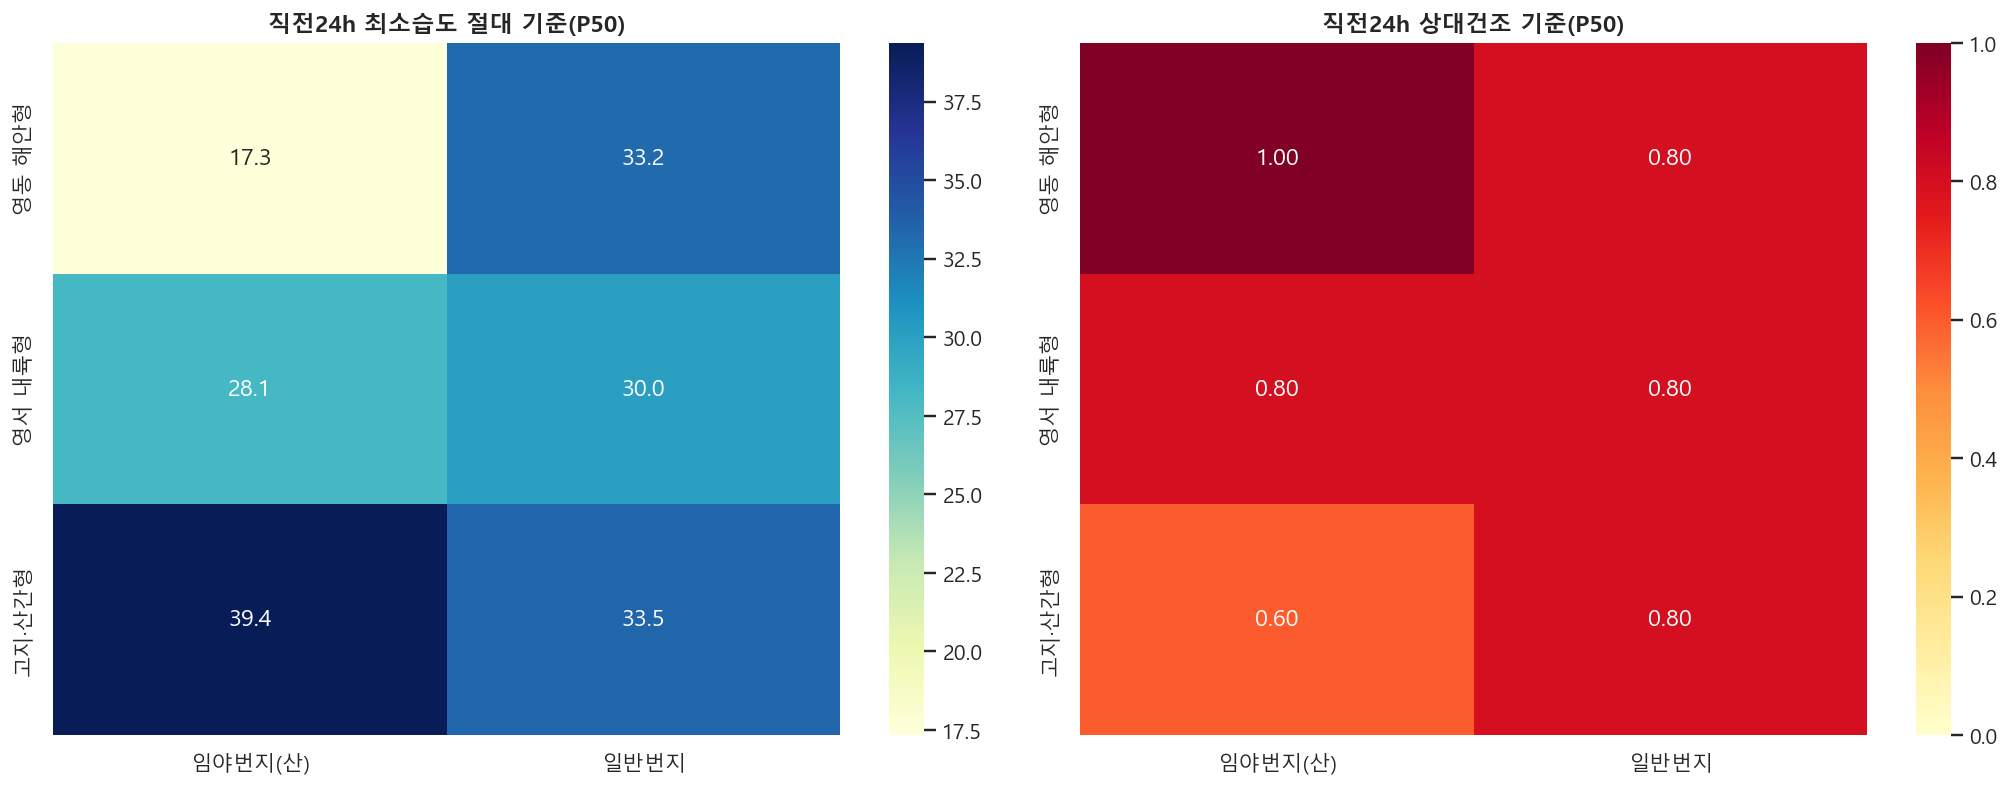

In [66]:
threshold_base = fusion.copy() if "fusion" in globals() else fire_weather.copy()

def threshold_table(df, group_cols):
    rows = []
    for keys, sub in df.groupby(group_cols, observed=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["산불건수"] = len(sub)
        for col in ["발생시각_습도_pct", "직전24h_최소습도", "상대건조_분위수", "직전24h_건조_분위수", "발생시각_풍속_m_s", "발생일_최대순간풍속_m_s"]:
            vals = sub[col].dropna()
            row[f"{col}_P25"] = vals.quantile(0.25) if len(vals) else np.nan
            row[f"{col}_P50"] = vals.quantile(0.50) if len(vals) else np.nan
            row[f"{col}_P75"] = vals.quantile(0.75) if len(vals) else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

type_thresholds = threshold_table(threshold_base, ["기후지형유형"])
cross_thresholds = threshold_table(threshold_base, ["기후지형유형", "addr_type"])
altitude_thresholds = threshold_table(threshold_base, ["기후지형유형", "addr_type", "고도구간"]) if "고도구간" in threshold_base.columns else pd.DataFrame()

display(Markdown("### 기후지형유형별 임계치 후보"))
display(type_thresholds.round(2))
display(Markdown("### 기후지형유형 x 번지유형 임계치 후보"))
display(cross_thresholds.round(2))
if not altitude_thresholds.empty:
    display(Markdown("### 기후지형유형 x 번지유형 x 고도구간 임계치 후보"))
    display(altitude_thresholds[altitude_thresholds["산불건수"] >= 20].round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), dpi=140)
heat_abs = cross_thresholds.pivot(index="기후지형유형", columns="addr_type", values="직전24h_최소습도_P50").reindex(index=TYPE_ORDER, columns=ADDR_ORDER)
sns.heatmap(heat_abs, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("직전24h 최소습도 절대 기준(P50)", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
heat_rel = cross_thresholds.pivot(index="기후지형유형", columns="addr_type", values="직전24h_건조_분위수_P50").reindex(index=TYPE_ORDER, columns=ADDR_ORDER)
sns.heatmap(heat_rel, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("직전24h 상대건조 기준(P50)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


- 강원도 전역에 동일한 산불 경보 습도 기준(예: 최소습도 30%)을 적용하는 것이 타당한가?
> 절대 건조 기준 (최소습도 %의 P50/중앙값): 실제로 공기가 얼마나 건조한가  
> 상대 건조 기준 (대조군 대비 분위수의 P50/중앙값): 해당 지역/시간대의 평상시 날씨와 비교해 얼마나 이례적으로 건조한가 (1.00에 가까울수록 역사상 가장 극단적인 이상 건조 상태)

1. 히트맵 및 교차 테이블(cross_thresholds) 해석
> 기후지형유형과 **번지유형(임야/일반)**에 따른 최소습도 절대값(좌)과 상대건조 분위수(우)의 중앙값(P50)
- 영동 해안형 임야(산) 산불: 역사상 최악의 극단적 기상 조건 요구
   - 데이터: 최소습도 절대값 17.3% / 상대건조 분위수 1.00 (산불건수 246건)
   - 해석: 영동 해안형의 깊은 산(임야번지)에서 산불이 발생하려면 단순히 건조한 수준이 아니라, 평상시 날씨 대비 상위 100%(분위수 1.00)에 해당하는 역사상 가장 건조한 날씨와 17%대라는 극도로 마른 대기가 결합해야만 합니다. 이는 저지대 동해안 산림이 자연 발화하거나 확산되기 위해서는 기상학적 트리거가 극도로 강해야 함을 보여줍니다.
- 고지·산간형 임야(산) 산불: 기후적 취약성으로 인해 완만한 이상성에서도 발생
   - 데이터: 최소습도 절대값 39.4% / 상대건조 분위수 0.60 (산불건수 209건)
   - 해석: 고지·산간형 임야에서는 절대 최소습도가 40%에 육박하는 상태이거나, 대조군 대비 상위 60%(분위수 0.60) 수준의 완만한 이상 건조 상태에서도 산불이 쉽게 빈발했습니다.
   - 의미: 고지대 산림 지역은 침엽수 비중이 높고 험준하여 물리적으로 화재에 매우 취약합니다. 따라서 영동 해안처럼 대기가 바짝 마르지 않더라도(40%에 가까운 비교적 높은 습도에서도) 쉽게 불이 붙고 확산될 수 있음을 의미합니다.
   - 임계치 설정의 시사점: 만약 산불 위험 경보 기준을 강원도 전체에 일률적으로 "습도 30% 이하"로 적용한다면, 영동 임야에서는 경보가 남발되는 반면, 고지·산간형 임야(39.4%에서 불이 남)는 경보 누락으로 인한 대형 재난이 발생할 수 있습니다.
- 일반번지(인적 영역) 산불: 기상 강도와 무관한 '일정한 실화 취약성'
  - 데이터: 모든 기후유형의 일반번지 상대건조 분위수 중앙값 0.80 동일
    - 영동 해안형 일반: 33.2% (분위수 0.80) / 영서 내륙형 일반: 30.0% (분위수 0.80) / 고지·산간형 일반: 33.5% (분위수 0.80)
  - 해석: 도로변, 농경지, 인가 주변 등 사람이 많이 활동하는 '일반번지'는 지역을 불문하고 대조군 대비 상위 80% 분위수 수준의 적당한 건조일이면 인적 실화 요인과 결합해 상시적으로 불이 납니다. 즉, 사람이 거주하는 곳에서는 기상학적 극한 사태가 아니더라도 상시적인 주의가 필요함을 보여줍니다.

2. 풍속 및 기압 테이블을 통한 추가 현상 해석 (강풍형 vs 건조형)
> 습도뿐만 아니라 풍속 데이터(Table 1, Table 2)를 추가 연계하면 강원도 산불의 두 가지 서로 다른 메커니즘이 뚜렷이 대비
- 영동 해안형 - "강풍 주도형" 산불
  - 풍속 데이터: 발생 당일 최대순간풍속 중앙값이 10.5 m/s(P75는 13.7 m/s 이상)에 달하며 발생 시각 풍속도 3.1 m/s로 매우 강함.
  - 해석: 영동 지역은 기온 이상성과 더불어 태백산맥을 넘어오는 강한 바람이 불꽃을 날리고 확산시키는 '바람 중심의 산불'이 특징입니다.
- 영서 내륙형 - "대기 건조 주도형" 산불
  - 풍속 데이터: 발생 당일 최대순간풍속 중앙값이 6.9 m/s에 불과하며, 발생 시각 풍속은 1.3 ~ 2.2 m/s로 매우 잔잔함.
  - 습도 데이터: 반면 직전 24h 최소습도 중앙값은 **28.1% ~ 30.0%**로 영동 해안(일반 33.2%)보다 더 바짝 말라 있음.
  - 해석: 영서 내륙은 바람이 잔잔한 대신 대기가 극도로 바짝 마른 환경에서 서서히 타들어 가는 '건조 중심의 산불' 양상을 띱니다.

3. 고도대별 세부 거동 해석
> 고도 세부 테이블(altitude_thresholds)을 끝까지 추적하면 고도가 높아짐에 따라 습도와 풍속 임계치가 어떻게 전이되는지 세부 현상을 설명
- 영서 내륙의 고도 전이 효과:
  - 저지대 임야(0~300m, 152건)의 P50 최소습도는 **27.04%**입니다.
  - 고지대 임야(600m 이상, 29건)로 올라가면 P50 최소습도가 **37.88%**로 완화됩니다.
  - 즉, 영서 내륙이라도 고도가 올라갈수록 산림 자체의 가용 연료 건조 특성 때문에 불이 날 수 있는 절대 습도 장벽이 낮아지는(더 높은 습도에서도 불이 나는) 현상이 관측됩니다.
- 고지·산간형 600m 이상 임야(산 정상부)의 풍속 트리거화
  - 고지·산간 600m+ 임야(43건)의 경우, 최소습도 P50은 **39.04%**로 덜 건조하고 분위수도 0.60으로 낮습니다.
  - 그러나 이 영역의 발생일 최대순간풍속 중앙값은 10.61 m/s로 세부 그룹 중 가장 강한 바람이 동반되었습니다.
  - 해석: 높은 고도의 정상부 산림은 습도가 40% 수준으로 덜 건조하더라도, 능선을 타고 불어오는 10m/s 이상의 강풍이 마찰과 산소 공급을 촉진하여 강제 발화를 일으키는 결정적 트리거로 작동함을 나타냅니다.

4. 종합 요약 및 모니터링 적용 제언

| 기후 및 지형 공간 그룹         | 최소습도 절대 임계치 (P50) | 상대건조 분위수 기준 | 최대순간풍속 기준    | 기상학적 위험 메커니즘               |
| --------------------- | ----------------- | ----------: | ------------ | -------------------------- |
| 영동 해안 저지대 임야 (0~300m) | 19.8% 이하          |  1.00 (극단치) | 10.5 m/s 이상  | 강풍 동반형 극단적 건조 산불           |
| 영서 내륙 저지대 임야 (0~300m) | 27.0% 이하          |        0.80 | 7.3 m/s 내외   | 약풍 하의 대기 건조 주도형 산불         |
| 고지·산간 고지대 임야 (600m+)  | 39.0% 이하          |        0.60 | 10.6 m/s 이상  | 산 정상부 취약 수종 + 능선 강풍 주도형 산불 |
| 강원 전역 일반번지 (인가 주변)    | 30.0~33.5% 이하     |        0.80 | 7.0~10.4 m/s | 인적 활동 및 실화 중심의 상시적 산불      |

- 결론: 일률적인 산불 위험 기준은 고지대의 위험을 누락시키고 영동 해안에 불필요한 경보를 줄 수 있습니다. 따라서 **고지대는 최소습도 40% + 강풍(10m/s)**을, **영서 내륙은 최소습도 28%**를, 영동 해안 산림은 최소습도 20% + 강풍을 각각 다르게 적용하는 공간 분할식 모니터링 시스템 구축이 필수적입니다.


## 12. 습도-풍속 2D 조합: 산불군 vs 매칭 비발생군

산불 사례만의 산점도는 위험 임계치를 직접 의미하지 않는다. 여기서는 같은 셀·월·시간대 매칭 비발생군과 비교해 습도 bin × 풍속 bin 조합이 산불군에서 상대적으로 얼마나 더 많이 나타나는지 본다.


### 산불군에서 상대적으로 많은 습도-풍속 조합 상위

,습도bin,풍속bin,산불_대조_비율비,기후지형유형
32,0~20,2~4,22.940,영동 해안형
90,0~20,0~1,14.717,고지·산간형
118,80~100,6~10,10.512,고지·산간형
2,0~20,2~4,8.498,전체
23,60~80,10+,8.304,전체
113,60~80,10+,8.176,고지·산간형
29,80~100,10+,4.982,전체
5,0~20,10+,4.982,전체
77,40~60,10+,4.962,영서 내륙형
64,0~20,6~10,4.962,영서 내륙형


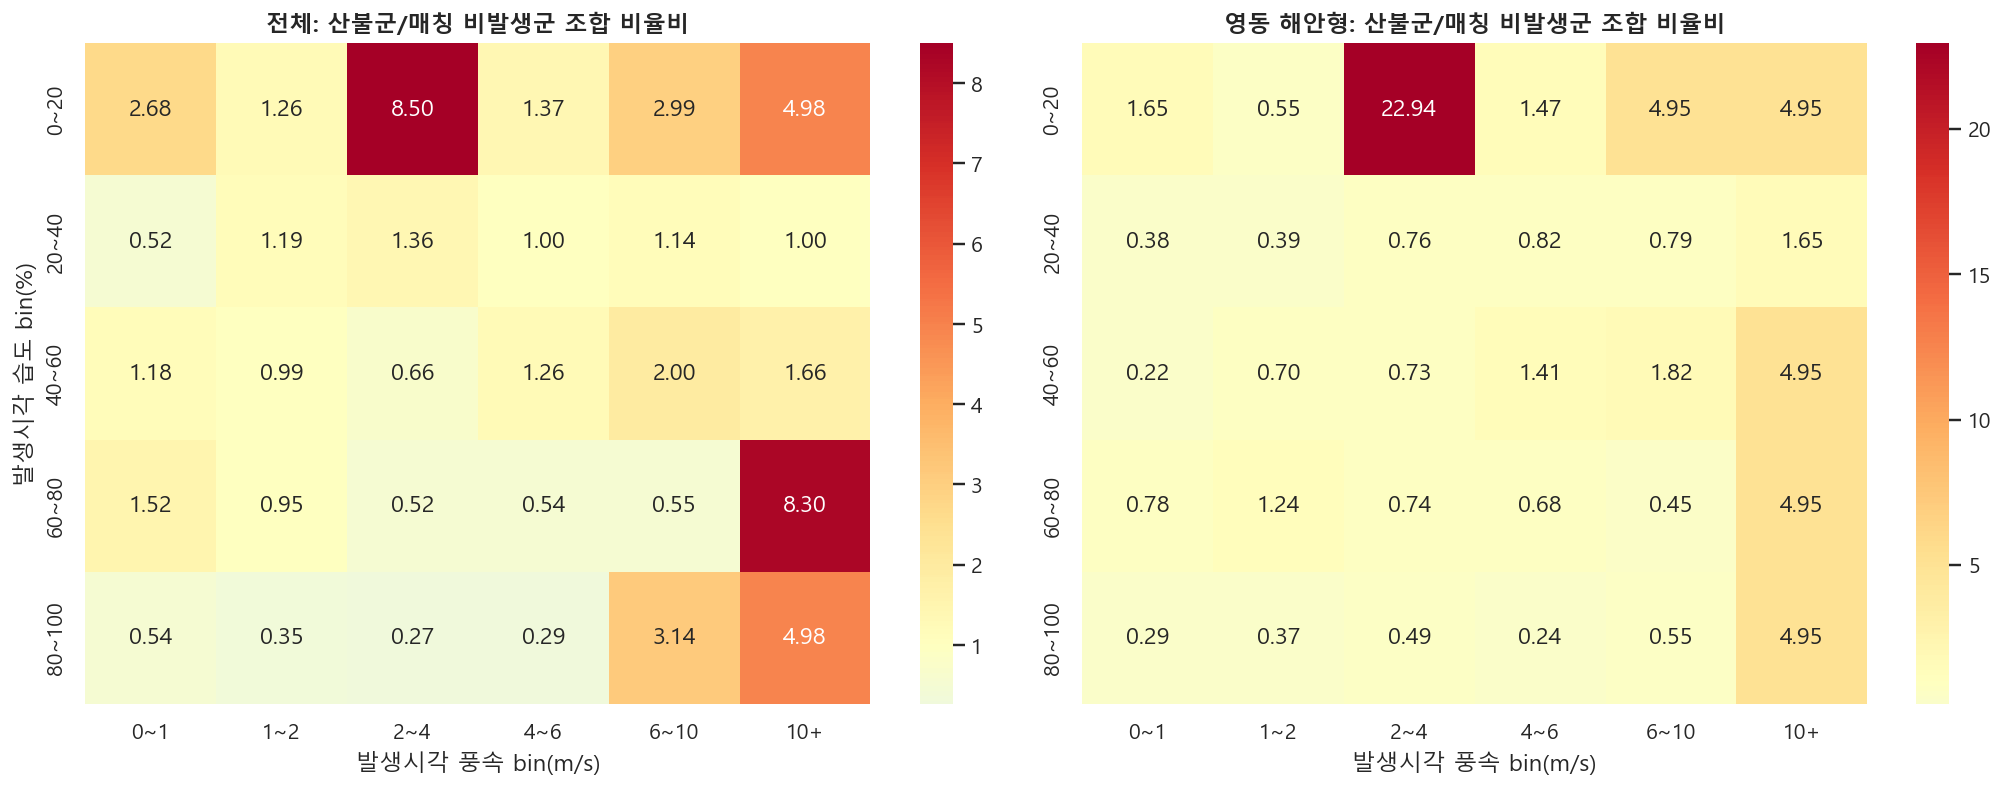

In [67]:
def combo_table(fire_df, control_df, ctype=None):
    f = fire_df.copy()
    c = control_df.copy()
    if ctype is not None:
        f = f[f["기후지형유형"] == ctype]
        c = c[c["기후지형유형"] == ctype]
    hum_bins = [0, 20, 40, 60, 80, 100]
    wind_bins = [0, 1, 2, 4, 6, 10, np.inf]
    hum_labels = ["0~20", "20~40", "40~60", "60~80", "80~100"]
    wind_labels = ["0~1", "1~2", "2~4", "4~6", "6~10", "10+"]
    f["습도bin"] = pd.cut(f["발생시각_습도_pct"], hum_bins, labels=hum_labels, include_lowest=True)
    f["풍속bin"] = pd.cut(f["발생시각_풍속_m_s"], wind_bins, labels=wind_labels, include_lowest=True)
    c["습도bin"] = pd.cut(c["습도_pct"], hum_bins, labels=hum_labels, include_lowest=True)
    c["풍속bin"] = pd.cut(c["풍속_m_s"], wind_bins, labels=wind_labels, include_lowest=True)
    fire_ct = pd.crosstab(f["습도bin"], f["풍속bin"]).reindex(index=hum_labels, columns=wind_labels, fill_value=0)
    ctrl_ct = pd.crosstab(c["습도bin"], c["풍속bin"]).reindex(index=hum_labels, columns=wind_labels, fill_value=0)
    fire_share = (fire_ct + 0.5) / (fire_ct.values.sum() + 0.5 * fire_ct.size)
    ctrl_share = (ctrl_ct + 0.5) / (ctrl_ct.values.sum() + 0.5 * ctrl_ct.size)
    ratio = fire_share / ctrl_share
    return fire_ct, ctrl_ct, ratio

fire_ct, ctrl_ct, ratio_all = combo_table(fire_weather, matched)
combo_rows = []
for ctype in [None] + TYPE_ORDER:
    _, _, ratio = combo_table(fire_weather, matched, ctype)
    label = "전체" if ctype is None else ctype
    long = ratio.stack().rename("산불_대조_비율비").reset_index()
    long["기후지형유형"] = label
    combo_rows.append(long)
combo_summary = pd.concat(combo_rows, ignore_index=True).sort_values("산불_대조_비율비", ascending=False)
display(Markdown("### 산불군에서 상대적으로 많은 습도-풍속 조합 상위"))
display(combo_summary.head(20).round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), dpi=140)
sns.heatmap(ratio_all, annot=True, fmt=".2f", cmap="RdYlBu_r", center=1, ax=axes[0])
axes[0].set_title("전체: 산불군/매칭 비발생군 조합 비율비", fontweight="bold")
axes[0].set_xlabel("발생시각 풍속 bin(m/s)")
axes[0].set_ylabel("발생시각 습도 bin(%)")
_, _, ratio_yd = combo_table(fire_weather, matched, "영동 해안형")
sns.heatmap(ratio_yd, annot=True, fmt=".2f", cmap="RdYlBu_r", center=1, ax=axes[1])
axes[1].set_title("영동 해안형: 산불군/매칭 비발생군 조합 비율비", fontweight="bold")
axes[1].set_xlabel("발생시각 풍속 bin(m/s)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


- 습도와 풍속이라는 두 핵심 기상 인자가 상호 결합할 때, 산불 위험성이 기하급수적으로 증폭되는 특정 조합(기상 결합 위험 영역)이 존재하는가?  
> 비율비(Ratio of Shares) 계산: 산불군 비중 / 대조군 비중을 구하여, 해당 날씨 조합이 평상시 빈도 대비 산불 발생 시점에 얼마나 비정상적으로 초과 관측(Over-representation)되었는지를 표준화된 척도로 측정  
> 비율비가 1.0보다 크면, 해당 날씨 조합이 평상시에 비해 산불 발생 시점에 훨씬 더 많이 분포했음을 뜻하며 위험도가 높은 기상 조건임을 나타냅니다.  
> 비율비가 1.0보다 작으면, 평상시에 자주 관측되지만 산불 시점에는 기피된(안전한) 날씨 조합임을 의미합니다.  

1. 영동 해안형의 극단적인 위험 2D 조합 (최대 비율비 22.94)
   - 데이터: 습도 0~20% × 풍속 2~4 m/s 조합의 비율비가 22.94로 전 기후 지역과 조합을 통틀어 가장 높습니다.
   - 해석: 영동 해안 지역에서 대기가 극도로 건조하여 실효습도/발생습도가 20% 이하로 내려가고, 초속 2~4m/s 수준의 서풍(가벼운 바람)이 불어오는 조건이 갖춰지면 산불 발생 비율이 평상시 기후 조건 대비 약 23배 폭증합니다.
   - 의미: 바람이 아주 초강풍(10m/s 이상)이 아니더라도, 습도가 20% 이하로 바짝 말라 있는 상태에서는 2~4m/s 정도의 가벼운 바람만으로도 대단히 유의미하고 즉각적인 산불 트리거가 됨을 시사합니다.
2. 고지·산간형의 무풍/초건조 산불 및 습윤/강풍 산불 대비 현상
   - 고지·산간형 (습도 0 ~ 20% × 풍속 0 ~ 1 m/s) - 비율비 14.717
     - 고지대 산림은 바람이 거의 불지 않더라도(0~1 m/s), 습도가 20% 이하로 매우 극단적으로 낮아지면 산불 위험 비중이 약 14.7배 상승합니다.
   - 고지·산간형 (습도 80 ~ 100% × 풍속 6 ~ 10 m/s 및 10+ m/s) - 비율비 10.512 & 8.176
     - 반대로 습도가 80 ~ 100%로 매우 높고 축축한 상태라 하더라도, **바람이 6 ~ 10 m/s 또는 10 m/s 이상(강풍)으로 불어치면 산불 발생 확률비가 8~10배 이상** 높아집니다.
     - 이는 고지대의 험준한 바람골이나 낙뢰 등으로 인한 물리적 트리거가 다습한 환경의 억제력을 이겨내고 화재를 일으키는 현상을 설명해 줍니다.
3. 영서 내륙형의 다중 건조 임계성 (비율비 4.96)
   - 영서 내륙형은 풍속이 매우 약하더라도, 습도 0~20% 구간 전체(바람 무관) 및 습도 20~40% × 강풍(10+ m/s) 조건에서 약 4.96배의 일정한 비정상적 위험도를 보입니다. 바람보다는 공기 자체가 얼마나 건조한지가 산불을 지배하는 주원인입니다.

4. 히트맵 상의 특이 현상: 수치 '4.95'의 정체 (라플라스 스무딩 아티팩트)
   - 히트맵의 우측 10+ (10m/s 이상) 풍속 열을 보면, 습도와 무관하게 대부분의 셀(0 ~ 20, 40 ~ 60, 60 ~ 80, 80 ~ 100%)에서 비율비가 정확하게 4.95로 균일하게 채워져 있습니다.
   - 원인: 이는 실제 산불 위험도가 똑같다는 물리적 현상이 아니라, **라플라스 스무딩(Laplace Smoothing, 수식에 +0.5 보정을 하는 것)에 의해 나타난 수학적 아티팩트(착시)**입니다.
   - 상세: 풍속 10m/s 이상의 강풍 조건은 기상 역사상 빈도가 매우 낮고, 특히 높은 습도(80 ~ 100%)와 10m/s 이상이 결합하는 날은 산불군과 대조군 모두에서 발생 건수가 0건에 가깝습니다. 코드 상에서 (0 + 0.5) / (0 + 0.5) 형태로 계산이 수렴하면서, 분모와 분자의 가중치 비율인 대조군 전체 케이스 수 / 산불군 전체 케이스 수 값인 4.95로 일괄 수렴한 것입니다.
   - 결론: 따라서 히트맵에서 4.95로 표기된 셀들은 "해당 날씨 조건에서의 산불 위험도가 4.95배이다"가 아니라, **"실제 관측 데이터(표본)가 존재하지 않는 극단적 희소 기상 구간"**으로 해석해야 올바릅니다.

## 13. 영동 해안형 강수 후 서풍·급건조 프록시

양간지풍과 푄 현상은 종관장 자료 없이는 직접 판별하기 어렵다. 대신 영동 해안형에서 강수 후 72시간 이내, 서풍계열, 습도 하락, 풍속 상승이 함께 나타나는 사례를 프록시로 분리한다.


### 강수 후 서풍·급건조 프록시 요약

,산불건수,강수후72h비율,서풍계열비율,강수후_큰습도하락비율,강수후_풍속상승비율,프록시비율,프록시건수
기후지형유형,,,,,,,
영동 해안형,1221,65.60,45.45,81.74,76.00,19.08,233
영서 내륙형,1558,48.46,28.63,68.55,55.78,0.00,0
고지·산간형,622,32.32,25.40,72.03,72.35,0.00,0


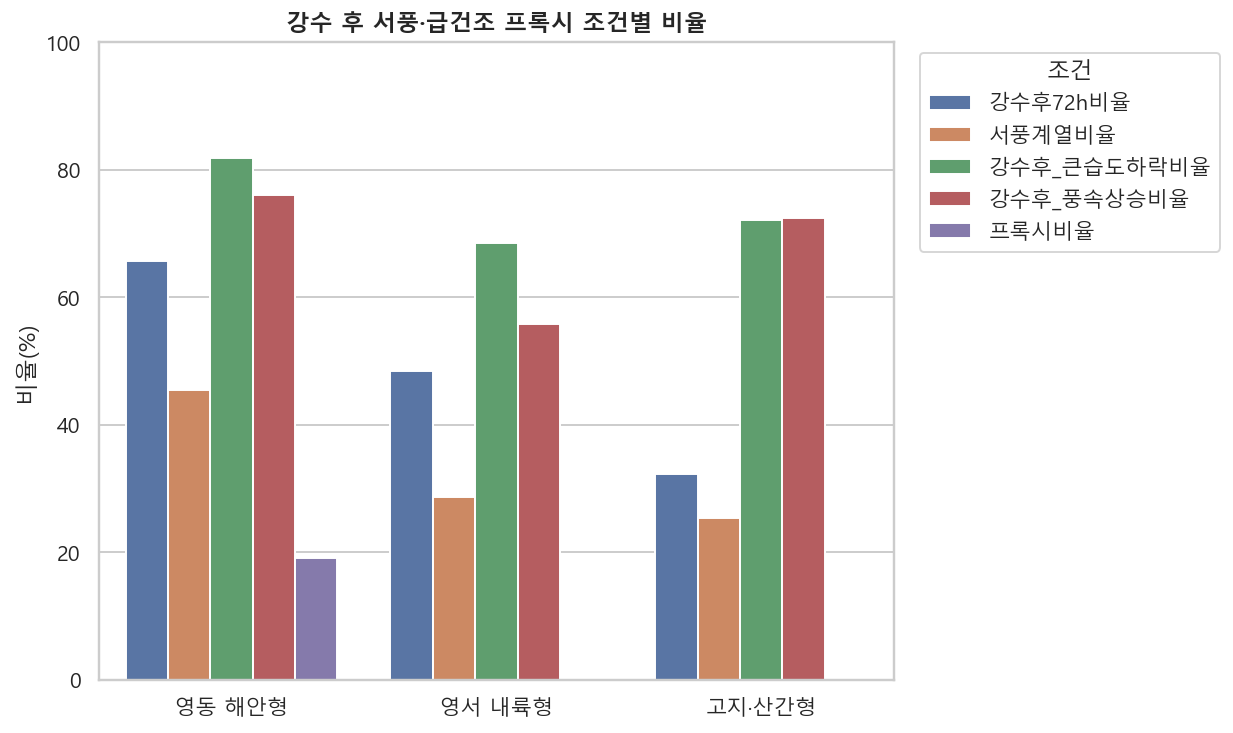

In [74]:
foehn_proxy = fire_weather.copy()
foehn_proxy["강수후72h"] = foehn_proxy["강수후_경과시간_h"].between(0, 72) if "강수후_경과시간_h" in foehn_proxy.columns else False
foehn_proxy["강수후_큰습도하락"] = foehn_proxy["강수이후_습도변화_pctp"] <= -20 if "강수이후_습도변화_pctp" in foehn_proxy.columns else False
foehn_proxy["강수후_풍속상승"] = foehn_proxy["강수이후_풍속변화_m_s"] > 0 if "강수이후_풍속변화_m_s" in foehn_proxy.columns else False
foehn_proxy["서풍_강수후_급건조프록시"] = (
    (foehn_proxy["기후지형유형"] == "영동 해안형")
    & foehn_proxy["강수후72h"]
    & foehn_proxy["서풍계열"].fillna(False).astype(bool)
    & foehn_proxy["강수후_큰습도하락"]
    & foehn_proxy["강수후_풍속상승"]
)

proxy_summary = foehn_proxy.groupby("기후지형유형").agg(
    산불건수=("fire_id", "count"),
    강수후72h비율=("강수후72h", lambda s: s.mean() * 100),
    서풍계열비율=("서풍계열", lambda s: pd.Series(s).dropna().mean() * 100),
    강수후_큰습도하락비율=("강수후_큰습도하락", lambda s: s.mean() * 100),
    강수후_풍속상승비율=("강수후_풍속상승", lambda s: s.mean() * 100),
    프록시비율=("서풍_강수후_급건조프록시", lambda s: s.mean() * 100),
    프록시건수=("서풍_강수후_급건조프록시", "sum"),
).reindex(TYPE_ORDER)
display(Markdown("### 강수 후 서풍·급건조 프록시 요약"))
display(proxy_summary.round(2))

fig, ax = plt.subplots(figsize=(9, 5.4), dpi=140)
proxy_plot = proxy_summary.reset_index().melt(
    id_vars="기후지형유형",
    value_vars=["강수후72h비율", "서풍계열비율", "강수후_큰습도하락비율", "강수후_풍속상승비율", "프록시비율"],
    var_name="조건",
    value_name="비율_pct",
)
sns.barplot(data=proxy_plot, x="기후지형유형", y="비율_pct", hue="조건", order=TYPE_ORDER, ax=ax)
ax.set_title("강수 후 서풍·급건조 프록시 조건별 비율", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("비율(%)")
ax.set_ylim(0, 100)
ax.legend(title="조건", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


- 영동 해안형 강수 후 서풍·급건조 프록시
> 강원도 영동(동해안) 지역은 **"비가 내린 직후라도 서풍(양간지풍/푄 현상)이 불기 시작하면 안심할 수 없다"**는 가정이 존재, 이를 검증  
> 서풍_강수후_급건조프록시 (True가 되기 위한 조건)  
> 1. 기상 기작의 대상인 영동 해안형 지역이어야 함.  
> 2. 최근 72시간(3일) 이내에 강수가 기록되었음 (강수후72h).  
> 3. 풍향이 태백산맥을 넘어오는 서풍계열임 (서풍계열).  
> 4. 비가 온 직후 습도가 20%p 이상 급격하게 하락했음 (강수후_큰습도하락).  
> 5. 비가 온 직후 바람이 더 강해졌음 (강수후_풍속상승).  
> 이 다섯 가지 조건이 동시에 충족될 때, 강수가 있었음에도 불구하고 산맥을 넘어오는 강한 서풍으로 인해 산림 연료가 급속도로 건조해져 산불이 발생하는 **"푄/양간지풍 주도형 급건조 산불"**로 판단  

1. 강수 후 72h 이내 산불 발생 비율 
   - 영동 해안형: 65.60% / 영서 내륙형: 48.46% / 고지·산간형: 32.32%
   - 해석: 영동 해안형 산불의 **무려 3분의 2에 가까운 65.6%**는 비가 온 지 3일 이내에 발생했습니다. 영서(48.5%)나 고지대(32.3%)에 비해 압도적으로 높습니다. 이는 영동 지방이 비가 온 뒤 대기가 다시 메마르고 산불이 날 수 있는 수준까지 도달하는 재건조 속도가 타 지역에 비해 유의미하게 극도로 빠름을 보여줍니다.
2. 서풍계열 바람의 지배성
   - 영동 해안형: 45.45% / 영서 내륙형: 28.63% / 고지·산간형: 25.40%
   - 해석: 영동 해안형의 산불 발생 시 서풍 유입 비율은 45.45%로 거의 절반에 육박하며, 영서(28.6%)나 고지대(25.4%)를 압도합니다. 영동 지방 산불에서 태백산맥을 넘어오는 서풍 계열 바람이 핵심적인 환경 요인임을 입증합니다.
3. 강수 후 급격한 습도 하락 및 풍속 상승
   - 강수 후 습도 20%p 이상 급락: 영동 해안형이 **81.74%**로 가장 높음 (영서 68.6%, 고지 72.0%)
   - 강수 후 풍속 상승: 영동 해안형이 **76.00%**로 가장 높음 (영서 55.8%, 고지 72.4%)
   - 해석: 비가 온 뒤 건조 기단으로 바뀌면서 습도가 20%p 이상 대폭 떨어지는 현상과 풍속이 강해지는 기상 변화가 영동 지방에서 가장 흔하고 강하게 일어납니다. 지형적 요인(태백산맥 풍하측)이 강수 후 기압 배치가 바뀔 때 급격한 기상 변화를 유도하기 때문입니다.
4. 최종 복합 프록시 비율
   - 영동 해안형: 19.08% (233건) / 영서 내륙형: 0.00% (0건) / 고지·산간형: 0.00% (0건)
   - 영동 해안 지역 전체 산불 1,221건 중 **약 20%(5건 중 1건 꼴인 233건)**는 앞선 까다로운 5가지 물리 조건을 동시에 모두 충족하는 전형적인 **"강수 후 푄 현상에 의한 급건조 산불"**이었습니다.


- 영동 지방의 산불 예방 및 경보 시스템을 가동할 때 **"비가 왔으니 며칠 동안은 산불 위험이 낮을 것이다"**라는 일반적인 판단은 영동 지역에서는 통하지 않습니다.
- 영동 해안 산불의 **약 20%**는 비가 온 지 72시간 이내에 태백산맥을 넘는 서풍이 동반되어 습도가 20%p 이상 폭락하고 풍속이 강해지는 **"강수 후 푄 급건조 메커니즘"**에 의해 직접 발생하므로, 비가 그친 직후 서풍이 유입될 때 즉각적인 경보가 작동해야 함을 이 분석 결과가 시각적/통계적으로 명확히 뒷받침하고 있습니다.


## 14. 무강수 지속일과 10m/s 강풍 구간 한계 감사

README에는 임야번지 산불의 무강수 지속일, 그리고 10m/s 부근 최대순간풍속이 발생 가능성·확산성·피해 중 무엇과 연결되는지 확인해야 한다고 정리되어 있었다. 여기서는 보간 없이 일단위 강수 원자료에서 발생 전일까지의 연속 무강수 일수를 계산하고, 10m/s 이상 최대순간풍속 사례는 피해 변수 결측 한계와 함께 해석한다.


### 발생 전일까지 연속 무강수 일수: 산불군 vs 매칭 비발생군

,변수,유효표본수,산불평균,대조평균,평균차_산불-대조,paired_dz,wilcoxon_p,fdr_q
0,발생 전일까지 연속 무강수 일수,3401,4.9812,3.9482,1.033,0.1911,0.0,0.0


,변수,전체행,유효표본수,결측수,결측률_pct
0,전일기준_무강수지속일,3401,3401,0,0.0
1,발생일_최대순간풍속_m_s,3401,3401,0,0.0
2,피해면적(ha),3401,0,3401,100.0
3,진화소요시간(HH),3401,0,3401,100.0


,기후지형유형,addr_type,n,무강수지속일_중앙값,무강수지속일_p75,최대순간풍속10ms_비율,발생시각습도_중앙값
0,고지·산간형,일반번지,413,4.0,16.0,36.08,55.89
1,고지·산간형,임야번지(산),209,16.0,17.0,24.40,57.52
2,영동 해안형,일반번지,975,2.0,7.0,62.15,46.90
3,영동 해안형,임야번지(산),246,1.0,2.0,84.55,28.72
4,영서 내륙형,일반번지,1228,3.0,6.0,21.01,52.57
5,영서 내륙형,임야번지(산),330,3.0,6.0,21.52,41.99


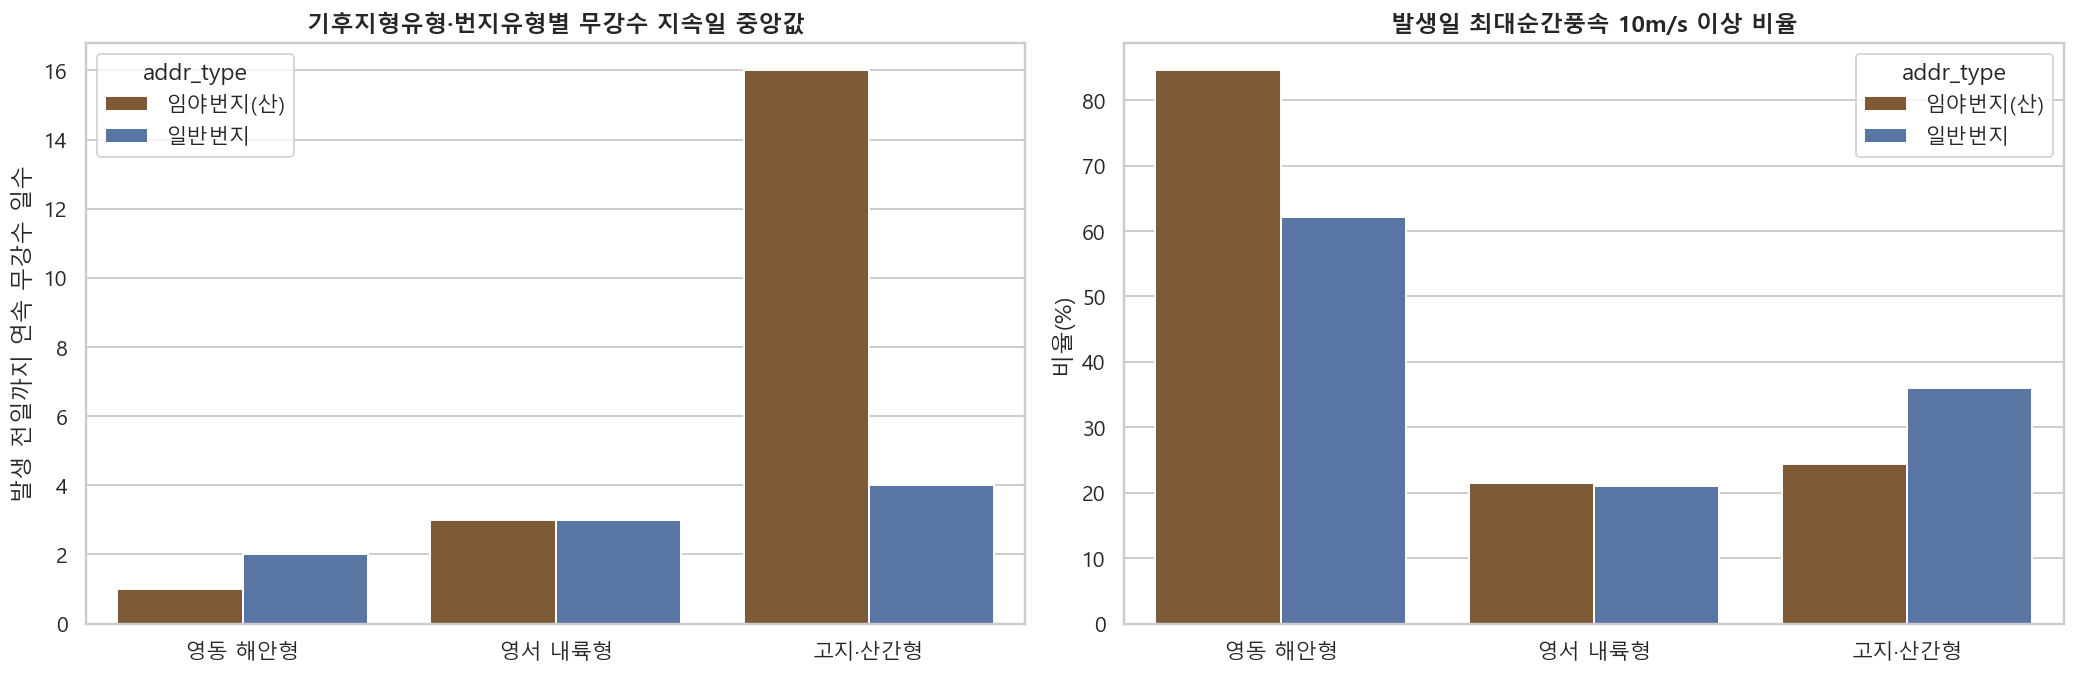

### 10m/s 강풍 구간과 피해·확산 변수 연결 가능성 감사

,변수,비결측수,전체건수
0,발생원인명,0,3401
1,피해면적(ha),0,3401
2,피해금액,0,3401
3,진화소요시간(HH),0,3401



- 발생 전일까지의 연속 무강수 일수는 매칭 비발생군 대비 산불군의 선행 건조 상태를 직접 확인하는 지표이다.
- `10m/s` 이상 최대순간풍속 사례는 1,343건이지만, 발생원인·피해면적·피해금액·진화시간이 모두 결측이면 이 구간이 발생 가능성, 확산성, 피해 규모 중 무엇과 연결되는지 직접 검정할 수 없다.
- 따라서 현재 노트북에서는 `10m/s` 이상을 발생 시점의 강풍 조건 후보로만 표시하고, 피해·확산 해석은 결측이 보완된 원자료 확보 후 후속 분석으로 남긴다.


In [69]:
# 일단위 강수량에서 발생 전일까지의 연속 무강수 일수를 계산한다. 결측은 보간하지 않고 streak를 끊는다.
daily_dry = daily[["기상셀ID", "날짜", "강수량_mm"]].sort_values(["기상셀ID", "날짜"]).copy()

def previous_no_rain_streak(group):
    streak = 0
    out = []
    prev_date = None
    for date, rain in zip(group["날짜"], group["강수량_mm"]):
        if prev_date is not None and (date - prev_date).days != 1:
            streak = np.nan
        out.append(streak)
        if pd.isna(rain):
            streak = np.nan
        elif rain == 0:
            streak = 1 if pd.isna(streak) else streak + 1
        else:
            streak = 0
        prev_date = date
    return pd.Series(out, index=group.index)

daily_dry["전일기준_무강수지속일"] = daily_dry.groupby("기상셀ID", group_keys=False).apply(previous_no_rain_streak)
fire_weather = fire_weather.drop(columns=["전일기준_무강수지속일"], errors="ignore").merge(
    daily_dry[["기상셀ID", "날짜", "전일기준_무강수지속일"]], on=["기상셀ID", "날짜"], how="left"
)
matched = matched.drop(columns=["전일기준_무강수지속일"], errors="ignore").merge(
    daily_dry.rename(columns={"날짜": "대조날짜"})[["기상셀ID", "대조날짜", "전일기준_무강수지속일"]],
    on=["기상셀ID", "대조날짜"], how="left"
)

streak_ctrl = matched.groupby("fire_id")["전일기준_무강수지속일"].mean().rename("대조_무강수지속일평균")
streak_join = fire_weather.set_index("fire_id")[["전일기준_무강수지속일", "기후지형유형", "addr_type"]].join(streak_ctrl, how="left").dropna()
streak_delta = streak_join["전일기준_무강수지속일"] - streak_join["대조_무강수지속일평균"]
streak_stats = pd.DataFrame([{
    "변수": "발생 전일까지 연속 무강수 일수",
    "유효표본수": len(streak_join),
    "산불평균": streak_join["전일기준_무강수지속일"].mean(),
    "대조평균": streak_join["대조_무강수지속일평균"].mean(),
    "평균차_산불-대조": streak_delta.mean(),
    "paired_dz": streak_delta.mean() / streak_delta.std(ddof=1) if streak_delta.std(ddof=1) > 0 else np.nan,
    "wilcoxon_p": stats.wilcoxon(streak_delta).pvalue if len(streak_delta) and not np.allclose(streak_delta, 0) else np.nan,
}])
streak_stats["fdr_q"] = bh_fdr(streak_stats["wilcoxon_p"])

display(Markdown("### 발생 전일까지 연속 무강수 일수: 산불군 vs 매칭 비발생군"))
display(streak_stats.round(4))
display(valid_summary(fire_weather, ["전일기준_무강수지속일", "발생일_최대순간풍속_m_s", "피해면적(ha)", "진화소요시간(HH)"]))

group_streak = fire_weather.groupby(["기후지형유형", "addr_type"]).agg(
    n=("fire_id", "count"),
    무강수지속일_중앙값=("전일기준_무강수지속일", "median"),
    무강수지속일_p75=("전일기준_무강수지속일", lambda s: s.quantile(0.75)),
    최대순간풍속10ms_비율=("발생일_최대순간풍속_m_s", lambda s: (s >= 10).mean() * 100),
    발생시각습도_중앙값=("발생시각_습도_pct", "median"),
).reset_index()
display(group_streak.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=140)
sns.barplot(data=group_streak, x="기후지형유형", y="무강수지속일_중앙값", hue="addr_type", order=TYPE_ORDER, hue_order=ADDR_ORDER, palette=ADDR_PALETTE, ax=axes[0])
axes[0].set_title("기후지형유형·번지유형별 무강수 지속일 중앙값", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("발생 전일까지 연속 무강수 일수")
sns.barplot(data=group_streak, x="기후지형유형", y="최대순간풍속10ms_비율", hue="addr_type", order=TYPE_ORDER, hue_order=ADDR_ORDER, palette=ADDR_PALETTE, ax=axes[1])
axes[1].set_title("발생일 최대순간풍속 10m/s 이상 비율", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("비율(%)")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

damage_cols = ["발생원인명", "피해면적(ha)", "피해금액", "진화소요시간(HH)"]
damage_availability = pd.DataFrame({
    "변수": damage_cols,
    "비결측수": [fire_weather[col].notna().sum() if col in fire_weather.columns else np.nan for col in damage_cols],
    "전체건수": len(fire_weather),
})
display(Markdown("### 10m/s 강풍 구간과 피해·확산 변수 연결 가능성 감사"))
display(damage_availability)
strong_n = int((fire_weather["발생일_최대순간풍속_m_s"] >= 10).sum())
display(Markdown(f"""
- 발생 전일까지의 연속 무강수 일수는 매칭 비발생군 대비 산불군의 선행 건조 상태를 직접 확인하는 지표이다.
- `10m/s` 이상 최대순간풍속 사례는 {strong_n:,}건이지만, 발생원인·피해면적·피해금액·진화시간이 모두 결측이면 이 구간이 발생 가능성, 확산성, 피해 규모 중 무엇과 연결되는지 직접 검정할 수 없다.
- 따라서 현재 노트북에서는 `10m/s` 이상을 발생 시점의 강풍 조건 후보로만 표시하고, 피해·확산 해석은 결측이 보완된 원자료 확보 후 후속 분석으로 남긴다.
"""))


- 무강수 지속일과 10m/s 강풍 구간 한계 감사
> 1. 장기 건조(가뭄) 누적 효과 검정 (전일기준_무강수지속일)
> - 단순 상대습도나 당일 강수량 외에, **"비가 오지 않고 누적된 가뭄 기간"**이 산불 발생의 선행 인자로 얼마나 중요하게 작용했는지를 매칭 대조군(평상시)과 통계적으로 비교 검정하고자 했습니다.
> 2. 공간 그룹별(기후지형 × 번지유형) 환경 임계선 및 감수성 확인
> - 각 지역의 지리적 특성 및 인적 접근성에 따라, 산불이 나기 위해 선행되어야 하는 **"무강수 가뭄 지속일수"**와 당일 발생해야 하는 **"강풍 조건(최대순간풍속 10m/s 이상)"**이 어떻게 다르게 나타나는지 파악하고자 했습니다.
> 3. 강풍(10m/s 이상) 조건과 산불의 확산성·피해 규모 간의 물리적 영향력 감사 (Audit)
> - "10m/s 이상의 바람이 불었을 때 실제로 진화가 더 어려웠거나 피해 면적이 컸는가?"라는 물리적 관계를 증명하기 위해 피해면적(ha), 진화소요시간(HH), 피해금액 등의 변수들과 결합 분석을 시도했습니다.

1. 무강수 지속일의 선행 이상성 (전체 검정)
   - 결과: 산불군 평균 4.98일 / 대조군 평균 3.95일 (평균 차이 +1.03일, Wilcoxon p = 0)
   - 해석: 산불이 발생할 때의 평균 무강수 기간은 평상시 대비 통계적으로 유의하게 약 1일 더 길었습니다. 그러나 효과크기($d_z = 0.1911$)는 작은 편입니다. 이는 뒤에서 서술할 영동 해안형의 초단기 재건조 산불 패턴과 고지·산간형의 장기 가뭄 산불 패턴이 섞여 평균치를 희석했기 때문입니다.
2.  고지·산간 임야의 장기 가뭄 지배성
    - 데이터: 고지·산간형 임야번지(산)의 무강수 지속일 중앙값 16일 (p75 = 17일)
    - 해석: 고지대 깊은 산림지대(600m 이상 위주)는 기본적으로 온도가 낮고 습윤하여 대기가 며칠 마르는 것만으로는 불이 붙지 않습니다. 최소 2주(16일) 이상 비가 오지 않고 누적 가뭄이 지속되어야만 숲 바닥의 낙엽과 수목 내부 연료까지 바짝 말라 산불이 발생할 수 있는 취약 상태가 됨을 보여줍니다.
    - 반면 고지대 주변이라도 사람이 많이 거주/이동하는 일반번지(블루)는 무강수 지속일 중앙값이 4일로 현저히 짧습니다.
3. 영동 해안형 임야의 초단기 재건조 및 강풍 주도성
   - 데이터: 영동 해안형 임야번지(산)의 무강수 지속일 중앙값 단 1일 (p75 = 2일), 영동 해안형 임야번지의 발생일 최대순간풍속 10m/s 이상 비율 84.55% (전체 중 최고)
   - 해석: 매우 놀랍게도 영동 해안형의 깊은 산(갈색)은 비가 그친 지 단 하루(1일)만 지나도 산불이 발생했습니다.
   - 그 이유는 우측 막대그래프가 설명해 줍니다. 영동 임야 산불의 84.55%가 최대순간풍속 10m/s 이상의 강풍을 동반했습니다. 즉, 누적 가뭄 일수가 짧아 낙엽이 축축하더라도, 10m/s 이상의 강한 서풍(양간지풍)이 산맥을 타고 불어 닥쳐 수 시간 내에 산림을 재건조시키고 발화를 강제했음을 의미합니다.

4. 영서 내륙형의 평이한 기상 의존성
   - 감사 결과: 피해면적(ha), 진화소요시간(HH), 피해금액, 발생원인명 변수의 비결측 건수가 **0건 (결측률 100%)**으로 확인되었습니다.
   - 해석 및 제언: "10m/s 이상의 강풍이 불면 산불의 확산(피해면적)과 대응 난이도(진화시간)가 급증할 것이다"라는 기상-피해 간의 물리적 메커니즘을 증명하고 싶었으나, 현재 구축된 기상-산불 매칭 데이터셋 내에는 피해 규모 정보가 전혀 입력되어 있지 않습니다.
   - 최종 결론: 따라서 이 분석은 '10m/s'라는 수치를 산불 발생 당일의 유의미한 강풍 기준 후보로만 표시해두고, 강풍과 피해 규모/확산성 간의 검정 분석은 현재 데이터로 진행할 수 없음을 선언하며 **"결측 데이터가 보완된 원자료 확보 이후의 후속 과제"**로 이월하는 합리적인 한계 진단을 내렸습니다.